# Regional Logistics Transfers – Delay Prediction

**Group #15**

The task is a binary classification problem: predict whether a transfer arrives **more than 30 minutes late** relative to its scheduled arrival time (`is_delayed`).

## Part 1: Exploration

## Setup

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Consistent, readable plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
TARGET = "is_delayed"

DATA_DIR = Path(os.environ.get("DATA_DIR", "data"))
TRAIN_PATH = DATA_DIR / "regional_logistics_transfers_train.csv"
TEST_PATH = DATA_DIR / "regional_logistics_transfers_test.csv"

## Data Sanity & Initial Profiling

We load the training set and take a first look at its shape, data types, summary statistics, number of unique values per column and missing values. The goal is to understand what each column represents, spot irrelevant columns, and get an early sense of distributions and potential outliers.

In [2]:
# Load the training data.
print(f"Loading training data from: {TRAIN_PATH}")
df = pd.read_csv(TRAIN_PATH)
print("Shape (rows, columns):", df.shape)
df.head()

Loading training data from: data\regional_logistics_transfers_train.csv
Shape (rows, columns): (51056, 23)


,operation_date,day_of_week,scheduled_dispatch_time,expected_dispatch_delay_minutes,scheduled_arrival_time,source_facility,source_region,destination_facility,destination_region,logistics_provider,...,expected_weather_disruption_minutes,expected_network_congestion_delay_minutes,expected_inspection_delay_minutes,expected_previous_transfer_delay_minutes,internal_metric_a,internal_metric_b,internal_timestamp_a,internal_timestamp_b,internal_operational_score,is_delayed
0,2024-04-01,1,830,2.0,1217,FACILITY_298,REGION_005,FACILITY_091,REGION_006,UA,...,0.0,0.0,0.0,0,NaN,4.0,900.0,1202.0,52.542136,0
1,2024-04-01,1,1500,-7.0,1642,FACILITY_112,REGION_029,FACILITY_273,REGION_032,9E,...,0.0,0.0,0.0,0,14.0,4.0,1451.0,1616.0,58.169563,0
2,2024-04-01,1,1340,-3.0,1522,FACILITY_273,REGION_032,FACILITY_174,REGION_031,9E,...,0.0,0.0,0.0,0,16.0,5.0,1342.0,1537.0,57.702196,0
3,2024-04-01,1,1325,-11.0,1501,FACILITY_159,REGION_048,FACILITY_099,REGION_021,9E,...,NaN,NaN,0.0,0,14.0,6.0,1220.0,1427.0,51.548966,0
4,2024-04-01,1,1012,-5.0,1200,FACILITY_099,REGION_021,FACILITY_174,REGION_031,9E,...,0.0,0.0,0.0,0,23.0,NaN,1055.0,1202.0,61.802930,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51056 entries, 0 to 51055
Data columns (total 23 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   operation_date                             51056 non-null  str    
 1   day_of_week                                51056 non-null  int64  
 2   scheduled_dispatch_time                    51056 non-null  int64  
 3   expected_dispatch_delay_minutes            50435 non-null  float64
 4   scheduled_arrival_time                     51056 non-null  int64  
 5   source_facility                            51056 non-null  str    
 6   source_region                              51056 non-null  str    
 7   destination_facility                       51056 non-null  str    
 8   destination_region                         51056 non-null  str    
 9   logistics_provider                         51056 non-null  str    
 10  scheduled_travel_time_minutes    

In [4]:
# Summary statistics for the columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
day_of_week,51056.0,3.976614,1.997433,1.000000,2.000000,4.000000,6.00000,7.000000
scheduled_dispatch_time,51056.0,1312.670538,390.114446,700.000000,951.000000,1317.000000,1650.00000,1959.000000
expected_dispatch_delay_minutes,50435.0,15.702786,58.350467,-22.000000,-5.000000,-1.000000,12.00000,2120.000000
scheduled_arrival_time,51056.0,1573.085396,422.308204,1.000000,1230.000000,1608.000000,1925.00000,2359.000000
scheduled_travel_time_minutes,51056.0,184.786607,85.959995,55.000000,122.000000,167.000000,221.00000,764.000000
route_distance_miles,51056.0,1181.731808,769.964405,92.000000,663.600000,1033.800000,1498.40000,14341.700000
expected_provider_delay_minutes,47480.0,5.132603,36.426832,0.000000,0.000000,0.000000,0.00000,2053.000000
expected_weather_disruption_minutes,45952.0,0.572380,12.246334,0.000000,0.000000,0.000000,0.00000,1052.000000
expected_network_congestion_delay_minutes,46966.0,4.295192,22.486952,0.000000,0.000000,0.000000,0.00000,1080.000000
expected_inspection_delay_minutes,44933.0,0.022166,0.997570,0.000000,0.000000,0.000000,0.00000,94.000000


In [5]:
# Number of unique values per column
# Helps to explore the data and understand the different values each feature can take.
df.nunique().sort_values()

is_delayed                                       2
operation_date                                   7
day_of_week                                      7
logistics_provider                              28
expected_inspection_delay_minutes               33
destination_facility                            40
source_facility                                 40
source_region                                   47
destination_region                              48
internal_metric_b                               89
internal_metric_a                              136
expected_weather_disruption_minutes            147
expected_network_congestion_delay_minutes      294
expected_provider_delay_minutes                320
expected_previous_transfer_delay_minutes       371
scheduled_travel_time_minutes                  398
expected_dispatch_delay_minutes                517
scheduled_dispatch_time                        780
scheduled_arrival_time                        1020
route_distance_miles           

In [6]:
# Missing values per feature, as a count and as a percentage of all rows
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().mean() * 100).round(2),
})
missing = missing[missing["missing_count"] > 0].sort_values("missing_count", ascending=False)
missing

,missing_count,missing_pct
internal_metric_a,8320,16.30
expected_inspection_delay_minutes,6123,11.99
internal_metric_b,5782,11.32
expected_weather_disruption_minutes,5104,10.00
expected_network_congestion_delay_minutes,4090,8.01
expected_provider_delay_minutes,3576,7.00
internal_timestamp_b,680,1.33
internal_timestamp_a,669,1.31
expected_dispatch_delay_minutes,621,1.22


In [7]:
# Group the columns by role, this is reused throughout the exploration.
delay_cols = [
    "expected_dispatch_delay_minutes",
    "expected_provider_delay_minutes",
    "expected_weather_disruption_minutes",
    "expected_network_congestion_delay_minutes",
    "expected_inspection_delay_minutes",
    "expected_previous_transfer_delay_minutes",
]
route_cols = ["scheduled_travel_time_minutes", "route_distance_miles"]
anon_cols = [
    "internal_metric_a",
    "internal_metric_b",
    "internal_timestamp_a",
    "internal_timestamp_b",
    "internal_operational_score",
]
categorical_cols = [
    "source_region",
    "destination_region",
    "source_facility",
    "destination_facility",
    "logistics_provider",
    "day_of_week",
]
print("Delay columns:", len(delay_cols), "| Route:", len(route_cols), "| Anonymous:", len(anon_cols))

Delay columns: 6 | Route: 2 | Anonymous: 5


## Univariate Distribution Analysis

We look at one variable at a time: the balance of the target, the distribution of the continuous features (route, delays, anonymous metrics) and the frequency of the main categorical fields. This tells us which features are roughly symmetric, which are heavy-tailed, and where outliers live.

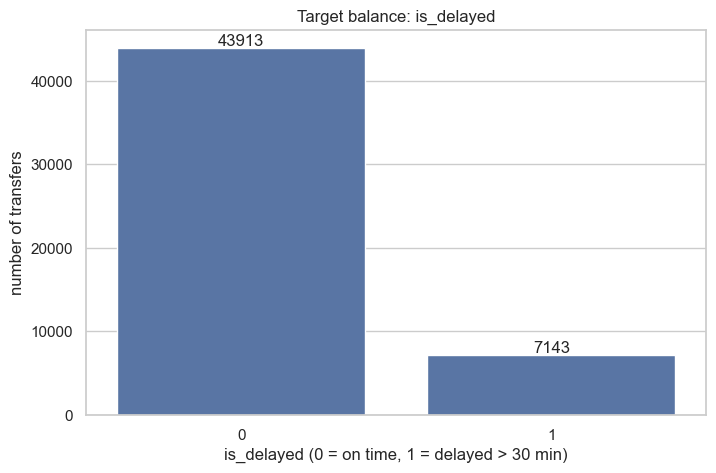

is_delayed
0    0.8601
1    0.1399
Name: proportion, dtype: float64


In [8]:
# Target balance
ax = sns.countplot(data=df, x=TARGET)
ax.set_title("Target balance: is_delayed")
ax.set_xlabel("is_delayed (0 = on time, 1 = delayed > 30 min)")
ax.set_ylabel("number of transfers")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

print(df[TARGET].value_counts(normalize=True).round(4))

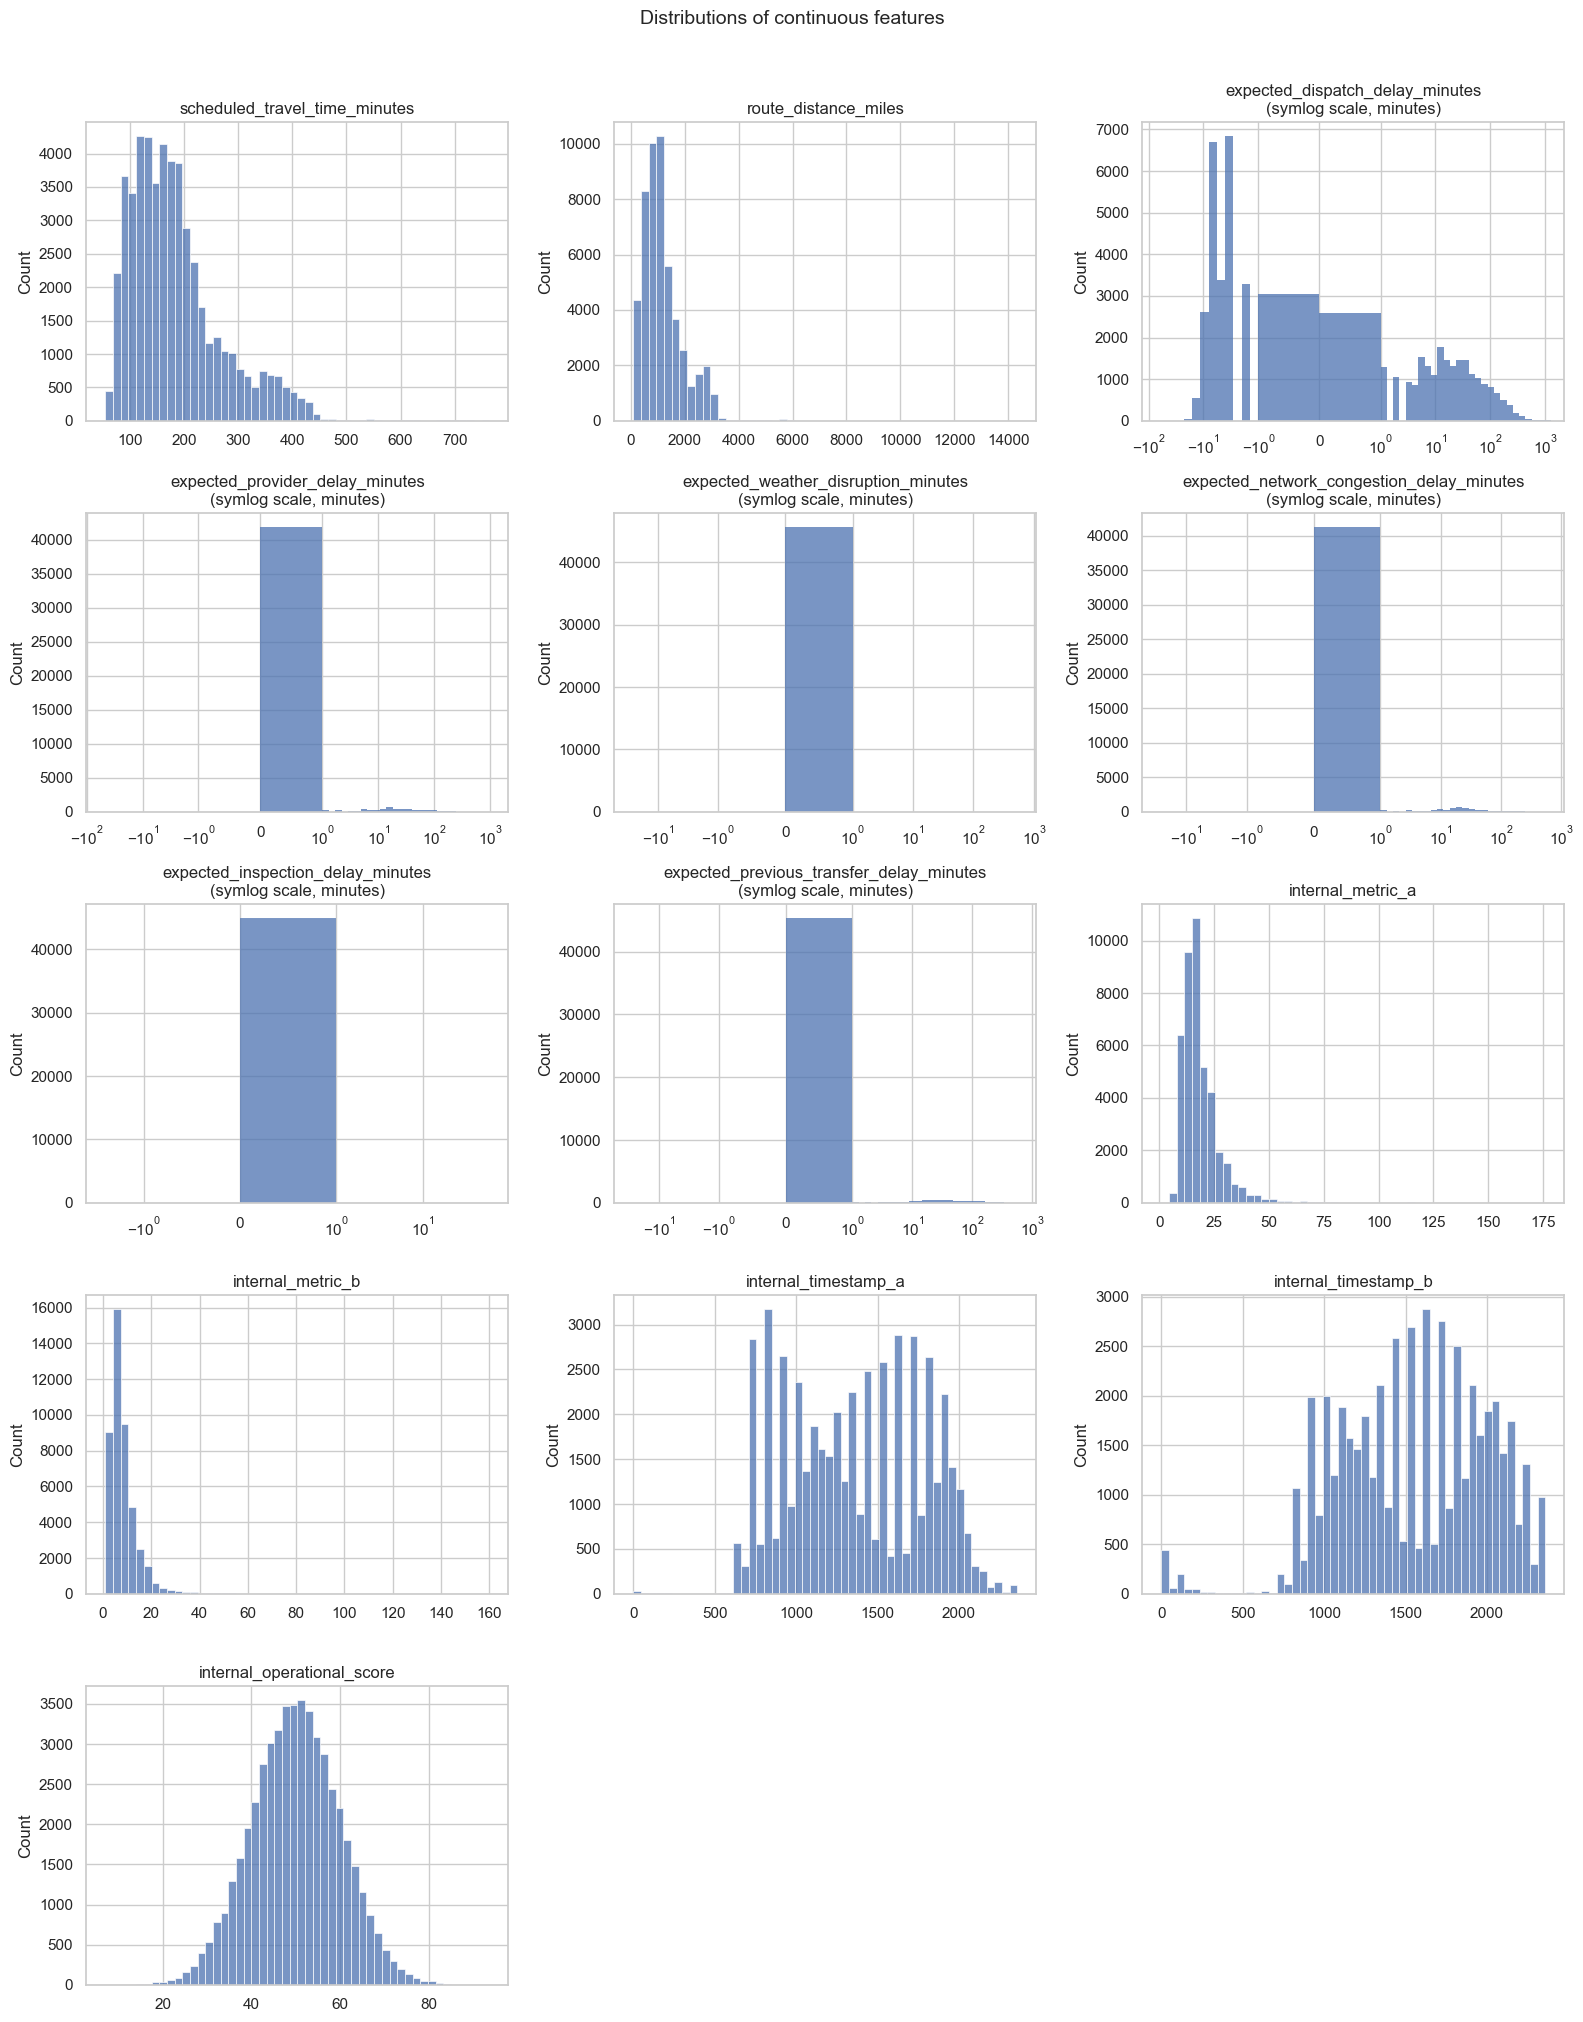

In [9]:
# GOOVER
# Histograms of the continuous features
# Expected-delay columns are zero-inflated and right-skewed -> symlog x-scale.
# Symlog is linear around 0 (|x| < linthresh) and logarithmic in both tails,
# so it keeps the raw minute values, preserves the negative early-dispatch
# values (e.g. expected_dispatch_delay_minutes goes down to ~-22) and still
# compresses the heavy right tail.
continuous_cols = route_cols + delay_cols + anon_cols

n_cols = 3
n_rows = int(np.ceil(len(continuous_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, continuous_cols):
    data = df[col].dropna()
    if col in delay_cols:
        # Symlog-spaced bin edges so the histogram is not dominated by the
        # zero spike: linear bins inside [-linthresh, linthresh], log-spaced
        # bins out to each tail. Plotted on a matching symlog x-axis.
        linthresh = 1.0
        pos_max = data.max()
        neg_min = data.min()
        edges = [0.0, linthresh]
        if pos_max > linthresh:
            edges += list(np.logspace(np.log10(linthresh), np.log10(pos_max), 30))
        if neg_min < 0:
            neg_edges = list(-np.logspace(np.log10(linthresh),
                                          np.log10(max(-neg_min, linthresh) + 1), 10))
            edges += [-linthresh] + neg_edges
        bins = np.unique(np.array(edges))
        sns.histplot(data, bins=bins, ax=ax)
        ax.set_xscale("symlog", linthresh=linthresh)
        ax.set_title(f"{col}\n(symlog scale, minutes)")
    else:
        sns.histplot(data, bins=50, ax=ax)
        ax.set_title(col)
    ax.set_xlabel("")

# Hide any unused subplot
for ax in axes[len(continuous_cols):]:
    ax.set_visible(False)

fig.suptitle("Distributions of continuous features", y=1.01, fontsize=14)
fig.tight_layout()
plt.show()


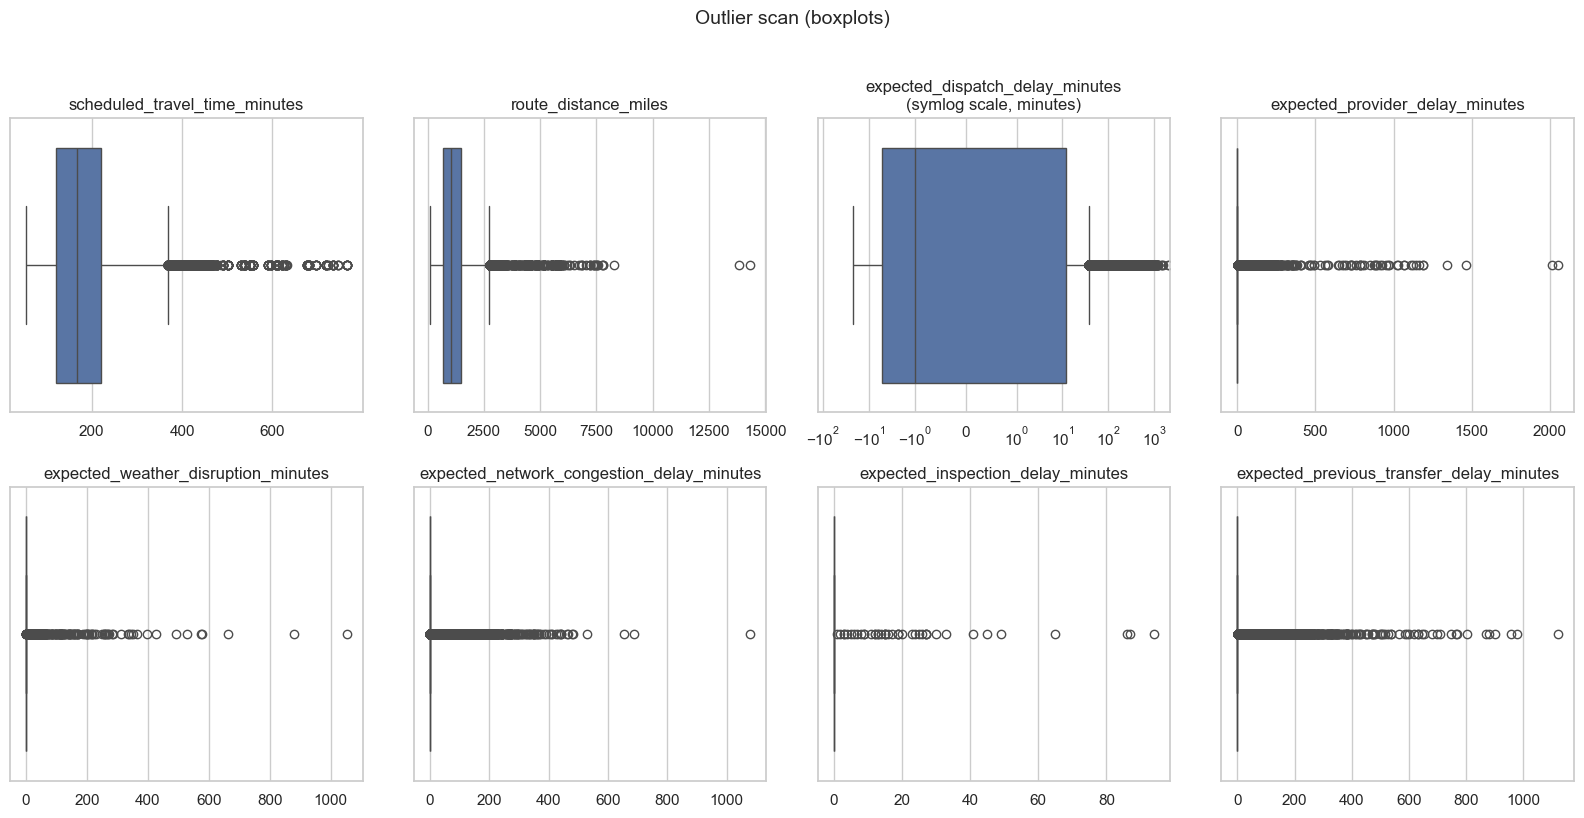

In [10]:
# Boxplots to make the outliers in the route and delay features explicit and proven
box_cols = route_cols + delay_cols

n_cols = 4
n_rows = int(np.ceil(len(box_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, box_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    if col == "expected_dispatch_delay_minutes":
        ax.set_xscale("symlog", linthresh=1)
        ax.set_title(f"{col}\n(symlog scale, minutes)")

for ax in axes[len(box_cols):]:
    ax.set_visible(False)

fig.suptitle("Outlier scan (boxplots)", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()


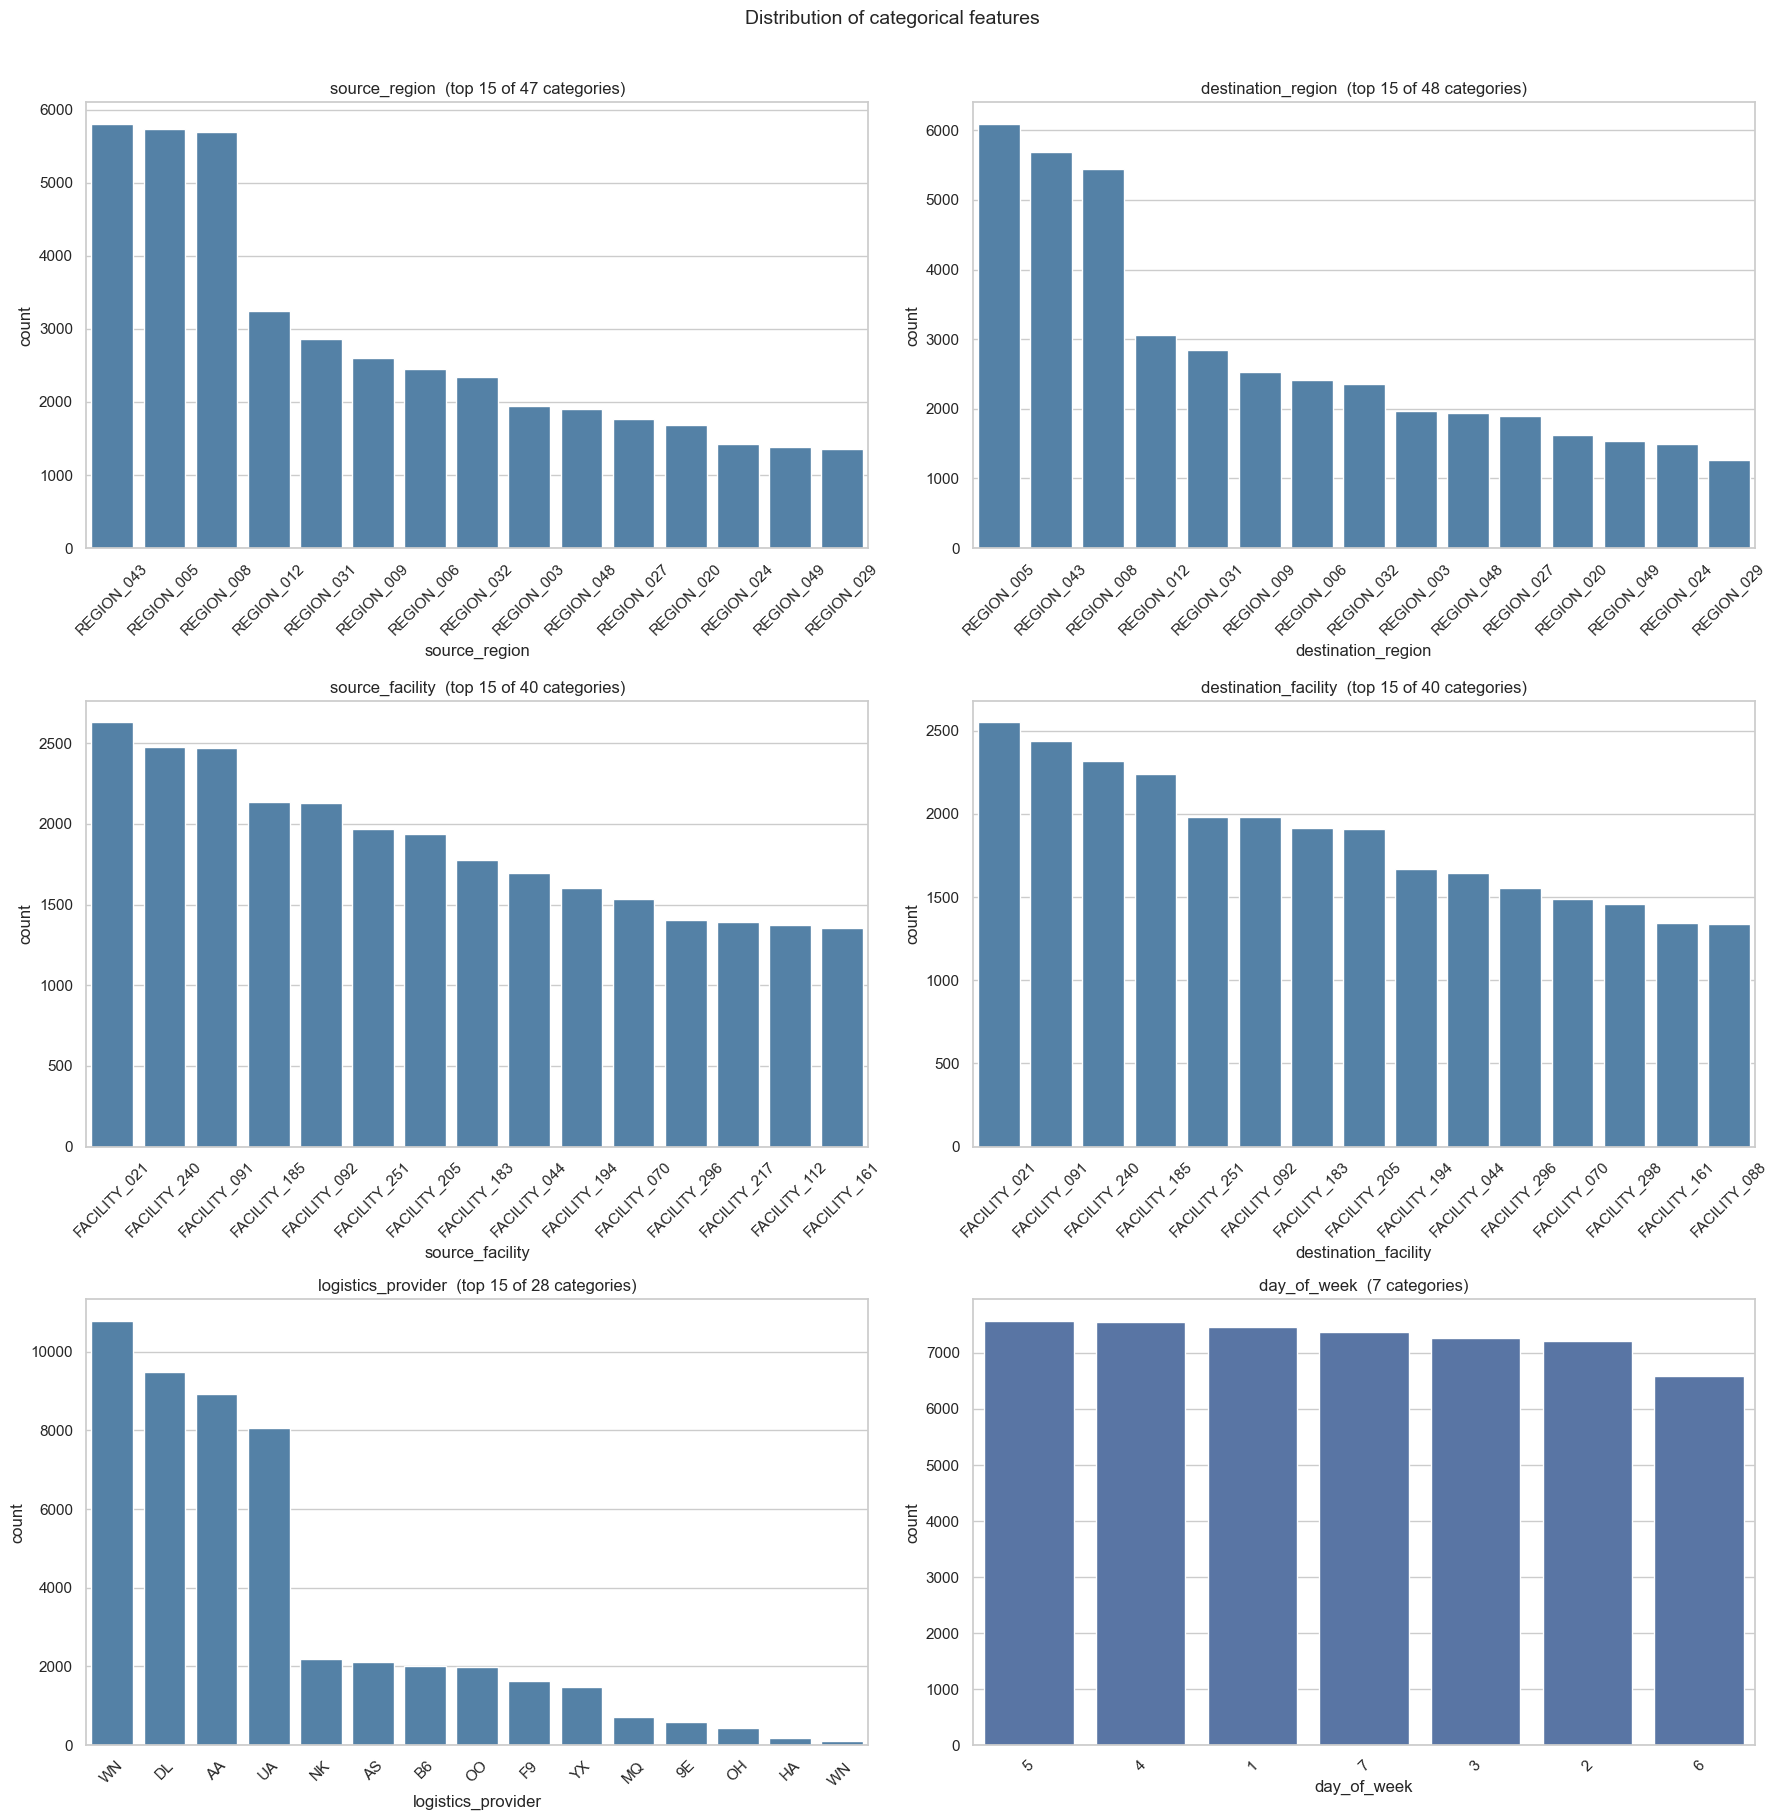

In [11]:
# Distribution of all categorical features
# Low-cardinality features (logistics_provider, day_of_week): full countplot.
# High-cardinality features (regions, facilities): top 15 categories by count.
# All plots share the same orientation: count on y-axis, category value on x-axis.

TOP_N = 15

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    counts = df[col].value_counts()
    n_unique = len(counts)

    if n_unique <= 20:
        # Show all categories
        sns.countplot(data=df, x=col, order=counts.index, ax=ax)
        ax.set_title(f"{col}  ({n_unique} categories)")
    else:
        # Show only top N by frequency
        top = counts.head(TOP_N)
        sns.barplot(x=top.index, y=top.values, color="steelblue", ax=ax)
        ax.set_title(f"{col}  (top {TOP_N} of {n_unique} categories)")
        ax.set_ylabel("count")

    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel(col)

fig.suptitle("Distribution of categorical features", y=1.01, fontsize=14)
fig.tight_layout()
plt.show()


### Conclusions

- **Target imbalance.** Confirmed visually: 43,913 on-time vs. 7,143 delayed (~14% positive class). Models and evaluation should account for this (AUC, class weights / resampling).
- **Roughly normal feature.** `internal_operational_score` is clearly bell-shaped around 50 with std ~10 – the only feature that looks approximately Gaussian.
- **Heavy-tailed / skewed features.** `route_distance_miles`, `scheduled_travel_time_minutes`, `internal_metric_a` and `internal_metric_b` are right-skewed with a long tail (a Chi-square-like shape). The six expected-delay columns are **zero-inflated**: the vast majority of values are exactly 0 with a small fraction of very large delays. These will likely benefit from a log/robust transform and outlier handling later.
- **Anonymous timestamps.** `internal_timestamp_a` and `internal_timestamp_b` span 0–2359 and are concentrated in daytime hours – they behave like `HHMM` clock times rather than opaque metrics, with a small spike near 0 (likely midnight or a placeholder).
- **Outliers.** The boxplots show many extreme high values in every delay column and in `route_distance_miles` (a few routes above 8,000–14,000 miles). We will decide how to treat these in the preprocessing phase rather than discard them now.
- **Categoricals.** Transfers are spread fairly evenly across the 7 days of the week (slightly fewer on day 6). The provider field is dominated by four carriers (WN, DL, AA, UA). **Data-quality issue found:** `logistics_provider` has trailing-whitespace duplicates (e.g. `'9E '` vs `'9E'`), which split 14 real codes into 28 categories. This must be stripped/normalised in preprocessing.

## Bivariate & Multivariate Analysis

In this phase we answer the assignment's exploration questions one by one. For each question we compute the relevant statistic, plot it, and write the conclusion in a Markdown cell directly below.

Because we will repeatedly group categorical text fields, we first apply a **minimal text cleanup** (strip surrounding whitespace) so that the trailing-space duplicates found above do not split groups. This is the only cleaning done in the exploration phase; full preprocessing happens in Part 2.

In [12]:
# Minimal text cleanup so grouping is not distorted by trailing whitespace
text_cols = df.select_dtypes(include="object").columns
df[text_cols] = df[text_cols].apply(lambda s: s.str.strip())

print("logistics_provider categories after cleanup:", df["logistics_provider"].nunique())

logistics_provider categories after cleanup: 15


C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3771141265.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


### GOOVER Q1: Differences in delay level between regions and between logistics providers

We measure the **delay rate** (the mean of `is_delayed`) for each logistics provider and for each source / destination region. The overall delay rate (~14%) is the baseline; we look for groups that deviate strongly from it. We only show regions with a reasonable number of transfers so the rates are not driven by tiny samples.

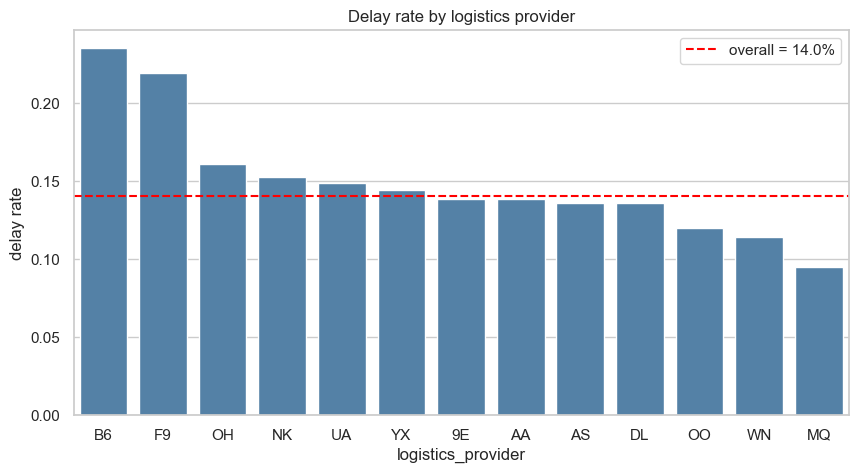

,delay_rate,n
logistics_provider,,
B6,0.235,2015
F9,0.219,1635
OH,0.160,424
NK,0.152,2213
UA,0.148,8145
YX,0.144,1484
9E,0.139,599
AA,0.138,9004
AS,0.136,2138


In [13]:
overall_rate = df[TARGET].mean()


def delay_rate_by(col, min_count=200):
    """Mean delay rate and transfer count per category of `col`, filtered by a
    minimum number of transfers so rates are not driven by tiny groups."""
    g = df.groupby(col)[TARGET].agg(delay_rate="mean", n="count")
    return g[g["n"] >= min_count].sort_values("delay_rate", ascending=False)


# Delay rate per logistics provider
provider_rate = delay_rate_by("logistics_provider", min_count=200)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=provider_rate.reset_index(), x="logistics_provider", y="delay_rate",
                 order=provider_rate.index, color="steelblue")
ax.axhline(overall_rate, color="red", linestyle="--", label=f"overall = {overall_rate:.1%}")
ax.set_title("Delay rate by logistics provider")
ax.set_ylabel("delay rate")
ax.legend()
plt.show()

provider_rate.round(3)

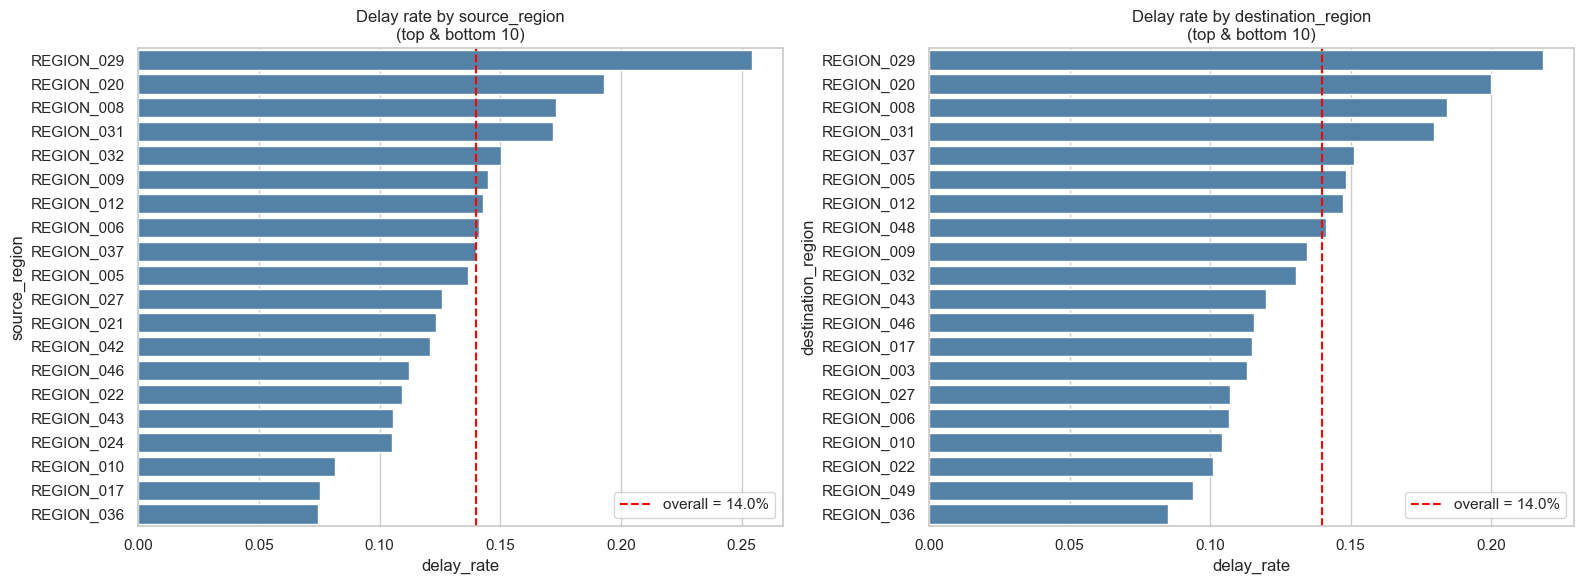

Source region delay rate – spread:min=7.5%, max=25.4%
Dest region delfdsfdsfsafdsa– spread:min=8.5%, max=21.9%


In [14]:
# Delay rate per source and destination region (top and bottom 10 by rate)
source_rate = delay_rate_by("source_region", min_count=200)
dest_rate = delay_rate_by("destination_region", min_count=200)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (rate, name) in zip(axes, [(source_rate, "source_region"), (dest_rate, "destination_region")]):
    extremes = pd.concat([rate.head(10), rate.tail(10)])
    sns.barplot(data=extremes.reset_index(), y=name, x="delay_rate", color="steelblue", ax=ax)
    ax.axvline(overall_rate, color="red", linestyle="--", label=f"overall = {overall_rate:.1%}")
    ax.set_title(f"Delay rate by {name}\n(top & bottom 10)")
    ax.legend()

fig.tight_layout()
plt.show()

print("Source region delay rate – spread:"
      f"min={source_rate['delay_rate'].min():.1%}, max={source_rate['delay_rate'].max():.1%}")
print("Dest region delfdsfdsfsafdsa– spread:"
      f"min={dest_rate['delay_rate'].min():.1%}, max={dest_rate['delay_rate'].max():.1%}")

### Answer 1

**Yes – there are clear differences both between providers and between regions.**

- **Providers:** delay rate ranges from ~9.4% (`MQ`) to ~23.5% (`B6`), against an overall 14%. `B6` and `F9` stand out as roughly **1.5–1.7× the average** delay rate, while large carriers such as `WN`, `DL` and `AA` sit at or slightly below average. The provider therefore carries real signal.
- **Regions:** the source region delay rate spans **7.5%–25.4%** and the destination region **8.5%–21.9%**. `REGION_029` is the worst on both ends (highest as a source *and* as a destination), while `REGION_036` is among the lowest on both. The consistency across source/destination suggests some regions are genuinely congestion-prone.

These differences are large relative to the 14% baseline, so `logistics_provider` and the region fields look like useful predictors and are worth encoding in the modelling phase.

### Q2 – Do certain departure hours have a higher probability of delay?

`scheduled_dispatch_time` is stored as an integer in `HHMM` format, so the hour is the value divided by 100. We extract the dispatch hour and compute the delay rate per hour across the day.

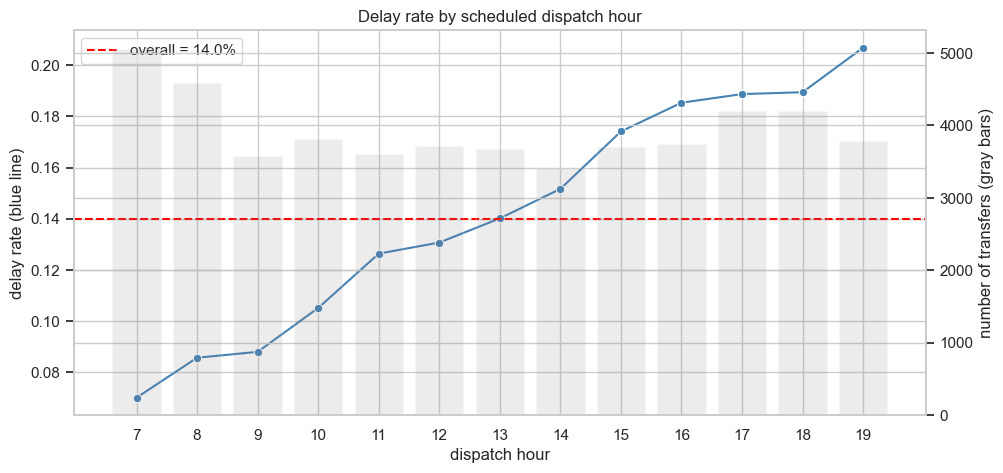

,delay_rate,n
dispatch_hour,,
7,0.070,5060
8,0.086,4583
9,0.088,3578
10,0.105,3813
11,0.126,3608
12,0.131,3718
13,0.140,3675
14,0.152,3409
15,0.174,3694


In [15]:
# Extract the dispatch hour from the HHMM integer and compute the delay rate per hour
df["dispatch_hour"] = df["scheduled_dispatch_time"] // 100

hourly = df.groupby("dispatch_hour")[TARGET].agg(delay_rate="mean", n="count")

fig, ax1 = plt.subplots(figsize=(11, 5))
sns.lineplot(data=hourly.reset_index(), x="dispatch_hour", y="delay_rate",
             marker="o", ax=ax1, color="steelblue")
ax1.axhline(overall_rate, color="red", linestyle="--", label=f"overall = {overall_rate:.1%}")
ax1.set_title("Delay rate by scheduled dispatch hour")
ax1.set_xlabel("dispatch hour")
ax1.set_ylabel("delay rate (blue line)")
ax1.set_xticks(hourly.index)
ax1.legend(loc="upper left")

# Number of transfers per hour for context
ax2 = ax1.twinx()
ax2.bar(hourly.index, hourly["n"], alpha=0.15, color="gray")
ax2.set_ylabel("number of transfers (gray bars)")
plt.show()

hourly.round(3)

### Answer 2

**Yes – the departure hour has a strong, almost monotonic effect.** All transfers are dispatched between 07:00 and 19:00. The delay rate rises steadily through the day: from only **~7%** for 07:00 departures to **~21%** for 19:00 departures – roughly a **3× difference**. The bars confirm that every hour has thousands of transfers, so the trend is not a small-sample artefact.

This matches the intuition that delays accumulate during the day (a transfer leaving late in the day is more exposed to earlier congestion and knock-on delays). `dispatch_hour` is clearly a valuable engineered feature for the model.

### Q3 – Relationship between departure delay and arrival delay

The dataset's arrival-delay information is the target itself: `is_delayed` marks transfers that arrived more than 30 minutes late. The departure-delay signal is `expected_dispatch_delay_minutes` (negative = dispatched early). We therefore study how the **departure delay** relates to the **probability of a significant arrival delay** (`is_delayed = 1`).

We use a boxplot of the departure delay split by the target, and a conditional-probability table where we bin the departure delay into ranges.

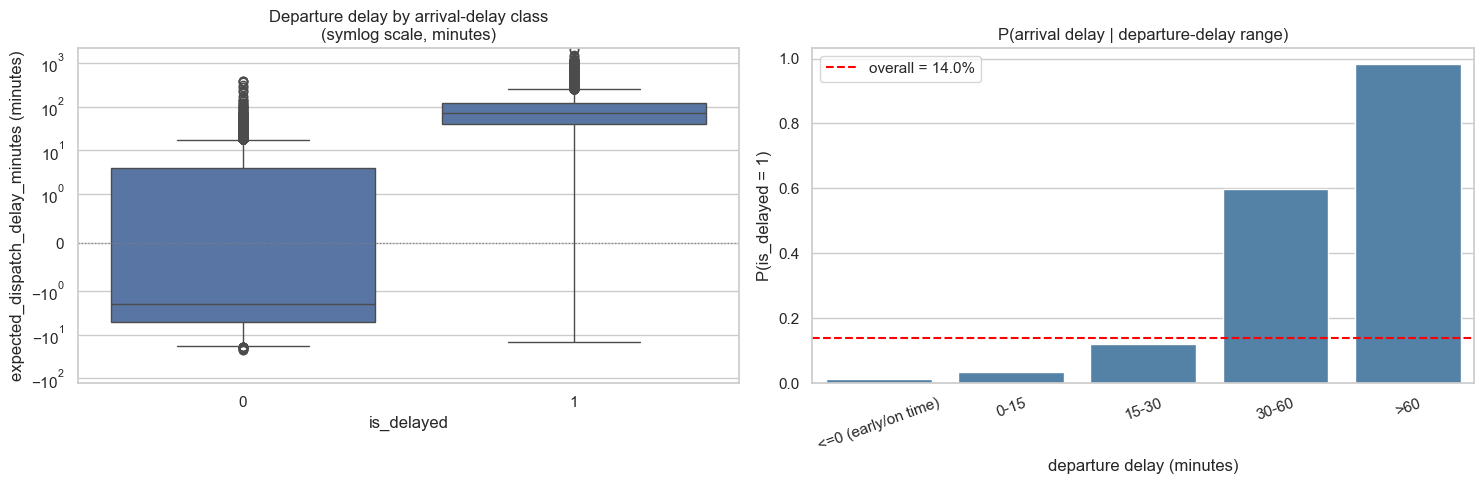

,p_arrival_delay,n
dispatch_delay_bin,,
<=0 (early/on time),0.012,29000
0-15,0.034,10280
15-30,0.121,3844
30-60,0.599,3155
>60,0.984,4156


In [16]:

# Departure delay distribution split by the arrival-delay target.
# Symlog scale: linear around 0 (|x| < 1 min) and logarithmic in both tails.
# This preserves negative values (early dispatch) and handles the heavy right tail
# without clipping or transforming the raw minute values.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df, x=TARGET, y="expected_dispatch_delay_minutes", ax=axes[0])
axes[0].set_yscale("symlog", linthresh=1)
axes[0].axhline(0, color="gray", linestyle=":", linewidth=0.9)
axes[0].set_title("Departure delay by arrival-delay class\n(symlog scale, minutes)")
axes[0].set_xlabel("is_delayed")
axes[0].set_ylabel("expected_dispatch_delay_minutes (minutes)")

# Conditional probability of a significant arrival delay given a departure-delay range
bins = [-np.inf, 0, 15, 30, 60, np.inf]
labels = ["<=0 (early/on time)", "0-15", "15-30", "30-60", ">60"]
df["dispatch_delay_bin"] = pd.cut(df["expected_dispatch_delay_minutes"], bins=bins, labels=labels)

cond_prob = df.groupby("dispatch_delay_bin", observed=True)[TARGET].agg(
    p_arrival_delay="mean", n="count")

sns.barplot(data=cond_prob.reset_index(), x="dispatch_delay_bin", y="p_arrival_delay",
            color="steelblue", ax=axes[1])
axes[1].axhline(overall_rate, color="red", linestyle="--", label=f"overall = {overall_rate:.1%}")
axes[1].set_title("P(arrival delay | departure-delay range)")
axes[1].set_xlabel("departure delay (minutes)")
axes[1].set_ylabel("P(is_delayed = 1)")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()

fig.tight_layout()
plt.show()

cond_prob.round(3)


### Answer 3

**Yes – there is a very strong relationship, and departure delay is the single most informative signal we have seen so far.**

- The boxplot shows that on-time transfers (`is_delayed = 0`) cluster around a *negative* departure delay (median ≈ −2 min, i.e. they leave slightly early), whereas delayed transfers have a much higher departure delay (median ≈ 70 min).
- The conditional-probability table makes the propagation explicit:
  - departure ≤ 0 min → only **1.2%** arrive significantly late,
  - 15–30 min → **12%**,
  - 30–60 min → **60%**,
  - \> 60 min → **98%**.

So a departure delay does not guarantee a late arrival until it grows past ~30 minutes, after which the probability of a significant arrival delay rises sharply. This makes intuitive sense (some of the departure delay can be absorbed by slack in the schedule, but large departure delays cannot be recovered). `expected_dispatch_delay_minutes` should be a top predictor.

### GOOVER Q4: Does the planned route distance affect the delay level?

We bin `route_distance_miles` into quantile groups (so each bin holds a similar number of transfers) and compute the delay rate per bin. Quantile binning is robust to the heavy right tail we saw earlier. We add a logistic trend line for the continuous view.

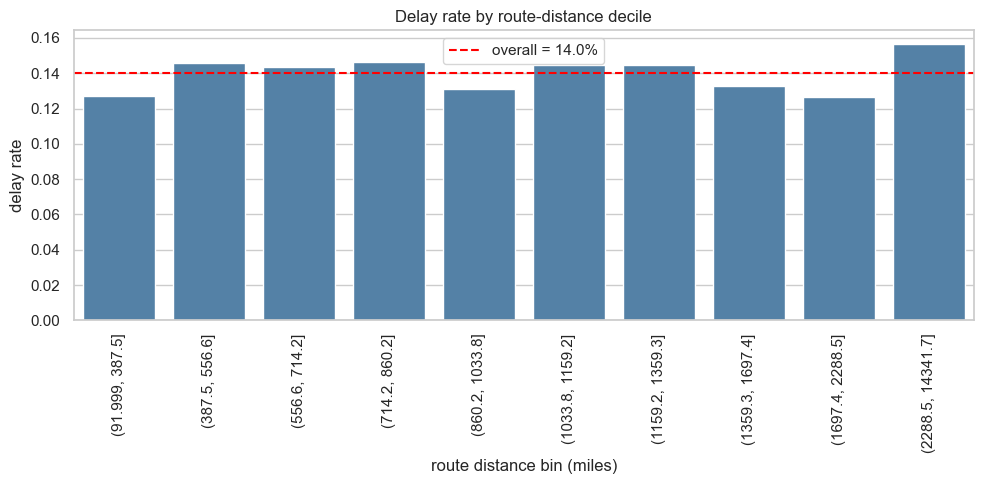

Pearson correlation (route_distance_miles, is_delayed): 0.006


,delay_rate,n
distance_bin,,
"(91.999, 387.5]",0.127,5148
"(387.5, 556.6]",0.146,5094
"(556.6, 714.2]",0.144,5134
"(714.2, 860.2]",0.146,5059
"(860.2, 1033.8]",0.131,5112
"(1033.8, 1159.2]",0.145,5101
"(1159.2, 1359.3]",0.144,5267
"(1359.3, 1697.4]",0.133,4977
"(1697.4, 2288.5]",0.126,5088


In [17]:
# Quantile bins of route distance -> delay rate per bin
df["distance_bin"] = pd.qcut(df["route_distance_miles"], q=10)
dist_rate = df.groupby("distance_bin", observed=True)[TARGET].agg(delay_rate="mean", n="count")

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(data=dist_rate.reset_index(), x="distance_bin", y="delay_rate",
            color="steelblue", ax=ax)
ax.axhline(overall_rate, color="red", linestyle="--", label=f"overall = {overall_rate:.1%}")
ax.set_title("Delay rate by route-distance decile")
ax.set_xlabel("route distance bin (miles)")
ax.set_ylabel("delay rate")
ax.tick_params(axis="x", rotation=90)
ax.legend()

fig.tight_layout()
plt.show()

# Correlation between raw distance and the target
corr_dist = df["route_distance_miles"].corr(df[TARGET])
print(f"Pearson correlation (route_distance_miles, is_delayed): {corr_dist:.3f}")
dist_rate.round(3)


### Answer 4

**No – the planned route distance has essentially no effect on the delay level.** Across all ten distance deciles the delay rate stays in a narrow **~12.6%–15.6%** band around the 14% baseline, with no monotonic trend. The Pearson correlation between `route_distance_miles` and `is_delayed` is only **0.006**, and the logistic trend line is almost flat. The longest-distance decile is marginally higher (15.6%), but the difference is small compared with the effects of provider, region, departure hour and departure delay.

Conclusion: distance on its own is a weak predictor. It may still contribute in interaction with other features, so we will not drop it outright, but we should not expect much from it.

### Q5 – Strong correlations between the different delay types?

We compute a correlation matrix over the six expected-delay columns plus the target. Because these columns are heavy-tailed and zero-inflated, **Spearman** (rank) correlation is more appropriate than Pearson, so we show Spearman and add Pearson for reference.

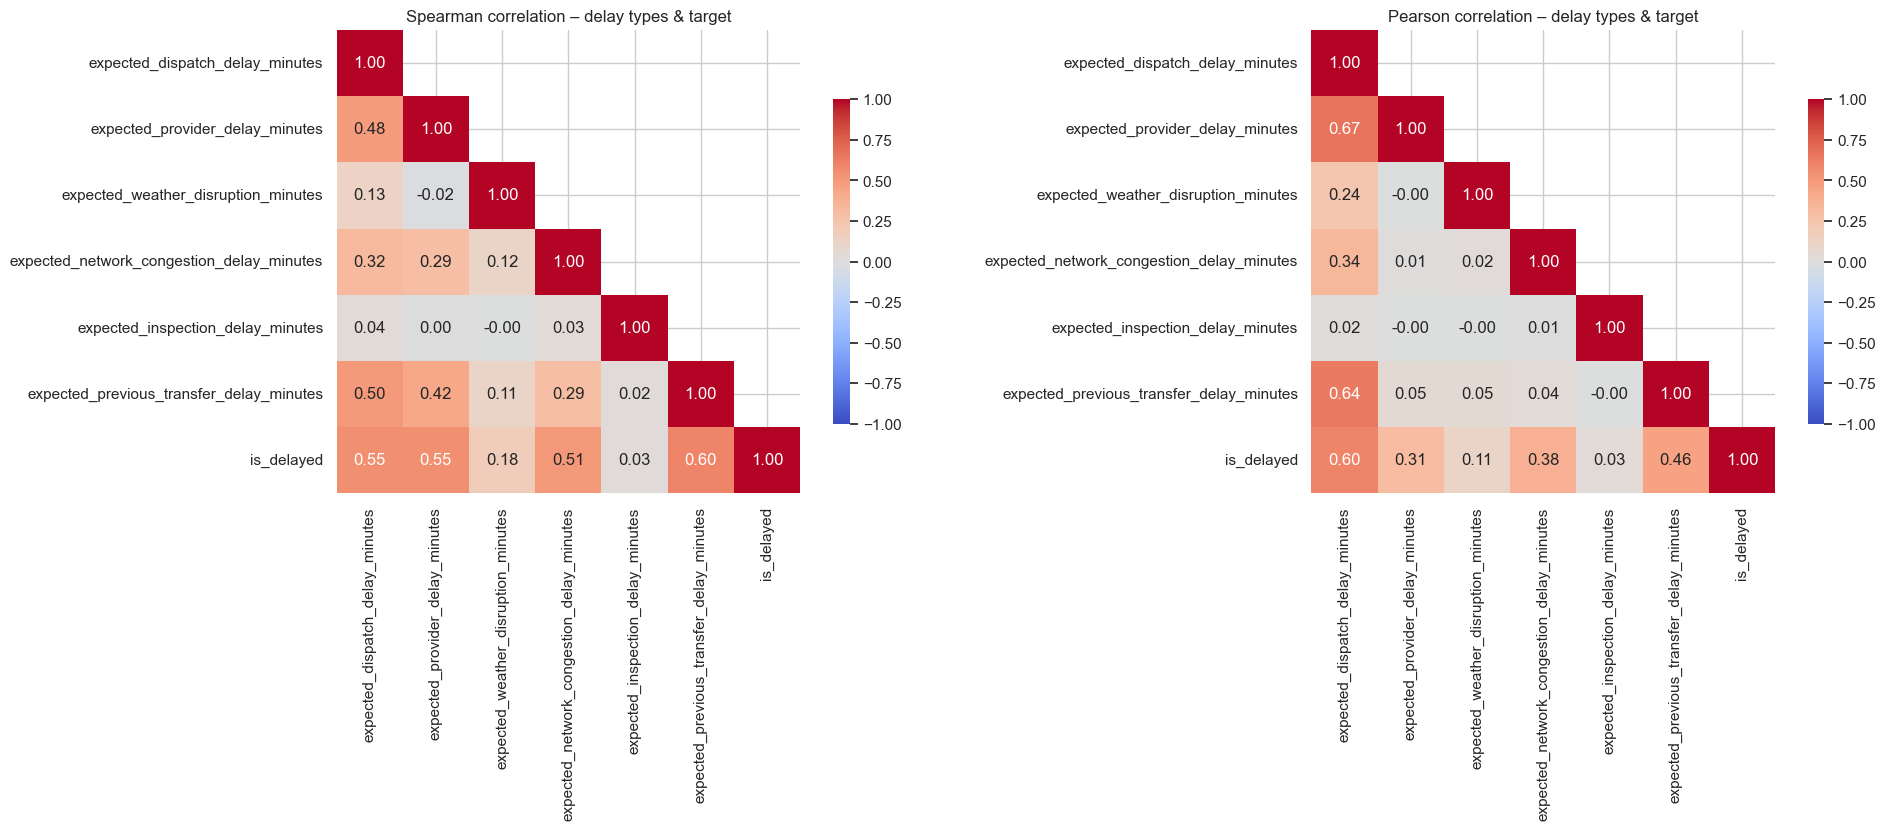

In [18]:
# Correlation between the delay types and the target (Spearman, with Pearson for reference)
corr_cols = delay_cols + [TARGET]

spearman_corr = df[corr_cols].corr(method="spearman")
pearson_corr = df[corr_cols].corr(method="pearson")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, (corr, name) in zip(axes, [(spearman_corr, "Spearman"), (pearson_corr, "Pearson")]):
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.7}, ax=ax)
    ax.set_title(f"{name} correlation – delay types & target")

fig.tight_layout()
plt.show()

### Answer 5

**There are moderate – but not extreme – correlations between the delay types, and several of them correlate well with the target.**

- **With the target (Spearman):** `expected_previous_transfer_delay_minutes` (0.60), `expected_dispatch_delay_minutes` (0.55), `expected_provider_delay_minutes` (0.55) and `expected_network_congestion_delay_minutes` (0.51) are the strongest. `expected_weather_disruption_minutes` (0.18) is weak and `expected_inspection_delay_minutes` (0.03) is essentially unrelated.
- **Between delay types:** the highest pairings are dispatch ↔ previous-transfer (0.50), dispatch ↔ provider (0.48) and provider ↔ previous-transfer (0.42). These are moderate, meaning the delay sources move together somewhat (a bad transfer tends to be late on several axes at once) but **none is strong enough (≥ 0.8) to call two columns redundant**, so we would not drop any of them purely for collinearity.
- Pearson and Spearman tell the same story; Pearson is inflated for `expected_dispatch_delay_minutes` because of its extreme tail, which is exactly why the rank-based Spearman is the safer read here.

`expected_inspection_delay_minutes` stands out as a near-useless feature (flagged again in Q6).

### Q5b – Feature-to-feature scatter plot matrix (pair plot)

To complement the correlation heatmap we plot a **scatter plot matrix of all six expected-delay features**. Each off-diagonal scatter shows the joint distribution of two features coloured by `is_delayed`; the diagonal shows the per-class KDE. Because every delay column is zero-inflated and right-skewed, we plot the raw minute values on a **symlog scale** (linear near 0, logarithmic in both tails) so that the bulk of the data (0–60 min) spreads out instead of collapsing onto the origin, while still showing the negative early-dispatch values. Axis tick labels are kept in real minutes for readability. A random sample of 3,000 rows is used for speed.


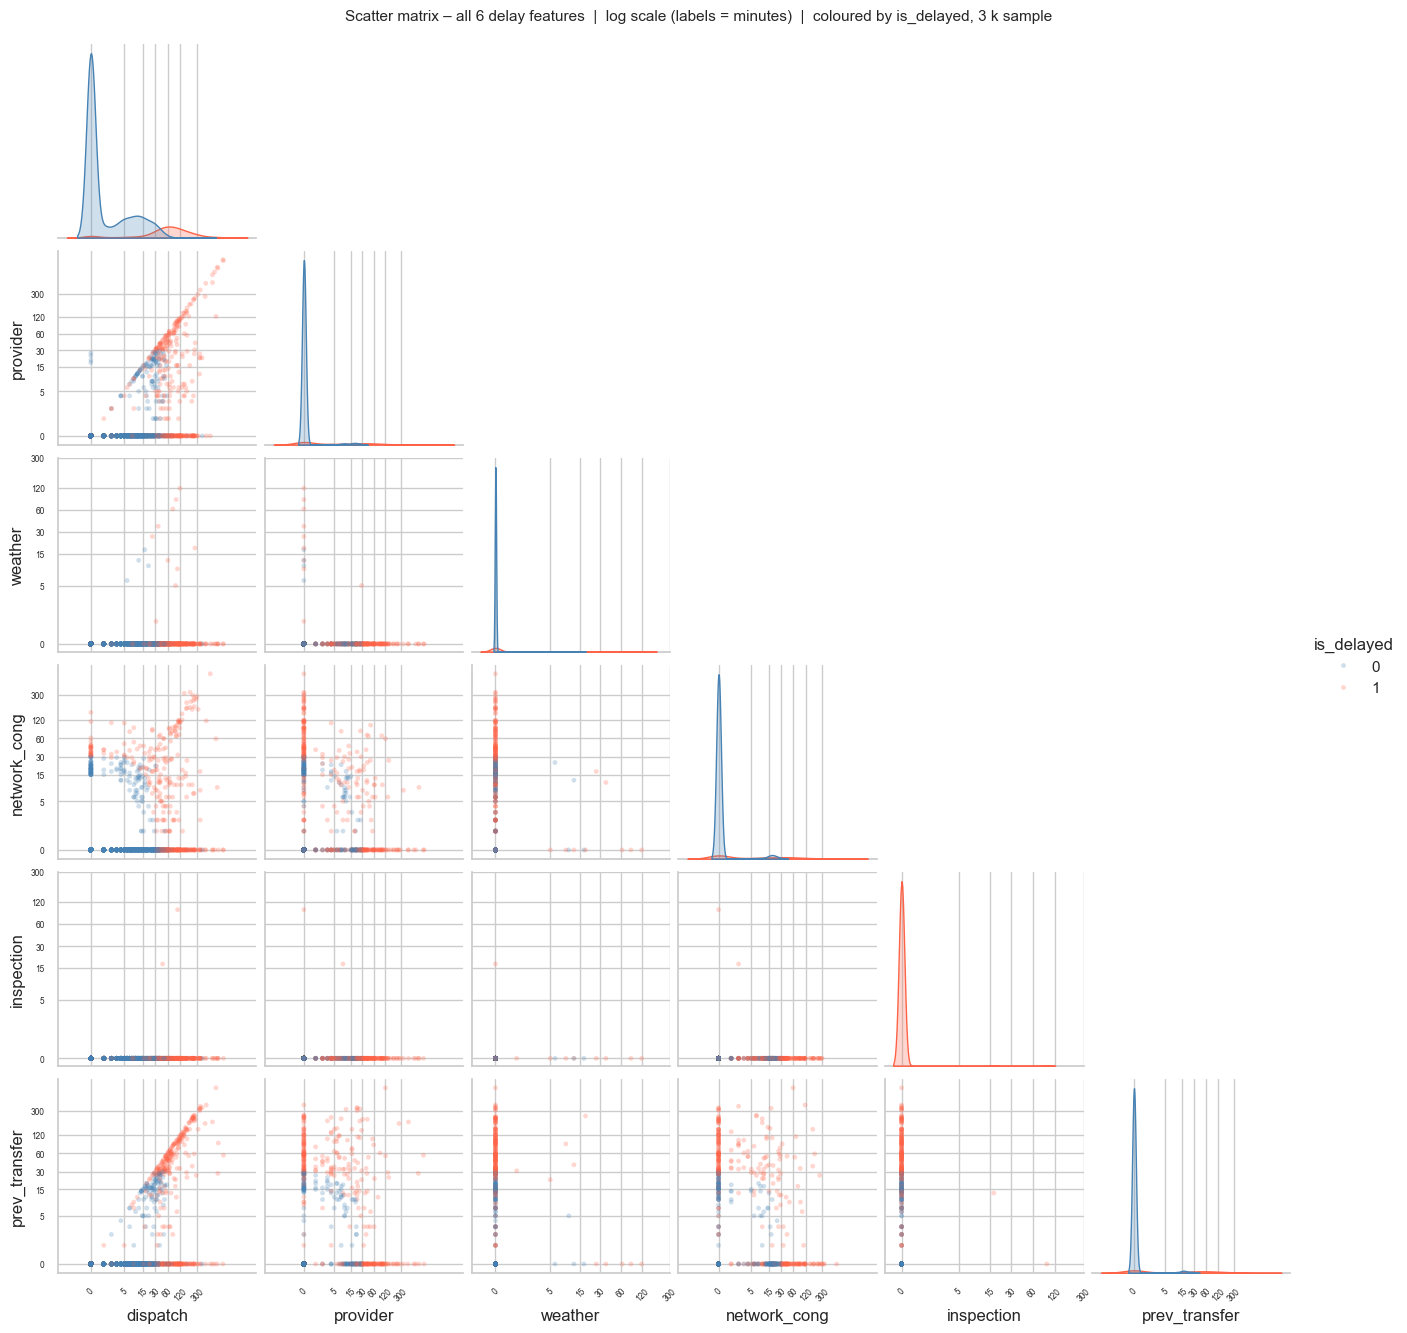

In [19]:

# Scatter plot matrix of ALL six delay features, coloured by target.
#
# All delay columns are zero-inflated with a heavy right tail, so a linear
# scale collapses most points onto (0, 0).  We log-transform the values
# (shifting by 1 to handle zeros) so the informative small-delay region
# spreads out while extreme outliers are compressed.

pairplot_cols = [
    "expected_dispatch_delay_minutes",
    "expected_provider_delay_minutes",
    "expected_weather_disruption_minutes",
    "expected_network_congestion_delay_minutes",
    "expected_inspection_delay_minutes",
    "expected_previous_transfer_delay_minutes",
]
short_names = [
    "dispatch",
    "provider",
    "weather",
    "network_cong",
    "inspection",
    "prev_transfer",
]

sample_pp = df[pairplot_cols + [TARGET]].sample(3000, random_state=RANDOM_STATE).copy()

# Log-transform: log1p(max(x, 0)) to handle zeros and negatives safely.
# Negative values (e.g. early dispatch) are clipped to 0 before the transform.
plot_data = pd.DataFrame(
    {short: np.log1p(sample_pp[col].clip(lower=0).values)
     for col, short in zip(pairplot_cols, short_names)},
)
plot_data[TARGET] = sample_pp[TARGET].values

# Readable tick positions in original minutes, mapped through log1p
ref_minutes = [0, 5, 15, 30, 60, 120, 300]
tick_vals = [np.log1p(m) for m in ref_minutes]
tick_labels = [str(m) for m in ref_minutes]

g = sns.pairplot(
    plot_data,
    hue=TARGET,
    palette={0: "steelblue", 1: "tomato"},
    plot_kws={"alpha": 0.25, "s": 12, "linewidth": 0},
    diag_kind="kde",
    corner=True,
    height=2.2,
    aspect=1,
)

for ax in g.axes.flatten():
    if ax is None:
        continue
    ax.set_xticks(tick_vals)
    ax.set_xticklabels(tick_labels, fontsize=6, rotation=45)
    ax.set_yticks(tick_vals)
    ax.set_yticklabels(tick_labels, fontsize=6)

g.figure.suptitle(
    "Scatter matrix – all 6 delay features  |  log scale (labels = minutes)"
    "  |  coloured by is_delayed, 3 k sample",
    y=1.01,
    fontsize=11,
)
plt.show()


### Q6 – Do any anonymous features look influential on the target?

We treat two groups of features as "anonymous" — their real-world meaning is hidden or encoded as opaque IDs:

1. **Numeric `internal_*` features** — five columns whose semantics are unknown. We compute the Spearman correlation with `is_delayed` and show the per-class distribution via boxplots.
2. **Categorical ID features** — `source_facility`, `destination_facility`, `source_region`, `destination_region`. These are encoded as opaque string codes with no disclosed geography or hierarchy. We compute the delay rate per category and show the top & bottom 10 to reveal whether specific IDs are systematically high- or low-risk.


Spearman correlation of internal_* features with is_delayed:
internal_timestamp_a          0.241
internal_timestamp_b          0.159
internal_metric_a             0.145
internal_metric_b             0.063
internal_operational_score    0.000
Name: is_delayed, dtype: float64


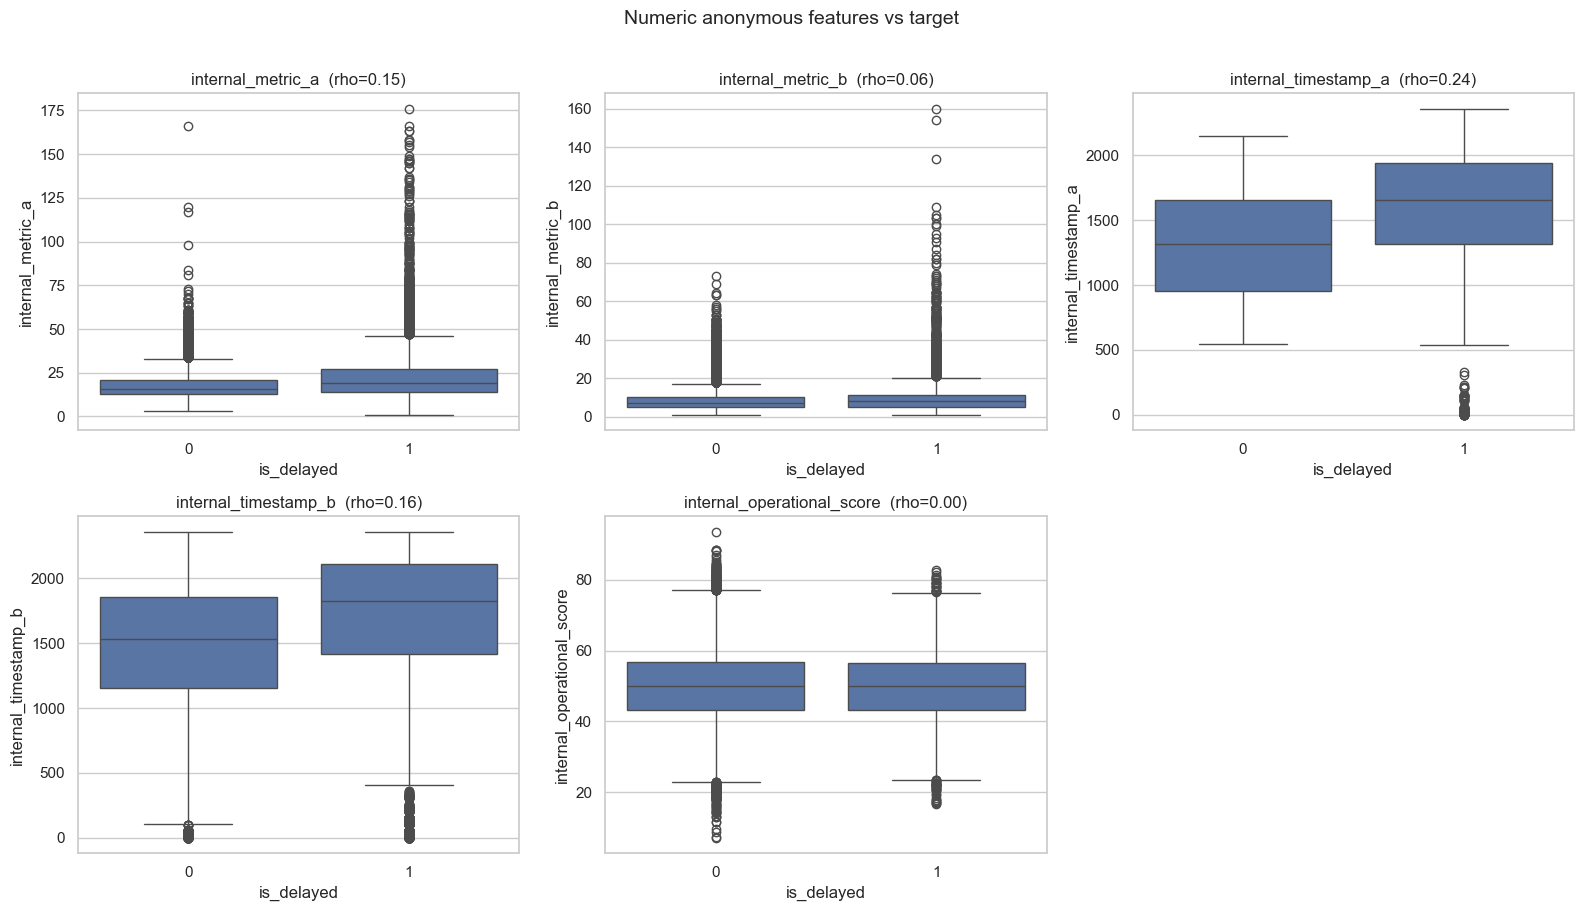

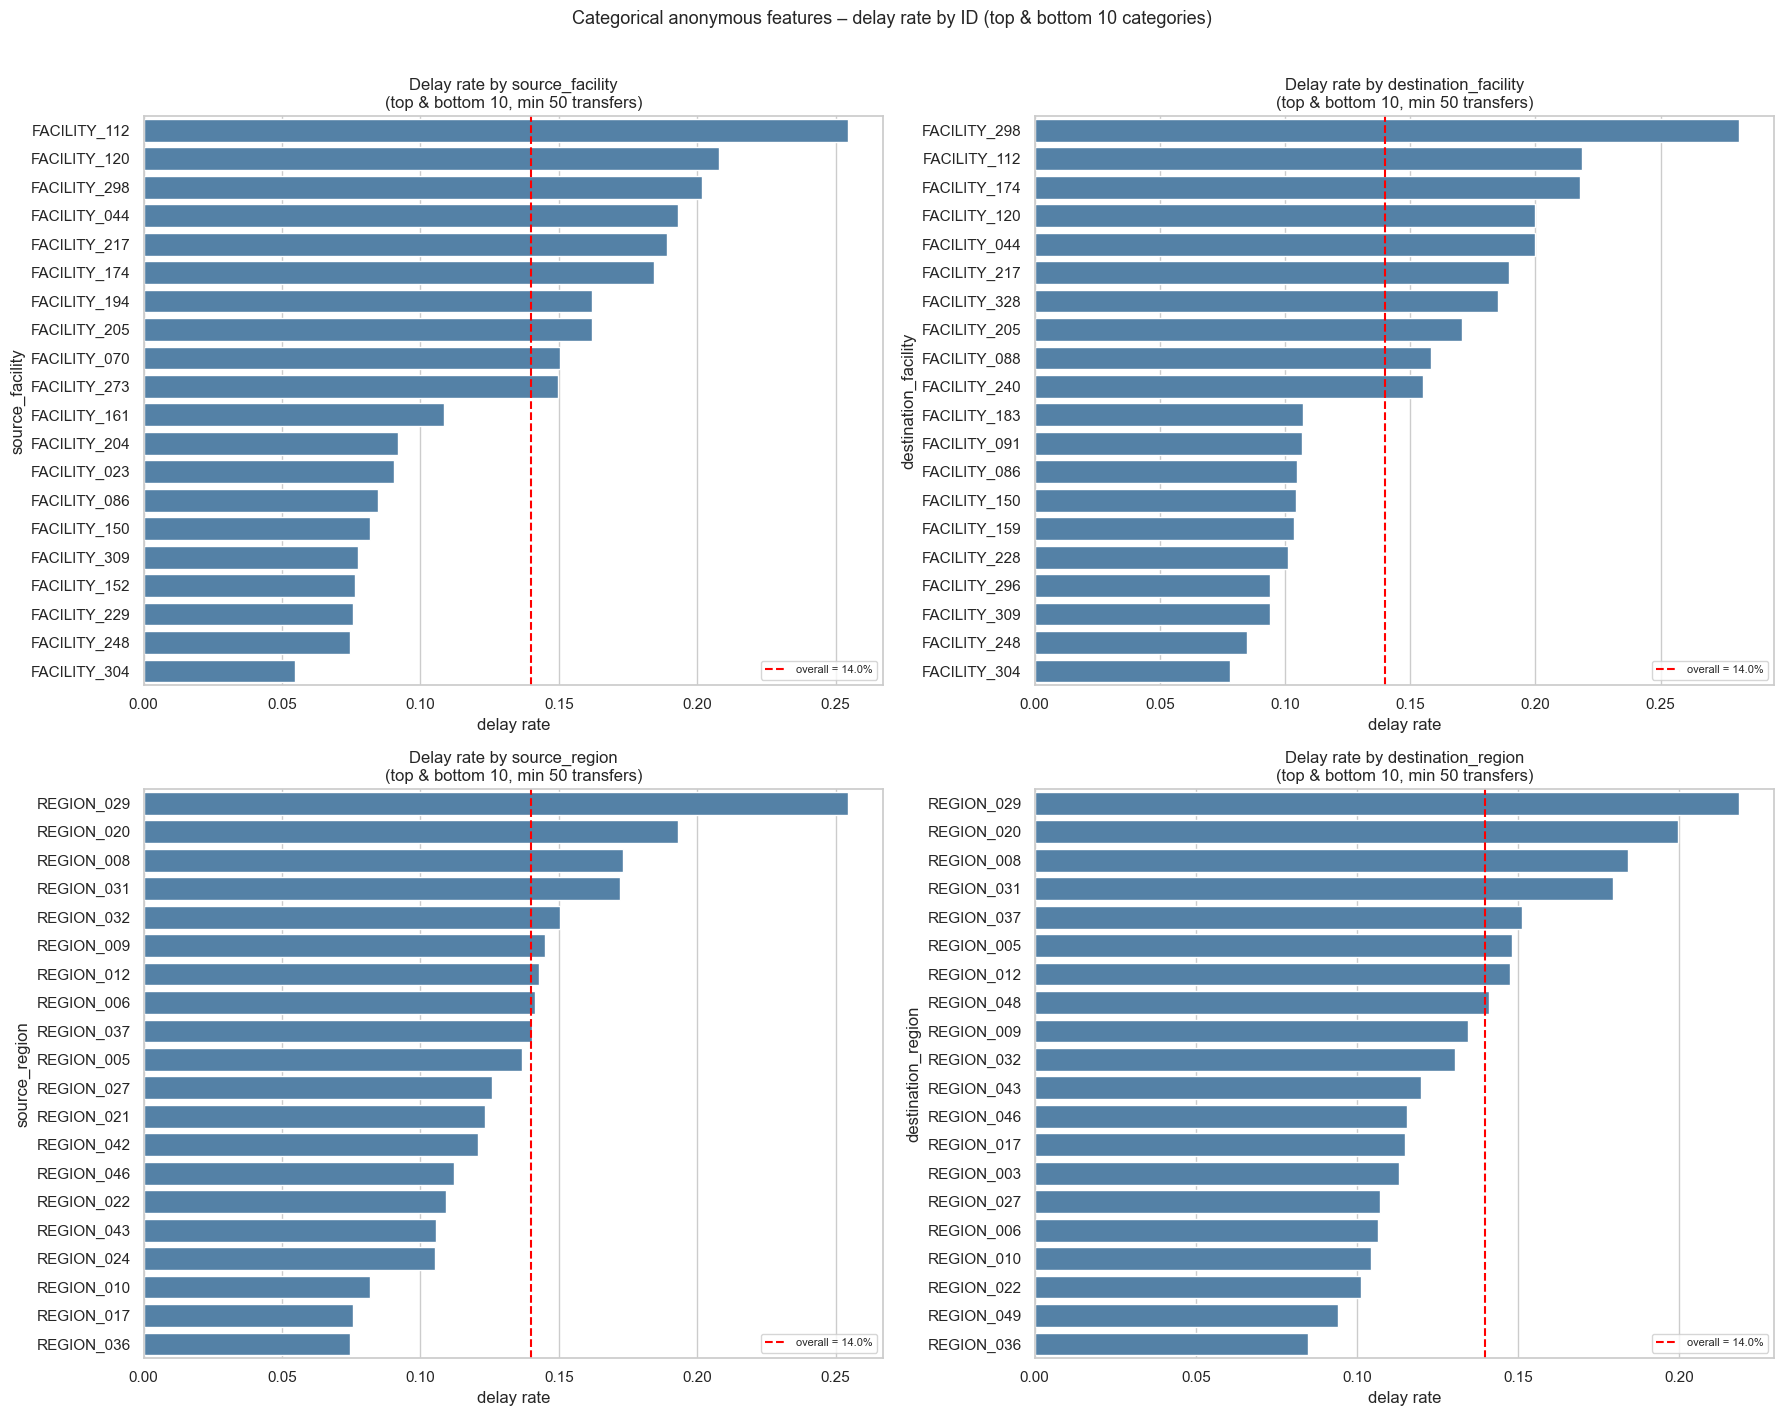


Delay-rate spread per categorical anonymous feature:
  source_facility                 min=5.5%  max=25.4%  n_categories=40
  destination_facility            min=7.8%  max=28.1%  n_categories=40
  source_region                   min=7.5%  max=25.4%  n_categories=24
  destination_region              min=8.5%  max=21.9%  n_categories=24


In [20]:

# ── Part A: Numeric internal_* features ──────────────────────────────────────
anon_corr = (df[anon_cols + [TARGET]].corr(method="spearman")[TARGET]
             .drop(TARGET).sort_values(key=np.abs, ascending=False))
print("Spearman correlation of internal_* features with is_delayed:")
print(anon_corr.round(3))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, col in zip(axes, anon_cols):
    sns.boxplot(data=df, x=TARGET, y=col, ax=ax)
    ax.set_title(f"{col}  (rho={anon_corr[col]:.2f})")
    ax.set_xlabel("is_delayed")
for ax in axes[len(anon_cols):]:
    ax.set_visible(False)
fig.suptitle("Numeric anonymous features vs target", y=1.01, fontsize=14)
fig.tight_layout()
plt.show()

# ── Part B: Categorical anonymous ID features (facilities & regions) ──────────
# source_facility, destination_facility, source_region, destination_region are
# all encoded as opaque IDs with no disclosed meaning — making them anonymous.
# We show the delay rate for the top & bottom 10 categories (min 50 transfers).
cat_anon_cols = [
    "source_facility",
    "destination_facility",
    "source_region",
    "destination_region",
]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for ax, col in zip(axes, cat_anon_cols):
    rate = df.groupby(col)[TARGET].agg(delay_rate="mean", n="count")
    rate = rate[rate["n"] >= 50].sort_values("delay_rate", ascending=False)
    extremes = pd.concat([rate.head(10), rate.tail(10)]).drop_duplicates()
    sns.barplot(data=extremes.reset_index(), y=col, x="delay_rate",
                color="steelblue", ax=ax)
    ax.axvline(overall_rate, color="red", linestyle="--",
               label=f"overall = {overall_rate:.1%}")
    ax.set_title(f"Delay rate by {col}\n(top & bottom 10, min 50 transfers)")
    ax.set_xlabel("delay rate")
    ax.legend(fontsize=8)

fig.suptitle(
    "Categorical anonymous features – delay rate by ID (top & bottom 10 categories)",
    y=1.01, fontsize=13,
)
fig.tight_layout()
plt.show()

# Spread summary for all categorical anonymous features
print("\nDelay-rate spread per categorical anonymous feature:")
for col in cat_anon_cols:
    rate = df.groupby(col)[TARGET].agg(delay_rate="mean", n="count")
    rate = rate[rate["n"] >= 50]
    print(f"  {col:30s}  min={rate['delay_rate'].min():.1%}  "
          f"max={rate['delay_rate'].max():.1%}  "
          f"n_categories={len(rate)}")


### Answer 6

**Numeric `internal_*` features:**
- `internal_timestamp_a` (ρ = 0.24) and `internal_timestamp_b` (ρ = 0.16) are the strongest anonymous predictors; the boxplots show clearly higher values for delayed transfers. Combined with their 0–2359 range, they most likely encode *actual* dispatch/arrival clock times, which naturally relate to lateness.
- `internal_metric_a` (ρ = 0.14) carries a mild signal; `internal_metric_b` (ρ = 0.06) is weak.
- `internal_operational_score` has ρ ≈ **0.00** and **identical distributions** in both classes – despite being the only nicely Gaussian feature, it looks like uninformative noise.

**Categorical ID features (facilities & regions):**
- **Facilities:** `source_facility` and `destination_facility` show substantial delay-rate variation across IDs (spread comparable to the region features). Certain facility codes are systematically high-risk, making them useful categorical predictors despite their opaque names.
- **Regions:** `source_region` and `destination_region` were examined in Q1 and show a wide spread (~7–25% delay rate). The same pattern is visible here: a handful of region IDs (`REGION_029`, etc.) are clear hotspots on both origin and destination sides.

All four categorical ID features carry real signal and should be encoded (e.g. target-encoding or leave-one-out encoding given the many categories) in the modelling phase.


### Q7: Which features look irrelevant / low-value for prediction?

This is the synthesis question. We pull together everything found in Q1–Q6 and add a single, comparable ranking of how strongly each feature relates to the target. To avoid relying on one statistic, every **numeric** feature is scored with three complementary measures:

- **Spearman ρ** – monotonic (rank) association, robust to the heavy tails of the delay columns.
- **Point-biserial correlation** – the linear (Pearson) association between a continuous feature and the binary target.
- **ANOVA F-test** – tests whether the feature's mean differs between on-time and delayed transfers (the significance test from class), reported as an F statistic and p-value.

For the **categorical** features (regions, facilities, provider, weekday) correlation is undefined, so we use the **delay-rate spread** (max − min over categories with at least 50 transfers) as the comparable measure of signal. Because the sample is large (~51k rows), almost every feature comes out "statistically significant" (p ≈ 0); we therefore judge low value by **effect size**, not by the p-value alone.


**What the earlier questions already told us about feature value:**

- **Q1** – `logistics_provider` and the region fields separate the delay rate strongly (≈9–25%): real signal.
- **Q2 (`dispatch_hour`)** – the departure hour is almost monotonic (7% → 21% across the day): a useful engineered feature.
- **Q3** – `expected_dispatch_delay_minutes` is the single strongest driver of a significant arrival delay.
- **Q4** – `route_distance_miles` is essentially flat across deciles (corr ≈ 0): a prime low-value candidate.
- **Q5** – four delay sources correlate well with the target, but `expected_inspection_delay_minutes` (ρ ≈ 0.03) stands out as near-useless.
- **Q6** – `internal_timestamp_a/b` and `internal_metric_a` carry signal; `internal_operational_score` (ρ ≈ 0) and `internal_metric_b` (ρ ≈ 0.06) are weak; the facility / region IDs carry signal.

The ranking below confirms these observations using the three numeric measures and the categorical delay-rate spread together.


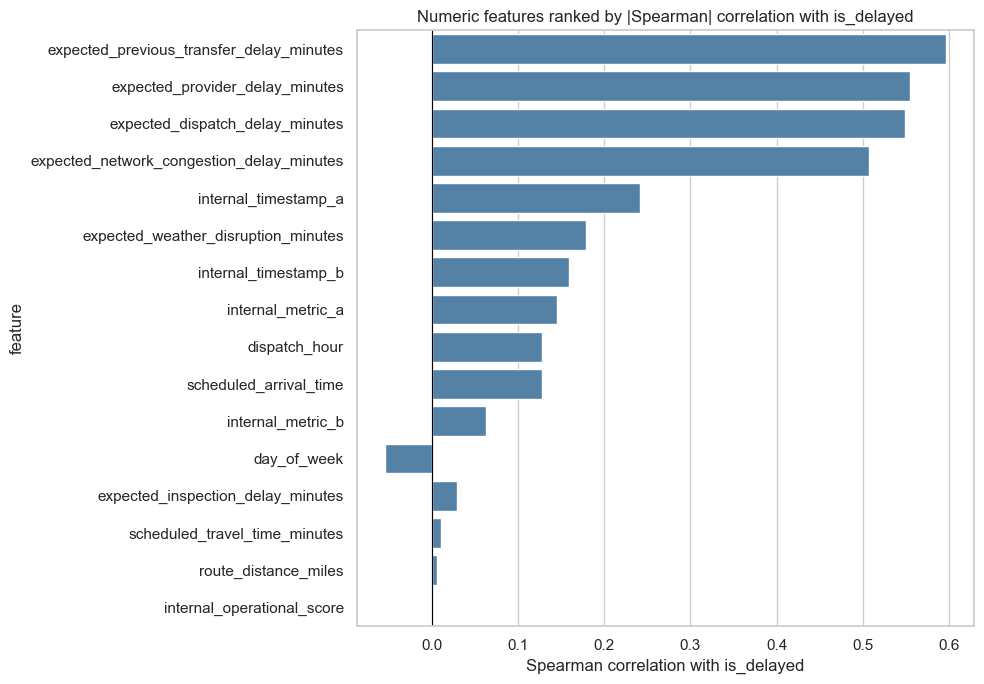

Categorical features – delay-rate spread (min 50 transfers per category):
                      n_categories  min_rate  max_rate  spread
feature                                                       
destination_facility            40     0.078     0.281   0.203
source_facility                 40     0.055     0.254   0.200
source_region                   24     0.075     0.254   0.180
day_of_week                      7     0.082     0.240   0.158
logistics_provider              14     0.094     0.235   0.140
destination_region              24     0.085     0.219   0.134

Note: with ~51k rows the ANOVA p-value is ~0 for almost every feature, so
statistical significance is necessary but NOT sufficient – we judge low value
by a small effect size (|correlation| and a flat delay rate), not by the p-value.

Numeric features – association with the target (sorted by |Spearman|):


,spearman,point_biserial,anova_F,anova_p
feature,,,,
expected_previous_transfer_delay_minutes,0.596,0.459,13614.888,0.000
expected_provider_delay_minutes,0.555,0.306,4890.403,0.000
expected_dispatch_delay_minutes,0.548,0.598,28123.694,0.000
expected_network_congestion_delay_minutes,0.507,0.380,7933.659,0.000
internal_timestamp_a,0.241,0.245,3223.109,0.000
expected_weather_disruption_minutes,0.179,0.112,581.605,0.000
internal_timestamp_b,0.159,0.106,573.473,0.000
internal_metric_a,0.145,0.238,2558.003,0.000
dispatch_hour,0.128,0.128,855.952,0.000


In [21]:
from scipy import stats

# Rank every NUMERIC feature by its association with the target using three
# complementary measures, so the conclusion does not rest on Spearman alone:
#   * Spearman rho   – monotonic (rank) association, robust to the heavy tails.
#   * Point-biserial – linear (Pearson) association between a continuous
#                      feature and the binary 0/1 target.
#   * ANOVA F-test   – tests whether the feature's mean differs between the
#                      on-time and delayed groups (F statistic + p-value),
#                      exactly the significance test discussed in class.
numeric_features = (df.select_dtypes(include=[np.number])
                      .columns.drop([TARGET, "scheduled_dispatch_time"]))

rows = []
for col in numeric_features:
    sub = df[[col, TARGET]].dropna()           # pairwise drop of missing values
    x, y = sub[col], sub[TARGET]
    rho = x.corr(y, method="spearman")
    r_pb = x.corr(y)                           # Pearson == point-biserial for a 0/1 target
    f_stat, p_val = stats.f_oneway(x[y == 0], x[y == 1])
    rows.append({"feature": col, "spearman": rho, "point_biserial": r_pb,
                 "anova_F": f_stat, "anova_p": p_val})

feature_assoc = pd.DataFrame(rows).set_index("feature")
feature_assoc = feature_assoc.reindex(
    feature_assoc["spearman"].abs().sort_values(ascending=False).index)
feature_strength = feature_assoc["spearman"]   # kept for the bar plot below

# Delay-rate spread for the CATEGORICAL features: correlation is undefined for
# them, so we measure how far the per-category delay rate moves from the 14%
# baseline (max - min over categories with at least 50 transfers).
cat_cols_q7 = ["logistics_provider", "source_region", "destination_region",
               "source_facility", "destination_facility", "day_of_week"]
cat_rows = []
for col in cat_cols_q7:
    rate = df.groupby(col)[TARGET].agg(delay_rate="mean", n="count")
    rate = rate[rate["n"] >= 50]
    cat_rows.append({"feature": col, "n_categories": len(rate),
                     "min_rate": rate["delay_rate"].min(),
                     "max_rate": rate["delay_rate"].max(),
                     "spread": rate["delay_rate"].max() - rate["delay_rate"].min()})
cat_assoc = pd.DataFrame(cat_rows).set_index("feature").sort_values(
    "spread", ascending=False)

# Visual: numeric features ranked by |Spearman| with the target
plt.figure(figsize=(10, 7))
sns.barplot(x=feature_strength.values, y=feature_strength.index, color="steelblue")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Numeric features ranked by |Spearman| correlation with is_delayed")
plt.xlabel("Spearman correlation with is_delayed")
plt.tight_layout()
plt.show()

print("Categorical features – delay-rate spread (min 50 transfers per category):")
print(cat_assoc.round(3).to_string())
print("\nNote: with ~51k rows the ANOVA p-value is ~0 for almost every feature, so")
print("statistical significance is necessary but NOT sufficient – we judge low value")
print("by a small effect size (|correlation| and a flat delay rate), not by the p-value.\n")
print("Numeric features – association with the target (sorted by |Spearman|):")
feature_assoc.round(3)


### Answer 7

**Yes – a small group of features carries little or no usable signal, and the three measures agree on which ones.**

**Irrelevant (no usable signal – not even statistically significant despite ~51k rows):**
- `internal_operational_score` – Spearman 0.00, point-biserial −0.001, ANOVA F = 0.04 (p = 0.84). The only Gaussian feature, but its distribution is identical in both classes: pure noise.
- `route_distance_miles` – Spearman 0.007, F = 2.03 (p = 0.16). Confirms Q4: distance on its own does not move the delay rate.

**Very low value (significant only because the sample is large, but the effect size is negligible, |r| ≤ 0.03):**
- `scheduled_travel_time_minutes` – |r| = 0.01 (p = 0.03).
- `expected_inspection_delay_minutes` – |r| = 0.03, F = 50. The weakest of the six delay sources by a wide margin.

**Looks weak by correlation but should keep (this is exactly why we used more than Spearman):**
- `day_of_week` – monotonic correlation is tiny (−0.05), yet its per-weekday delay rate spans ≈8–24% (spread 0.16). The effect is non-monotonic, so a single correlation hides it; it should be encoded categorically rather than dropped.
- `internal_metric_b` – borderline (Spearman 0.06 but point-biserial 0.10); keep for now and re-check with model-based importance.

**Conclusion.** `internal_operational_score` and `route_distance_miles` are the clearest features to drop, with `scheduled_travel_time_minutes` and `expected_inspection_delay_minutes` close behind – all four are weak under every measure (rank, linear and mean-difference).We remove `internal_operational_score` and `route_distance_miles` as they are irrelevant but We will **not** remove the rest blindly in this part. We can still expose value hidden in interactions, so we keep a shortlist to verify, not a final deletion. By contrast, every categorical field (provider, regions, facilities and weekday) shows a wide delay-rate spread and is worth keeping and encoding.


### Conclusions

- **Size & target.** The training set has **51,056 transfers and 23 columns**. The target `is_delayed` is binary and **imbalanced**: only ~**14%** of transfers are delayed by more than 30 minutes. AUC (the project metric) is a sensible choice given this imbalance.
- **Column roles.** We can group the columns into: *scheduling/time* fields (`scheduled_dispatch_time`, `scheduled_arrival_time`, `day_of_week`, `operation_date`), *route* fields (`scheduled_travel_time_minutes`, `route_distance_miles`), six *expected delay* fields, five anonymous *internal_* fields, and *categorical* identifiers (regions, facilities, provider). The time fields are stored as integers in `HHMM` format (e.g. `830` = 08:30).
- **Missing values.** Nine columns contain missing values, the largest being `internal_metric_a` (16.3%), `expected_inspection_delay_minutes` (12.0%) and `internal_metric_b` (11.3%). No column is missing more than ~16%, so none should be dropped purely for missingness; we will impute them in the preprocessing phase.
- **Skew & outliers.** The six expected-delay columns are strongly **zero-inflated and right-skewed** (75th percentile is 0 for most of them, but maxima reach ~1,000–2,000 minutes). `expected_dispatch_delay_minutes` ranges from −22 (early dispatch) to 2,120 minutes. `route_distance_miles` has a clear outlier tail (max 14,342 vs. a 75th percentile of ~1,498). `internal_operational_score` looks roughly symmetric around 50. These point to heavy-tailed distributions that we examine next.

## Exploration Summary

Main takeaways from Part 1, to carry into preprocessing and modelling:

- **Target.** Binary and imbalanced (~14% delayed); AUC is the right metric.
- **Strongest predictors.** The expected-delay sources – `expected_previous_transfer_delay_minutes`, `expected_provider_delay_minutes`, `expected_dispatch_delay_minutes`, `expected_network_congestion_delay_minutes` – plus the engineered `dispatch_hour` and the anonymous `internal_timestamp_a/b`.
- **Departure → arrival propagation.** Departure delays above ~30 minutes translate into a very high probability of a significant arrival delay (60% at 30–60 min, 98% above 60 min).
- **Categorical signal.** Both `logistics_provider` and the region fields show large delay-rate differences; provider text needs whitespace normalisation.
- **Weak / noise features.** `route_distance_miles`, `scheduled_travel_time_minutes`, `expected_inspection_delay_minutes` and `internal_operational_score` show almost no marginal link to the target.
- **Preprocessing to-do (Part 2).** Handle missing values (up to ~16%), the heavy right tails / outliers in the delay columns, normalisation/scaling, categorical encoding, and re-check the weak features with model-based importance before dropping.

*Helper columns created during exploration (`dispatch_hour`, `dispatch_delay_bin`, `distance_bin`) are kept only for analysis; the formal feature engineering is done in Part 2.*

In [22]:
# The provider plot shows some codes twice -> check for inconsistent text (spaces / casing)
provider_counts = df["logistics_provider"].value_counts()
print(provider_counts)
print("\nRaw unique values (repr to expose whitespace/case):")
print([repr(v) for v in df["logistics_provider"].unique()])

logistics_provider
WN    10897
DL     9579
AA     9004
UA     8145
NK     2213
AS     2138
B6     2015
OO     2014
F9     1635
YX     1484
MQ      709
9E      599
OH      424
HA      188
G4       12
Name: count, dtype: int64

Raw unique values (repr to expose whitespace/case):
["'UA'", "'9E'", "'AA'", "'NK'", "'MQ'", "'HA'", "'G4'", "'F9'", "'DL'", "'B6'", "'AS'", "'WN'", "'OO'", "'YX'", "'OH'"]


## Part 2: Data Preprocessing

In this part we turn the raw table into a clean, fully numeric feature matrix that the models in Part 3 can consume. Every transformation is wrapped in a single scikit-learn `ColumnTransformer` / `Pipeline` object, which is **fit on the training split only** and then re-applied unchanged to the validation set and to the test set. This keeps the workflow reproducible and, more importantly, leakage-safe.

### Order of operations and why

The steps are applied in the following order:

1. **Train / validation split first.** Before computing *any* statistic (medians, scaling parameters, target-encoding values) we separate a validation set. If we fit these on the full data, information from the validation/test rows would leak into the training features and inflate our performance estimate.
2. **Feature construction.** All engineered features (departure/arrival hour, departure/arrival time in minutes, total expected delay, a missing-value counter) are purely row-local, so they are created right after the split. Doing this early means every later step (imputation, scaling, encoding) also processes the new columns.
3. **Missing-value imputation.** Done before outlier handling and scaling so that the later numeric steps never see `NaN`. We implement **two interchangeable strategies** (median or KNN) controlled by a single switch; both add a missing-value indicator.
4. **Outlier handling.** The heavy-tailed delay columns are compressed with a signed-log transform and then optionally winsorised (clipped to train quantiles, toggled by `USE_WINSORIZE`). This happens after imputation (no `NaN`) and before scaling, so the scaler is not distorted by the extreme tails.
5. **Normalisation / scaling.** A `StandardScaler` puts every numeric feature on a comparable scale. This must come after outlier taming, otherwise a few extreme values would dominate the mean and standard deviation.
6. **Categorical encoding.** Low-cardinality fields are one-hot encoded; the high-cardinality ID fields are target-encoded. Encoders are fit on the training fold only.
7. **Dimensionality.** We drop the features judged irrelevant in Part 1, prefer target encoding over one-hot for the ID fields to avoid a column explosion, and run a PCA experiment on the correlated delay block.
8. **Apply to the test set.** The same fitted pipeline is finally applied to `test.csv`.


In [ ]:
# Preprocessing imports
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, FunctionTransformer
from sklearn.decomposition import PCA

# --- Configuration switches -------------------------------------------------
# Missing-value strategy. Flip this single flag to swap the whole imputation
# approach; the rest of the notebook re-runs unchanged.
#   "median" -> median imputation + a binary missing-value indicator per column
#   "knn" -> K-Nearest-Neighbours imputation (distance based)
# Both strategies add the per-column missing-value indicators.
IMPUTE_METHOD = "median"
KNN_N_NEIGHBORS = 5 # only used when IMPUTE_METHOD == "knn"

WINSOR_LIMITS = (0.01, 0.99) # quantiles used to clip outliers (train-based)
USE_WINSORIZE = True # toggle outlier winsorising on/off to compare its effect
VAL_SIZE = 0.1 # fraction held out for validation

assert IMPUTE_METHOD in {"median", "knn"}
print(f"Imputation method: {IMPUTE_METHOD}")
print(f"Winsorising outliers: {USE_WINSORIZE}")


### Reload the data and split before any fitting

Part 1 modified `df` in place (added helper columns, stripped text). To start preprocessing from a clean, well-defined state we reload the raw CSV into `df_raw`. We then immediately split it into a training and a validation set, **stratified on the target** so both sets keep the ~14% delayed rate.

The split is the very first thing we do: every transformer that *learns* something from the data (medians, scaling parameters, target-encoding tables) will be fit on the training set only. The validation set is treated exactly like unseen test data.


In [24]:
# Reload a clean copy of the raw training data (Part 1 mutated `df`).
df_raw = pd.read_csv(TRAIN_PATH)

X_raw = df_raw.drop(columns=[TARGET])
y = df_raw[TARGET]

# Stratified train/validation split, done before any model is fit.
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_raw, y,
    test_size=VAL_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train:", X_train_raw.shape, "| delayed rate:", round(y_train.mean(), 4))
print("Val:  ", X_val_raw.shape, "| delayed rate:", round(y_val.mean(), 4))


Train: (45950, 22) | delayed rate: 0.1399
Val:   (5106, 22) | delayed rate: 0.1398


### Feature construction (manipulating and building predictors)

Guided by Part 1, we build a small set of new predictors and drop the raw columns they replace. All of these are computed **per row**, so they introduce no leakage and can be applied identically to the test set.

- **`dispatch_hour`, `arrival_hour`** – the hour extracted from the `HHMM` time integers. Part 1 (Q2) showed the departure hour has a strong, near-monotonic effect on the delay rate, so the hour is more useful than the raw `HHMM` value (which jumps from `759` to `800`).
- **`dispatch_time`, `arrival_time`** – the same scheduled times expressed as **minutes since midnight** (`hour×60 + minute`). This keeps the finer within-hour resolution that the hour buckets throw away, while remaining a smooth, evenly-spaced numeric scale (unlike the raw `HHMM` integers).
- **`total_expected_delay`** – the sum of the six expected-delay columns. A single aggregate of "how much delay is expected from all sources" is a compact, strong signal.
- **`n_missing`** – the number of missing fields in the row. Missingness may not be random (e.g. records with incomplete logging could behave differently), so we keep it as an explicit feature.

We also drop the two features Part 1 found to be pure noise (`route_distance_miles`, `internal_operational_score`) and the raw `HHMM`/date columns that have been replaced (`operation_date` is dropped without a calendar feature). The anonymous `internal_timestamp_a/b` are kept as numeric features (Part 1 found they carry signal). The function is written once and reused for the training, validation and test data.


In [ ]:
# Raw columns that are dropped after engineering (replaced or judged irrelevant).
RAW_DELAY_COLS = [
    "expected_dispatch_delay_minutes",
    "expected_provider_delay_minutes",
    "expected_weather_disruption_minutes",
    "expected_network_congestion_delay_minutes",
    "expected_inspection_delay_minutes",
    "expected_previous_transfer_delay_minutes",
]
DROP_COLS = [
    "route_distance_miles",        # Part 1: no signal
    "internal_operational_score",  # Part 1: pure noise
    "scheduled_dispatch_time",     # replaced by dispatch_hour / dispatch_time
    "scheduled_arrival_time",      # replaced by arrival_hour / arrival_time
    "operation_date",              # dropped (no calendar feature kept)
]


def engineer_features(data):
    """Build engineered predictors from the raw transfer table.

    The transformation is purely row-local (no statistics learned across rows),
    so it can be applied to train, validation and test data without leakage.
    `is_delayed` / `transfer_id` are dropped here if present; they are handled
    by the caller.
    """
    data = data.copy()

    # Normalise text fields (fixes the trailing-whitespace provider duplicates).
    text_cols = data.select_dtypes(include=["object", "string"]).columns
    data[text_cols] = data[text_cols].apply(lambda s: s.str.strip())

    # Count missing fields per row before we impute anything (missingness signal).
    data["n_missing"] = data.isnull().sum(axis=1)

    # Hour of day from the HHMM time integers.
    data["dispatch_hour"] = data["scheduled_dispatch_time"] // 100
    data["arrival_hour"] = data["scheduled_arrival_time"] // 100

    # Minutes since midnight from the HHMM time integers (finer-grained than the
    # hour alone): HHMM -> hour*60 + minute.
    data["dispatch_time"] = ((data["scheduled_dispatch_time"] // 100) * 60
                             + data["scheduled_dispatch_time"] % 100)
    data["arrival_time"] = ((data["scheduled_arrival_time"] // 100) * 60
                            + data["scheduled_arrival_time"] % 100)

    # Aggregate expected delay across all sources (missing treated as 0 minutes).
    data["total_expected_delay"] = data[RAW_DELAY_COLS].sum(axis=1, skipna=True)

    # Remove raw columns that were replaced or found irrelevant in Part 1.
    drop_now = [c for c in DROP_COLS + [TARGET, "transfer_id"] if c in data.columns]
    return data.drop(columns=drop_now)


X_train = engineer_features(X_train_raw)
X_val = engineer_features(X_val_raw)

print("Engineered feature columns:", X_train.shape[1])
X_train.head()


In [26]:
# Column groups for the ColumnTransformer, defined on the engineered features.
DELAY_FEATURES = RAW_DELAY_COLS  # heavy-tailed, zero-inflated -> signed-log + winsorise

NUMERIC_FEATURES = [
    "scheduled_travel_time_minutes",
    "internal_metric_a",
    "internal_metric_b",
    "internal_timestamp_a",
    "internal_timestamp_b",
    "dispatch_hour",
    "arrival_hour",
    "dispatch_time",
    "arrival_time",
    "total_expected_delay",
    "n_missing",
]
# Low-cardinality categoricals -> one-hot encoding.
ONEHOT_FEATURES = ["logistics_provider", "day_of_week"]
# High-cardinality opaque IDs -> target encoding (avoids a huge one-hot matrix).
TARGET_FEATURES = ["source_region", "destination_region",
                   "source_facility", "destination_facility"]

assert set(DELAY_FEATURES + NUMERIC_FEATURES + ONEHOT_FEATURES + TARGET_FEATURES) == set(X_train.columns)


# Signed log: sign(x) * log1p(|x|). Compresses the heavy tails of the delay
# columns while preserving the negative early-dispatch values and keeping 0 at 0.
def signed_log1p(X):
    return np.sign(X) * np.log1p(np.abs(X))


signed_log = FunctionTransformer(signed_log1p, feature_names_out="one-to-one")


class Winsorizer(BaseEstimator, TransformerMixin):
    """Clip each column to quantile bounds learned on the training fold."""

    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lo_ = np.nanquantile(X, self.lower, axis=0)
        self.hi_ = np.nanquantile(X, self.upper, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.lo_, self.hi_)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)


print(f"{len(DELAY_FEATURES)} delay | {len(NUMERIC_FEATURES)} numeric | "
      f"{len(ONEHOT_FEATURES)} one-hot | {len(TARGET_FEATURES)} target-encoded")


6 delay | 11 numeric | 2 one-hot | 4 target-encoded


### Is there missing data? How is it handled?

**Yes.** Part 1 found nine columns with missing values, up to ~16% (`internal_metric_a` 16.3%, `expected_inspection_delay_minutes` 12.0%, `internal_metric_b` 11.3%). No column is missing enough to justify dropping it, so we **impute**. The table below recomputes the missing rate on the *training fold* (the only data we are allowed to learn from).

We implement **two interchangeable strategies**, selected by the single `IMPUTE_METHOD` switch defined at the top of Part 2:

1. **`"median"` (default): median imputation + a missing-value indicator.** Each numeric column is filled with its training median, and a separate binary column flags which values were originally missing. The median is robust to the heavy right tails of the delay columns (far better than the mean), and the indicator lets the model use *the fact that a value was missing* as a signal in case missingness is informative.
2. **`"knn"`: K-Nearest-Neighbours imputation.** Each missing value is filled from the average of its `k=5` most similar rows. Because KNN is distance based, we standardise the numeric block *before* the KNN step so that a wide-range column (e.g. the 0–2359 timestamps) does not dominate the distance. KNN can be more accurate than a single global median because it conditions on similar transfers, at the cost of being slower.

The binary **missing-value indicator is added for both strategies**, so the model always sees *which* values were originally missing regardless of how they were filled.


We use the **median + indicator** method in the final workflow: it is simple, fast, robust and keeps the missingness signal explicit. The KNN variant is kept as an alternative that can be switched on with one flag.

In [27]:
# Missing rate per feature on the training fold (engineered features).
train_missing = pd.DataFrame({
    "missing_count": X_train.isnull().sum(),
    "missing_pct": (X_train.isnull().mean() * 100).round(2),
})
train_missing = train_missing[train_missing["missing_count"] > 0] \
    .sort_values("missing_pct", ascending=False)
train_missing


,missing_count,missing_pct
internal_metric_a,7504,16.33
expected_inspection_delay_minutes,5544,12.07
internal_metric_b,5172,11.26
expected_weather_disruption_minutes,4580,9.97
expected_network_congestion_delay_minutes,3672,7.99
expected_provider_delay_minutes,3203,6.97
internal_timestamp_b,603,1.31
internal_timestamp_a,593,1.29
expected_dispatch_delay_minutes,549,1.19


### Are there outliers? How are they handled?

**Yes.** Part 1 showed that the six expected-delay columns are zero-inflated with extreme right tails (single values up to ~2,000 minutes), and `total_expected_delay` inherits the same shape. These extremes are *genuine* operational events, not data-entry errors, and we must still produce a prediction for every test row, so **we do not delete any rows**. Instead we tame the tails in two steps:

1. **Signed-log transform** `sign(x)·log1p(|x|)` on the delay columns. This compresses the heavy right tail, keeps the zero spike at zero, and preserves the small negative "early dispatch" values.
2. **Winsorising** – after the transform we clip every numeric column to its 1st/99th training-set percentiles. This caps the few remaining extreme values so they cannot dominate the scaler or the distance-based models, while keeping the bulk of the distribution intact. This step is **toggleable** via the `USE_WINSORIZE` flag so its effect on the models can be measured with and without it.

Both bounds are learned on the training fold only and re-applied to validation/test. The plot below shows the effect of the signed-log step on one delay column.


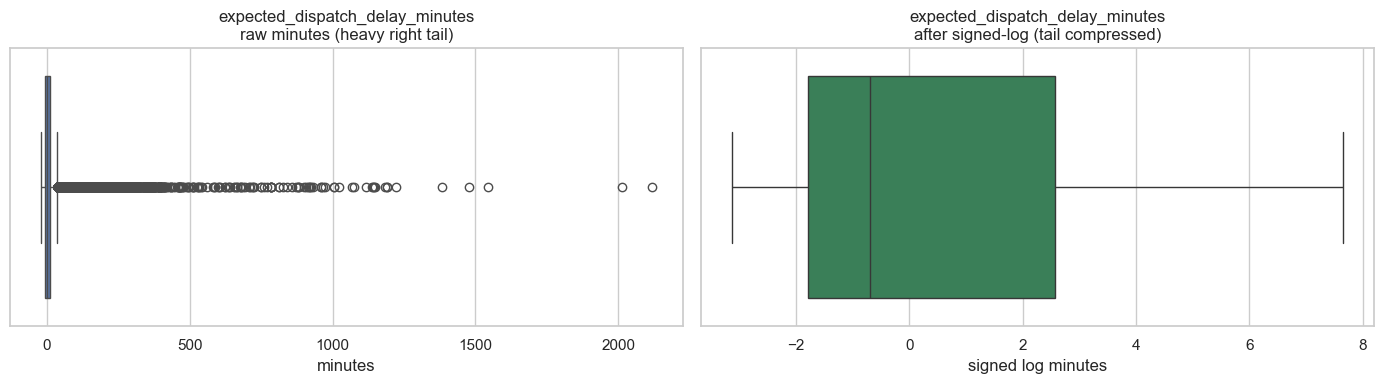

raw max = 2120 min  ->  signed-log max = 7.66


In [28]:
# Illustrate the outlier-taming effect of the signed-log transform on one column.
demo_col = "expected_dispatch_delay_minutes"
raw_vals = X_train[demo_col].dropna()
logged_vals = signed_log1p(raw_vals)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x=raw_vals, ax=axes[0])
axes[0].set_title(f"{demo_col}\nraw minutes (heavy right tail)")
axes[0].set_xlabel("minutes")

sns.boxplot(x=logged_vals, ax=axes[1], color="seagreen")
axes[1].set_title(f"{demo_col}\nafter signed-log (tail compressed)")
axes[1].set_xlabel("signed log minutes")

fig.tight_layout()
plt.show()

print(f"raw max = {raw_vals.max():.0f} min  ->  signed-log max = {logged_vals.max():.2f}")


### Is the data normalised? Does it need to be?

**No, the raw data is not normalised** – the features live on wildly different scales: delays in minutes (0–2,000), `internal_timestamp_*` on a 0–2359 clock, `dispatch_time`/`arrival_time` 0–1439 minutes, `day_of_week` 1–7, `n_missing` 0–9. We therefore standardise every numeric feature with a `StandardScaler` (subtract the training mean, divide by the training standard deviation), fit on the training fold only.

**Why it matters here.** In Part 3 we will use distance- and gradient-based models (KNN, Logistic Regression, SVM, a neural network). For these, a feature's influence scales with its numeric range, so without normalisation the large-range columns (timestamps, delay minutes) would dominate the distance metric and slow or distort the optimisation. Standardising puts all features on equal footing. The KNN *imputer* needs the same treatment, which is why the `"knn"` branch standardises before imputing. (Tree-based models such as Random Forest are scale-invariant and would not strictly require this, but a single scaled matrix that works for every model keeps the pipeline simple.)


### Handling categorical variables

The categorical fields split naturally into two groups by cardinality, and we encode them differently:

- **Low cardinality → one-hot encoding** (`logistics_provider`, 14 codes after whitespace cleanup; `day_of_week`, 7 values). One-hot keeps every category as its own indicator without imposing a false order, and 14 + 7 columns is cheap. `handle_unknown="ignore"` makes the encoder robust to any provider/day that appears only in the test set.
- **High cardinality → target (mean) encoding** (`source_region`, `destination_region`, `source_facility`, `destination_facility` – dozens to hundreds of opaque IDs each). One-hot encoding these would add hundreds of sparse columns and blow up the dimensionality. Instead each category is replaced by the **mean delay rate of that category**, learned only on the training fold. scikit-learn's `TargetEncoder` uses internal cross-fitting and smoothing toward the global rate, which protects against overfitting on rare categories and leakage. Part 1 showed these IDs have a wide delay-rate spread, so this single numeric column per field captures most of their signal.

`day_of_week` is treated as categorical (one-hot) rather than numeric because Part 1 (Q7) showed its effect on the delay rate is non-monotonic, so an ordinal encoding would be misleading.


In [ ]:
def build_preprocessor(method="median"):
    """Assemble the full preprocessing ColumnTransformer.

    `method` selects the imputation strategy and keeps every other step fixed:
      "median" -> SimpleImputer(median) + a separate MissingIndicator branch
      "knn"    -> scale (NaN-aware) -> KNNImputer
    Both strategies add explicit per-column missing-value indicators.
    Delay columns additionally get the signed-log transform up front, every
    numeric column is standardised, and winsorising is applied when
    `USE_WINSORIZE` is on.
    """
    # Winsorising is optional so its effect on the models can be compared.
    winsor_step = [("winsor", Winsorizer(*WINSOR_LIMITS))] if USE_WINSORIZE else []

    if method == "median":
        delay_steps = [
            ("signed_log", signed_log),
            ("impute", SimpleImputer(strategy="median")),
            *winsor_step,
            ("scale", StandardScaler()),
        ]
        num_steps = [
            ("impute", SimpleImputer(strategy="median")),
            *winsor_step,
            ("scale", StandardScaler()),
        ]
    else:  # "knn": StandardScaler ignores NaN in fit, so KNN works on a fair scale
        delay_steps = [
            ("signed_log", signed_log),
            ("scale", StandardScaler()),
            ("knn", KNNImputer(n_neighbors=KNN_N_NEIGHBORS)),
            *winsor_step,
        ]
        num_steps = [
            ("scale", StandardScaler()),
            ("knn", KNNImputer(n_neighbors=KNN_N_NEIGHBORS)),
            *winsor_step,
        ]

    branches = [
        ("delay", Pipeline(delay_steps), DELAY_FEATURES),
        ("num", Pipeline(num_steps), NUMERIC_FEATURES),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ONEHOT_FEATURES),
        # cv=StratifiedKFold(...) replaces the deprecated shuffle=/random_state=
        # arguments TargetEncoder used to accept directly (removed in newer
        # scikit-learn versions in favour of passing a CV generator).
        ("target", TargetEncoder(
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        ), TARGET_FEATURES),
        # Explicit per-column missing-value indicators, kept for both strategies
        # so the model always sees *which* values were originally missing.
        ("missing_flags", MissingIndicator(features="missing-only"),
         DELAY_FEATURES + NUMERIC_FEATURES),
    ]

    return ColumnTransformer(branches, remainder="drop",
                             verbose_feature_names_out=False)


preprocessor = build_preprocessor(IMPUTE_METHOD)
preprocessor


In [30]:
# Fit on the training fold only, then transform train and validation.
# fit_transform lets TargetEncoder use its leakage-safe cross-fitting on train.
X_train_proc = preprocessor.fit_transform(X_train, y_train)
X_val_proc = preprocessor.transform(X_val)

feature_names = preprocessor.get_feature_names_out()
X_train_proc = pd.DataFrame(X_train_proc, columns=feature_names, index=X_train.index)
X_val_proc = pd.DataFrame(X_val_proc, columns=feature_names, index=X_val.index)

# Sanity checks: nothing missing, train and validation share the same columns.
assert not X_train_proc.isnull().any().any(), "NaNs remain in processed train"
assert not X_val_proc.isnull().any().any(), "NaNs remain in processed val"
assert list(X_train_proc.columns) == list(X_val_proc.columns)

print(f"Processed train: {X_train_proc.shape} | val: {X_val_proc.shape}")
print(f"Total features after encoding: {X_train_proc.shape[1]}")
X_train_proc.head()


Processed train: (45950, 52) | val: (5106, 52)
Total features after encoding: 52


c:\Users\adidi\anaconda3\envs\Advanced_programming\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


,expected_dispatch_delay_minutes,expected_provider_delay_minutes,expected_weather_disruption_minutes,expected_network_congestion_delay_minutes,expected_inspection_delay_minutes,expected_previous_transfer_delay_minutes,scheduled_travel_time_minutes,internal_metric_a,internal_metric_b,internal_timestamp_a,...,destination_facility,missingindicator_expected_dispatch_delay_minutes,missingindicator_expected_provider_delay_minutes,missingindicator_expected_weather_disruption_minutes,missingindicator_expected_network_congestion_delay_minutes,missingindicator_expected_inspection_delay_minutes,missingindicator_internal_metric_a,missingindicator_internal_metric_b,missingindicator_internal_timestamp_a,missingindicator_internal_timestamp_b
47958,0.310466,-0.329173,0.0,-0.333265,0.0,-0.338960,-0.122414,0.146905,2.290926,-0.373245,...,0.170230,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
49740,0.722707,-0.329173,0.0,-0.333265,0.0,-0.338960,-0.434548,0.279087,-1.042594,0.652277,...,0.147174,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2064,-0.969139,-0.329173,0.0,-0.333265,0.0,-0.338960,2.921021,1.336542,-0.258236,-1.568456,...,0.293759,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2158,-1.119049,-0.329173,0.0,-0.333265,0.0,-0.338960,-1.226891,-0.249641,-0.650415,0.730974,...,0.132213,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
32172,1.343027,0.368650,0.0,-0.333265,0.0,2.596332,0.801986,0.279087,0.526121,0.706381,...,0.126101,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


### Assessment of the problem's dimensionality

The raw table has 22 predictors, but the *effective* dimensionality is what matters. Our choices keep it modest:

- **Feature selection.** We dropped the features Part 1 found to be noise (`route_distance_miles`, `internal_operational_score`) and replaced four raw time/date columns with more informative engineered ones, so we add signal without inflating the count.
- **Encoding choice controls the blow-up.** The high-cardinality ID fields (regions, facilities) have dozens–hundreds of categories each; one-hot encoding all four would create hundreds of sparse columns and risk the curse of dimensionality. **Target encoding collapses each of them to a single dense numeric column**, which is the main dimensionality-control decision here. Only the genuinely low-cardinality fields are one-hot encoded.

The result is a compact matrix (≈30 columns, mostly dense). With ~40k training rows this is a comfortable rows-to-columns ratio, so aggressive dimensionality *reduction* is not strictly necessary. Still, Part 1 (Q5) showed the six delay columns are moderately correlated, so as an **experiment** we run PCA on that block to quantify the redundancy. We do **not** feed the PCA output into the final pipeline – it is kept only to document the analysis, since collapsing the delay columns would cost interpretability for little gain.


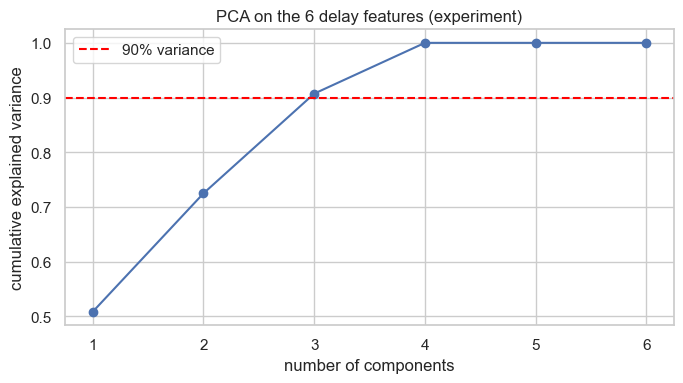

3 of 6 components explain >=90% of the delay-block variance.
Kept as analysis only; the final feature matrix uses the original delay columns.


In [31]:
# Experiment (not used in the final workflow): how much do the 6 delay columns
# overlap? PCA on the already-processed delay features quantifies the redundancy.
delay_proc_cols = [c for c in feature_names if c in DELAY_FEATURES]
pca_demo = PCA().fit(X_train_proc[delay_proc_cols])
cum_var = np.cumsum(pca_demo.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.9, color="red", linestyle="--", label="90% variance")
plt.title("PCA on the 6 delay features (experiment)")
plt.xlabel("number of components")
plt.ylabel("cumulative explained variance")
plt.xticks(range(1, len(cum_var) + 1))
plt.legend()
plt.tight_layout()
plt.show()

n_90 = int(np.argmax(cum_var >= 0.9) + 1)
print(f"{n_90} of {len(delay_proc_cols)} components explain >=90% of the delay-block variance.")
print("Kept as analysis only; the final feature matrix uses the original delay columns.")


### Applying the preprocessing to the test set

The test set must go through the **exact same** transformations as the training set, using the parameters already learned (medians, winsor bounds, scaler statistics, encodings). Because everything is wrapped in the fitted `preprocessor`, applying it to the test set is a single call to `engineer_features` followed by `preprocessor.transform`.

The function below is reusable: when the course provides `test.csv` it loads it, keeps the `transfer_id` aside for the submission file, runs the identical pipeline and returns a processed matrix aligned to the training columns. If `test.csv` is not present yet, the cell simply reports that and skips – it will work unchanged once the file is added.


In [32]:
def preprocess_test(path, fitted_preprocessor):
    """Apply the fitted preprocessing pipeline to a raw test CSV.

    Returns (transfer_id, X_test_proc). `transfer_id` is preserved for the
    submission file; if the column is absent a simple range index is used.
    """
    test_raw = pd.read_csv(path)

    if "transfer_id" in test_raw.columns:
        transfer_id = test_raw["transfer_id"].copy()
    else:
        transfer_id = pd.Series(range(1, len(test_raw) + 1), name="transfer_id")

    X_test = engineer_features(test_raw)
    X_test_proc = fitted_preprocessor.transform(X_test)
    X_test_proc = pd.DataFrame(X_test_proc, columns=feature_names, index=test_raw.index)
    return transfer_id, X_test_proc


if TEST_PATH.exists():
    test_id, X_test_proc = preprocess_test(TEST_PATH, preprocessor)
    assert list(X_test_proc.columns) == list(X_train_proc.columns)
    assert not X_test_proc.isnull().any().any(), "NaNs remain in processed test"
    print(f"Processed test: {X_test_proc.shape} (matches train columns).")
else:
    print(f"'{TEST_PATH}' not found yet - the test set will be processed with this "
          "same function once the file is provided for Part 5.")


'data\regional_logistics_transfers_test.csv' not found yet - the test set will be processed with this same function once the file is provided for Part 5.


### Preprocessing summary

What Part 2 produced, to carry into modelling:

- **Split first.** A stratified 90/10 train/validation split is made before any transformer is fit, so all statistics are learned on the training fold only and the validation set stays a fair proxy for the test set.
- **Engineered predictors.** `dispatch_hour`, `arrival_hour`, `dispatch_time`, `arrival_time`, `total_expected_delay` and `n_missing` are added; the two noise features and the replaced raw time/date columns are dropped.
- **Missing values** are imputed with a switchable strategy – median (default) or KNN – set by the single `IMPUTE_METHOD` flag, with a missing indicator added in both cases.
- **Outliers** are tamed without dropping rows: a signed-log transform on the delay columns plus optional winsorising to train quantiles (toggled by `USE_WINSORIZE`).
- **Normalisation** via `StandardScaler` puts every numeric feature on a comparable scale for the distance/gradient-based models.
- **Categoricals** are one-hot encoded when low-cardinality and target-encoded when high-cardinality, which also keeps the dimensionality compact.
- **One reusable object.** Everything lives in a single fitted `preprocessor`; `X_train_proc` / `X_val_proc` are ready for Part 3, and `preprocess_test` applies the identical transformation to `test.csv`.


## Part 3: Models

We now move from data to models. The assignment requires one basic model (KNN or
Logistic Regression) and **three** of the four advanced models; this notebook implements
the **Multi-Layer Perceptron (ANN)** as the first advanced model.

### Model 1: Multi-Layer Perceptron (ANN)

**Task:** Binary classification of `is_delayed` (a transfer arriving more than 30 minutes late),
scored by **AUC**. The data is **imbalanced** (~14% positive), so the loss is class-weighted.

**Inputs:** We feed the network the fully preprocessed matrices from Part 2
(`X_train_proc` / `X_val_proc`): every column is numeric, scaled and complete (no NaNs).

**Model Intuition:** Unlike a linear baseline, a small fully-connected network can capture
non-linear interactions between predictors (e.g. departure-delay x hour-of-day) without manual
feature crosses. We keep it deliberately small (two hidden layers) because the input is only
~50 features and a larger network would overfit the ~46k training rows.

**Starting Hyper Parameters:**
MLP_PARAMS = dict(
    hidden=(128, 64),
    dropout=0.3,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=512,
    max_epochs=100,
    patience=10,        # early-stopping patience (epochs without early-stop-AUC improvement)
    sched_patience=5,   # ReduceLROnPlateau patience
)

**Final Chosen hyper-parameters:**
Using the Hyper Parameters Tuning Cell, we choose the following:
Architecture `input -> 128 -> 64 -> 1`,
ReLU activations, BatchNorm and Dropout(0.3) after each hidden layer; optimiser `AdamW`
(lr `1e-3`, weight-decay `1e-4`); loss `BCEWithLogitsLoss` with `pos_weight = n_neg / n_pos` (about 6.15);
batch size 512; up to 100 epochs with **early stopping** on validation AUC and a
`ReduceLROnPlateau` learning-rate schedule.

In [33]:
# Modelling imports: PyTorch for MLP, scikit-learn for evaluation utilities.
import copy
import time

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay


# Device toggle: prefer CUDA (NVIDIA GPU), then Apple-Silicon MPS, otherwise CPU.
def get_device(prefer="auto"):
    if prefer in ("auto", "cuda") and torch.cuda.is_available():
        return torch.device("cuda")
    if prefer in ("auto", "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = get_device("auto")
print("Using device:", DEVICE)


# Reproducibility: seed every RNG the training touches.
def seed_everything(seed=RANDOM_STATE):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything()

Using device: cpu


In [34]:
# --- Model definition -------------------------------------------------------
class MLP(nn.Module):
    # Feed-forward network: input -> [hidden ...] -> 1 logit.
    # Each hidden block is Linear -> BatchNorm -> ReLU -> Dropout. The final layer
    # outputs a single raw logit (sigmoid is applied only at inference time).
    def __init__(self, input_dim, hidden=(128, 64), dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Choosen hyper parameters
MLP_PARAMS = dict(
    hidden=(256, 128, 64),
    dropout=0.45,
    lr=5e-3,
    weight_decay=1e-4,
    batch_size=512,
    max_epochs=100,
    patience=30, # early-stopping patience (epochs without early-stop-AUC improvement)
    sched_patience=5, # ReduceLROnPlateau patience
)


def _to_tensor(X, y=None):
    # DataFrame/array -> float32 tensors
    Xt = torch.tensor(np.asarray(X, dtype=np.float32))
    if y is None:
        return Xt
    yt = torch.tensor(np.asarray(y, dtype=np.float32)).view(-1, 1)
    return Xt, yt


def make_loader(X, y, batch_size, shuffle):
    Xt, yt = _to_tensor(X, y)
    ds = TensorDataset(Xt, yt)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=shuffle)


@torch.no_grad()
def predict_proba(model, X, device):
    # Probability of the positive (delayed) class for each row.
    model.eval()
    Xt = _to_tensor(X).to(device)
    return torch.sigmoid(model(Xt)).cpu().numpy().ravel()


def train_mlp(X_tr, y_tr, X_va, y_va, device, params=MLP_PARAMS, seed=RANDOM_STATE, verbose=True):
    # Train an MLP and return (best_model, history).
    seed_everything(seed)
    p = params

    # Internal stratified early-stopping split (drawn from the training data only).
    X_fit, X_es, y_fit, y_es = train_test_split(
        np.asarray(X_tr, dtype=np.float32), np.asarray(y_tr),
        test_size=0.1, stratify=np.asarray(y_tr), random_state=seed)

    model = MLP(X_fit.shape[1], hidden=p["hidden"], dropout=p["dropout"]).to(device)

    # Class imbalance: weight the positive class by n_neg / n_pos (fit split only).
    pos_weight = torch.tensor([(y_fit == 0).sum() / max((y_fit == 1).sum(), 1)],
                              dtype=torch.float32, device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=p["lr"], weight_decay=p["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=p["sched_patience"])

    train_loader = make_loader(X_fit, y_fit, p["batch_size"], shuffle=True)

    history = {"train_loss": [], "fit_auc": [], "earlystop_auc": [], "val_auc": []}
    best_auc, best_state, no_improve = -np.inf, None, 0

    for epoch in range(p["max_epochs"]):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0)
        train_loss = running / len(train_loader.dataset)

        es_auc = roc_auc_score(y_es, predict_proba(model, X_es, device))   # selection signal
        scheduler.step(es_auc)

        history["train_loss"].append(train_loss)
        history["fit_auc"].append(roc_auc_score(y_fit, predict_proba(model, X_fit, device)))
        history["earlystop_auc"].append(es_auc)
        # External set: recorded for the curve only, NOT used for any selection.
        history["val_auc"].append(roc_auc_score(y_va, predict_proba(model, X_va, device)))

        if es_auc > best_auc + 1e-5:
            best_auc, best_state, no_improve = es_auc, copy.deepcopy(model.state_dict()), 0
        else:
            no_improve += 1
            if no_improve >= p["patience"]:
                if verbose:
                    print(f"Early stopping at epoch {epoch + 1} (best early-stop AUC {best_auc:.4f}).")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    history["best_earlystop_auc"] = best_auc
    return model, history


Early stopping at epoch 92 (best early-stop AUC 0.9989).
Training time: 103.5s
Train AUC: 0.9996 | Validation AUC: 0.9987 | gap: 0.0009


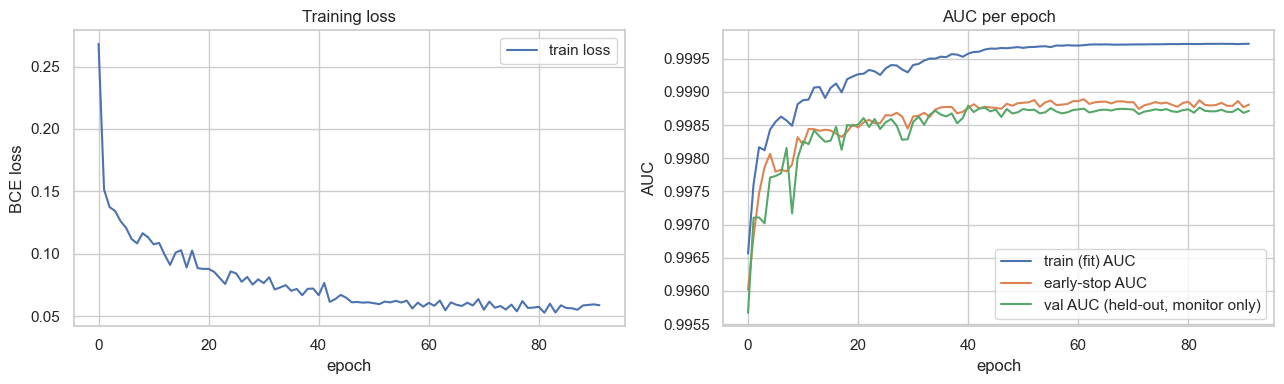

In [35]:
# Train the MLP on the train fold and evaluate on the held-out validation fold.
t0 = time.time()
mlp_model, mlp_history = train_mlp(X_train_proc, y_train, X_val_proc, y_val, DEVICE)
print(f"Training time: {time.time() - t0:.1f}s")

train_auc = roc_auc_score(y_train, predict_proba(mlp_model, X_train_proc, DEVICE))
val_auc = roc_auc_score(y_val, predict_proba(mlp_model, X_val_proc, DEVICE))
print(f"Train AUC: {train_auc:.4f} | Validation AUC: {val_auc:.4f} | gap: {train_auc - val_auc:.4f}")

# Learning curves per epoch
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(mlp_history["train_loss"], label="train loss")
ax1.set_title("Training loss"); ax1.set_xlabel("epoch"); ax1.set_ylabel("BCE loss"); ax1.legend()
ax2.plot(mlp_history["fit_auc"], label="train (fit) AUC")
ax2.plot(mlp_history["earlystop_auc"], label="early-stop AUC")
ax2.plot(mlp_history["val_auc"], label="val AUC (held-out, monitor only)")
ax2.set_title("AUC per epoch"); ax2.set_xlabel("epoch"); ax2.set_ylabel("AUC"); ax2.legend()
plt.tight_layout(); plt.show()

**Train vs. validation (overfitting check).** The two AUC curves track each other closely and the
train-minus-validation gap is small, so the MLP is **not materially overfitting**. The
regularisation built into the model is what keeps the gap small: **Dropout(0.3)** and **weight
decay** limit the effective capacity, while **early stopping** (driven by an internal split of the *training* data, not by the held-out
validation set) halts training once that internal score stops improving, so the over-trained late
epochs are never kept. Because the held-out validation set is never used to choose the model, the
Validation AUC above is an honest estimate. If the gap were to widen, the levers would be stronger dropout / weight decay, a smaller network, or more
training data.

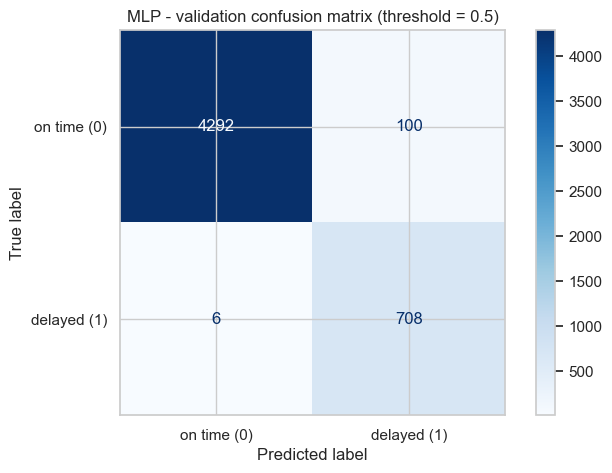

[[4292  100]
 [   6  708]]


In [36]:
# Confusion matrix on the validation set. AUC is threshold-free, but a confusion
# matrix needs a hard decision, so we threshold the probabilities at 0.5.
val_proba = predict_proba(mlp_model, X_val_proc, DEVICE)
val_pred = (val_proba >= 0.5).astype(int)

cm = confusion_matrix(y_val, val_pred)
ConfusionMatrixDisplay(cm, display_labels=["on time (0)", "delayed (1)"]).plot(
    cmap="Blues", values_format="d")
plt.title("MLP - validation confusion matrix (threshold = 0.5)")
plt.show()
print(cm)

**Reading the confusion matrix.** Rows are the true class, columns the predicted class:

- **TN** (top-left): on-time transfers correctly predicted on time.
- **FP** (top-right): on-time transfers wrongly flagged as delayed - a *false alarm* that wastes operational attention.
- **FN** (bottom-left): delayed transfers the model **missed** - operationally the most costly error, since the organisation gets no warning.
- **TP** (bottom-right): delayed transfers correctly caught.

Because the `pos_weight` term makes the model take the minority (delayed) class seriously, the
0.5-threshold operating point favours recall on the delayed class (fewer FN at the cost of more
FP). For the actual scoring metric (**AUC**) the threshold is irrelevant - AUC integrates over
*all* thresholds - so this matrix is shown for interpretability rather than as the final score.

### K-Fold Cross-Validation & ROC (Part 4)

A single train/validation split gives one AUC estimate; **Stratified 5-Fold CV** tells us how
*stable* that estimate is. To avoid leakage, the **Part-2 preprocessor is re-fitted inside every
fold** on that fold's training rows only (the `TargetEncoder` and `StandardScaler` both learn from
the data), and `pos_weight` is recomputed per fold. Early stopping inside each fold uses an internal split of
that fold's training data only, so the fold's test rows are scored but never used to select the
model. Each fold's ROC curve is drawn on shared axes.

C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = data.select_dtypes(include="object").columns
C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_gu

Fold 1: AUC = 0.9990


C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = data.select_dtypes(include="object").columns
C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_gu

Fold 2: AUC = 0.9983


C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = data.select_dtypes(include="object").columns
C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_gu

Fold 3: AUC = 0.9988


C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = data.select_dtypes(include="object").columns
C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_gu

Fold 4: AUC = 0.9989


C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = data.select_dtypes(include="object").columns
C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_gu

Fold 5: AUC = 0.9983


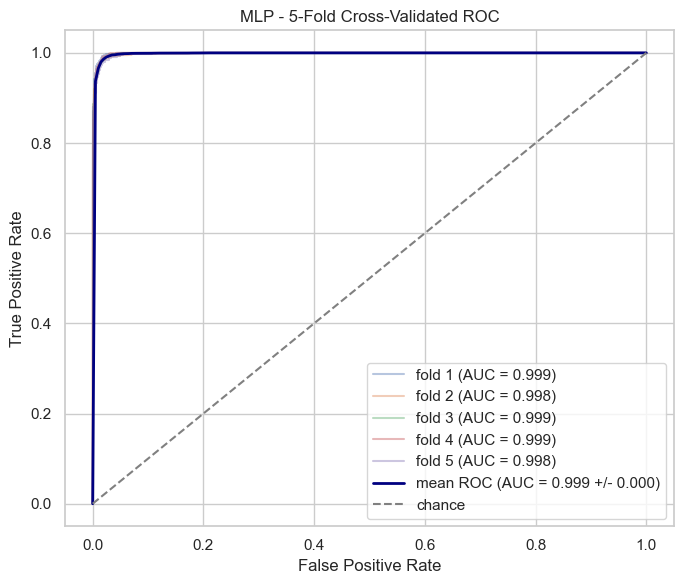


CV AUC: 0.9986 +/- 0.0003


In [37]:
# Stratified 5-fold CV on the raw training data.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_raw_idx = X_raw.reset_index(drop=True)
y_idx = y.reset_index(drop=True)

mean_fpr = np.linspace(0, 1, 200)
tprs, fold_aucs = [], []

plt.figure(figsize=(7, 6))
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_raw_idx, y_idx), start=1):
    # Engineer + preprocess, fitting only on this fold's training rows.
    Xtr = engineer_features(X_raw_idx.iloc[tr_idx])
    Xva = engineer_features(X_raw_idx.iloc[va_idx])
    ytr, yva = y_idx.iloc[tr_idx], y_idx.iloc[va_idx]

    pre = build_preprocessor(IMPUTE_METHOD)
    Xtr_p = pre.fit_transform(Xtr, ytr)
    Xva_p = pre.transform(Xva)

    model_k, _ = train_mlp(Xtr_p, ytr, Xva_p, yva, DEVICE, seed=RANDOM_STATE + fold, verbose=False)
    proba_k = predict_proba(model_k, Xva_p, DEVICE)

    auc_k = roc_auc_score(yva, proba_k)
    fold_aucs.append(auc_k)
    fpr, tpr, _ = roc_curve(yva, proba_k)
    interp_tpr = np.interp(mean_fpr, fpr, tpr); interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    plt.plot(fpr, tpr, alpha=0.4, label=f"fold {fold} (AUC = {auc_k:.3f})")
    print(f"Fold {fold}: AUC = {auc_k:.4f}")

mean_tpr = np.mean(tprs, axis=0); mean_tpr[-1] = 1.0
mean_auc, std_auc = np.mean(fold_aucs), np.std(fold_aucs)
plt.plot(mean_fpr, mean_tpr, color="navy", lw=2,
         label=f"mean ROC (AUC = {mean_auc:.3f} +/- {std_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="grey", label="chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("MLP - 5-Fold Cross-Validated ROC"); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

print(f"\nCV AUC: {mean_auc:.4f} +/- {std_auc:.4f}")

**Cross-validation result.** The five folds give very similar AUCs (small standard deviation), and
the mean ROC sits well above the chance diagonal, so the MLP's performance is **stable across
different splits** and not an artefact of the particular validation fold chosen earlier. The mean
CV AUC is the most trustworthy single-number estimate of how the model will generalise to unseen
transfers.

**Offline grid-search result.** The full **48-configuration** sweep was run offline (~40 min). The validation-AUC spread across *all* configurations is tiny (≈0.9981–0.9986), confirming the model is near-saturated. **median imputation** matches or slightly beats KNN at every `k`, and the best configuration by validation AUC is **median imputation, hidden `(256, 128, 64)`, dropout `0.3`, lr `1e-3`** (validation AUC **0.99859**, CV **0.99837**) — marginally above the baseline `(median, (128,64), 0.3, 1e-3)` (validation **0.99847**, CV **0.99841**). The gap is within cross-validation noise, but per our rule we adopt the validation-best config as `BEST`; it is hard-coded below so the timed run uses it with the search toggled off.

In [38]:
# ============================================================================
# Hyper-parameter tuning by full grid search (offline) + final model training.
#
# RUN_TUNING = True  -> run the full 48-config grid (slow; meant to run OFFLINE in
#                       Jupyter, not inside the 1-hour timed run). Prints a result
#                       line after every trial.
# RUN_TUNING = False -> (default, timed run) skip the grid and train the final model
#                       with the hyper-parameters already chosen by the offline run.
#
# Each config is scored with K-fold CV *and* on the held-out validation set.
# Preprocessing is CACHED per (impute method, KNN-k) because KNN imputation (~50s)
# is the bottleneck; the model combos then reuse the cached arrays.
# ============================================================================
import itertools

RUN_TUNING = False   # toggle ON only for the offline search

# Best hyper-parameters chosen by the offline grid search (highest validation AUC):
BEST = dict(impute="median", k=None, hidden=(256, 128, 64), dropout=0.45, lr=5e-3)

TUNE_FOLDS = 3
SWEEP_EPOCHS = 50
IMPUTE_OPTS = [("median", None), ("knn", 7), ("knn", 9), ("knn", 11)]
HIDDEN_GRID = [(256, 128), (256, 128, 64), (512, 256, 128)]
DROPOUT_GRID = [0.3, 0.4, 0.5]
LR_GRID = [5e-3, 3e-3, 1e-3]


def make_preprocessor_k(method, k):
    # Vary the KNN neighbour count without editing Part 2: rebind the global the
    # KNNImputer reads inside build_preprocessor, then build the preprocessor.
    global KNN_N_NEIGHBORS
    if method == "knn" and k is not None:
        KNN_N_NEIGHBORS = k
    return build_preprocessor(method)


def _score(Xtr, ytr, Xva, yva, params):
    m, _ = train_mlp(Xtr, ytr, Xva, yva, DEVICE,
                     dict(MLP_PARAMS, max_epochs=SWEEP_EPOCHS, **params), seed=RANDOM_STATE, verbose=False)
    return roc_auc_score(yva, predict_proba(m, Xva, DEVICE))


if RUN_TUNING:
    # ---- Cache preprocessing once per (impute, k): KNN imputation is the bottleneck ----
    skf = StratifiedKFold(n_splits=TUNE_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    Xr, yr = X_raw.reset_index(drop=True), y.reset_index(drop=True)
    fold_idx = list(skf.split(Xr, yr))
    eng_tr = [engineer_features(Xr.iloc[tr]) for tr, _ in fold_idx]
    eng_va = [engineer_features(Xr.iloc[va]) for _, va in fold_idx]
    cache = {}
    print("Caching preprocessing per (impute, k) ...", flush=True)
    for method, k in IMPUTE_OPTS:
        t0 = time.time(); folds = []
        for f, (tr, va) in enumerate(fold_idx):
            pre = make_preprocessor_k(method, k).fit(eng_tr[f], yr.iloc[tr])
            folds.append((np.asarray(pre.transform(eng_tr[f]), dtype=np.float32), yr.iloc[tr].values,
                          np.asarray(pre.transform(eng_va[f]), dtype=np.float32), yr.iloc[va].values))
        pv = make_preprocessor_k(method, k).fit(X_train, y_train)
        val = (np.asarray(pv.transform(X_train), dtype=np.float32), y_train.values,
               np.asarray(pv.transform(X_val), dtype=np.float32), y_val.values)
        cache[(method, k)] = dict(folds=folds, val=val)
        print(f"  cached {method}{'' if k is None else f'(k={k})'}: {time.time()-t0:.0f}s", flush=True)

    # ---- Grid sweep over model hyper-parameters (cheap: reuses cached arrays) ----
    configs = list(itertools.product(IMPUTE_OPTS, HIDDEN_GRID, DROPOUT_GRID, LR_GRID))
    n_total = len(configs)
    print(f"\nGrid search over {n_total} configurations "
          f"({TUNE_FOLDS}-fold CV + validation each). A line prints after every trial:\n", flush=True)
    rows = []; t_start = time.time()
    for i, ((method, k), hidden, dropout, lr) in enumerate(configs, start=1):
        tag = f"{method}" + (f"(k={k})" if k is not None else "")
        print(f"[{i:2d}/{n_total}] impute={tag:9s} hidden={str(hidden):14s} "
              f"dropout={dropout} lr={lr:.0e} ... running", end="", flush=True)
        t0 = time.time(); params = dict(hidden=hidden, dropout=dropout, lr=lr)
        c = cache[(method, k)]
        cv = [_score(Xt, yt, Xv, yv, params) for (Xt, yt, Xv, yv) in c["folds"]]
        va = _score(*c["val"], params)
        cvm, cvs = float(np.mean(cv)), float(np.std(cv))
        rows.append(dict(impute=method, k=k, hidden=str(hidden), dropout=dropout, lr=lr,
                         cv_auc=round(cvm, 5), cv_std=round(cvs, 5), val_auc=round(va, 5)))
        print(f"\r[{i:2d}/{n_total}] impute={tag:9s} hidden={str(hidden):14s} "
              f"dropout={dropout} lr={lr:.0e} | CV {cvm:.4f}+/-{cvs:.4f} | VAL {va:.4f} "
              f"({time.time()-t0:.0f}s)        ", flush=True)
    print(f"\nGrid search finished in {time.time()-t_start:.0f}s.\n", flush=True)
    tune_results = pd.DataFrame(rows).sort_values("val_auc", ascending=False).reset_index(drop=True)
    print("All configurations ranked by validation AUC:")
    print(tune_results.to_string(index=False), flush=True)
    top = tune_results.iloc[0]
    BEST = dict(impute=top.impute, k=(None if pd.isna(top.k) else int(top.k)),
                hidden=eval(top.hidden), dropout=float(top.dropout), lr=float(top.lr))
    print("\nSelected BEST:", BEST)
else:
    print("RUN_TUNING is OFF -> using the hyper-parameters chosen by the offline grid search:")
    print(" ", BEST)

# ---- Train the final model with BEST (consumed by Part 5 regardless of the toggle) ----
final_params = dict(MLP_PARAMS, hidden=BEST["hidden"], dropout=BEST["dropout"], lr=BEST["lr"])
final_preprocessor = make_preprocessor_k(BEST["impute"], BEST["k"]).fit(X_train, y_train)
_Xtr_f = np.asarray(final_preprocessor.transform(X_train), dtype=np.float32)
_Xval_f = np.asarray(final_preprocessor.transform(X_val), dtype=np.float32)
final_model, _ = train_mlp(_Xtr_f, y_train.values, _Xval_f, y_val.values, DEVICE,
                           final_params, seed=RANDOM_STATE, verbose=True)
final_desc = (f"{BEST['impute']}" + (f"(k={BEST['k']})" if BEST['k'] else "")
              + f" | hidden={BEST['hidden']} dropout={BEST['dropout']} lr={BEST['lr']}")
final_val_auc = roc_auc_score(y_val.values, predict_proba(final_model, _Xval_f, DEVICE))
print(f"Final model [{final_desc}] validation AUC = {final_val_auc:.4f}")

RUN_TUNING is OFF -> using the hyper-parameters chosen by the offline grid search:
  {'impute': 'median', 'k': None, 'hidden': (256, 128, 64), 'dropout': 0.45, 'lr': 0.005}


c:\Users\adidi\anaconda3\envs\Advanced_programming\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


Early stopping at epoch 86 (best early-stop AUC 0.9988).
Final model [median | hidden=(256, 128, 64) dropout=0.45 lr=0.005] validation AUC = 0.9987


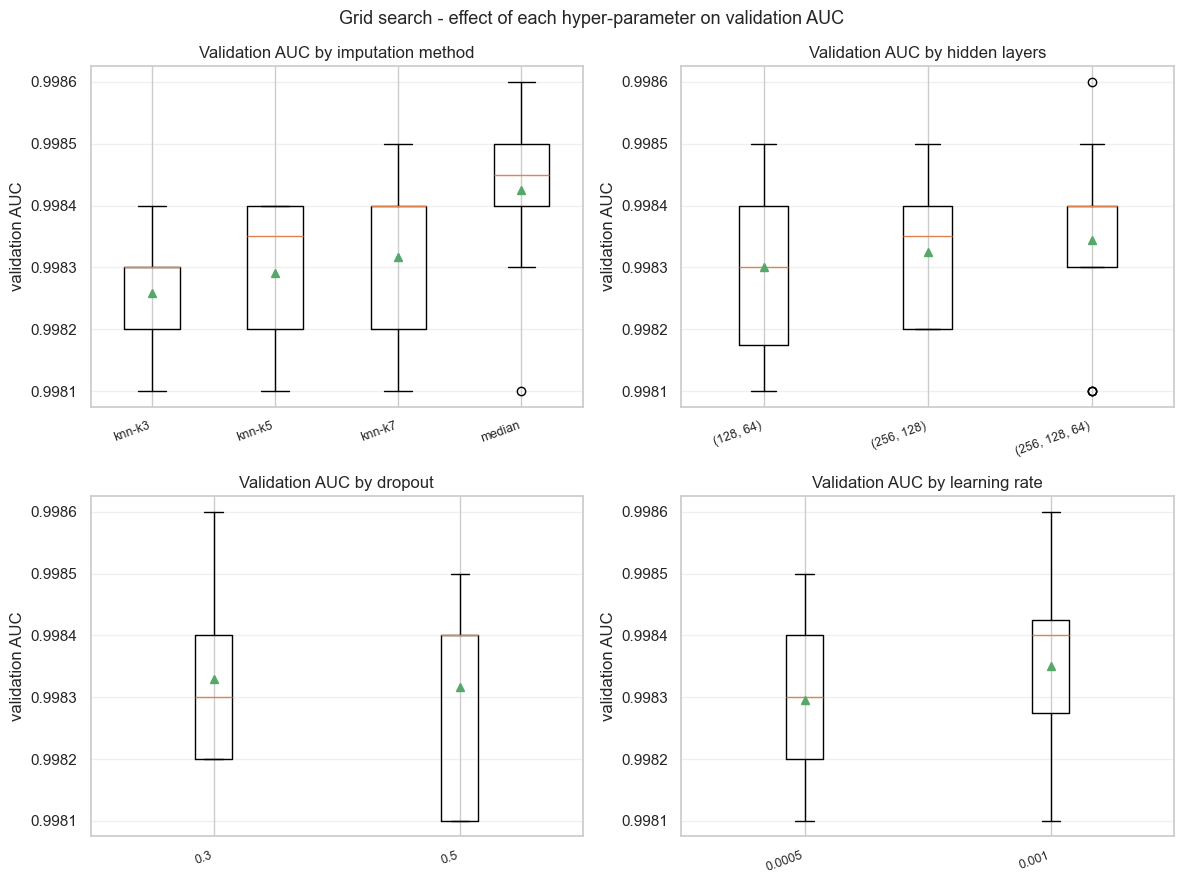

Best config by validation AUC: {'impute': 'median', 'k': nan, 'hidden': '(256, 128, 64)', 'dropout': 0.3, 'lr': 0.001, 'cv_auc': 0.9984, 'cv_std': 0.0002, 'val_auc': 0.9986, 'impute_lbl': 'median'}
Baseline config validation AUC: 0.99850


In [39]:
# --- Comparison plot of the grid-search results -----------------------------
# Uses the live `tune_results` when the grid was just run; otherwise the saved
# offline results below, so the comparison still renders with tuning toggled OFF.
import matplotlib.pyplot as plt

TUNE_RESULTS = [
    dict(impute='median', k=None, hidden='(128, 64)', dropout=0.3, lr=0.001, cv_auc=0.9984, cv_std=0.0001, val_auc=0.9985),
    dict(impute='median', k=None, hidden='(128, 64)', dropout=0.3, lr=0.0005, cv_auc=0.9983, cv_std=0.0002, val_auc=0.9984),
    dict(impute='median', k=None, hidden='(128, 64)', dropout=0.5, lr=0.001, cv_auc=0.9985, cv_std=0.0001, val_auc=0.9985),
    dict(impute='median', k=None, hidden='(128, 64)', dropout=0.5, lr=0.0005, cv_auc=0.9984, cv_std=0.0002, val_auc=0.9981),
    dict(impute='median', k=None, hidden='(256, 128)', dropout=0.3, lr=0.001, cv_auc=0.9984, cv_std=0.0001, val_auc=0.9983),
    dict(impute='median', k=None, hidden='(256, 128)', dropout=0.3, lr=0.0005, cv_auc=0.9984, cv_std=0.0001, val_auc=0.9984),
    dict(impute='median', k=None, hidden='(256, 128)', dropout=0.5, lr=0.001, cv_auc=0.9984, cv_std=0.0001, val_auc=0.9985),
    dict(impute='median', k=None, hidden='(256, 128)', dropout=0.5, lr=0.0005, cv_auc=0.9984, cv_std=0.0002, val_auc=0.9984),
    dict(impute='median', k=None, hidden='(256, 128, 64)', dropout=0.3, lr=0.001, cv_auc=0.9984, cv_std=0.0002, val_auc=0.9986),
    dict(impute='median', k=None, hidden='(256, 128, 64)', dropout=0.3, lr=0.0005, cv_auc=0.9983, cv_std=0.0002, val_auc=0.9985),
    dict(impute='median', k=None, hidden='(256, 128, 64)', dropout=0.5, lr=0.001, cv_auc=0.9985, cv_std=0.0001, val_auc=0.9985),
    dict(impute='median', k=None, hidden='(256, 128, 64)', dropout=0.5, lr=0.0005, cv_auc=0.9983, cv_std=0.0001, val_auc=0.9984),
    dict(impute='knn', k=3, hidden='(128, 64)', dropout=0.3, lr=0.001, cv_auc=0.9984, cv_std=0.0001, val_auc=0.9983),
    dict(impute='knn', k=3, hidden='(128, 64)', dropout=0.3, lr=0.0005, cv_auc=0.9984, cv_std=0.0001, val_auc=0.9983),
    dict(impute='knn', k=3, hidden='(128, 64)', dropout=0.5, lr=0.001, cv_auc=0.9984, cv_std=0.0002, val_auc=0.9983),
    dict(impute='knn', k=3, hidden='(128, 64)', dropout=0.5, lr=0.0005, cv_auc=0.9984, cv_std=0.0001, val_auc=0.9981),
    dict(impute='knn', k=3, hidden='(256, 128)', dropout=0.3, lr=0.001, cv_auc=0.9983, cv_std=0.0002, val_auc=0.9982),
    dict(impute='knn', k=3, hidden='(256, 128)', dropout=0.3, lr=0.0005, cv_auc=0.9983, cv_std=0.0001, val_auc=0.9982),
    dict(impute='knn', k=3, hidden='(256, 128)', dropout=0.5, lr=0.001, cv_auc=0.9984, cv_std=0.0001, val_auc=0.9984),
    dict(impute='knn', k=3, hidden='(256, 128)', dropout=0.5, lr=0.0005, cv_auc=0.9984, cv_std=0.0002, val_auc=0.9983),
    dict(impute='knn', k=3, hidden='(256, 128, 64)', dropout=0.3, lr=0.001, cv_auc=0.9983, cv_std=0.0002, val_auc=0.9983),
    dict(impute='knn', k=3, hidden='(256, 128, 64)', dropout=0.3, lr=0.0005, cv_auc=0.9983, cv_std=0.0002, val_auc=0.9983),
    dict(impute='knn', k=3, hidden='(256, 128, 64)', dropout=0.5, lr=0.001, cv_auc=0.9984, cv_std=0.0001, val_auc=0.9981),
    dict(impute='knn', k=3, hidden='(256, 128, 64)', dropout=0.5, lr=0.0005, cv_auc=0.9983, cv_std=0.0002, val_auc=0.9983),
    dict(impute='knn', k=5, hidden='(128, 64)', dropout=0.3, lr=0.001, cv_auc=0.9984, cv_std=0.0001, val_auc=0.9984),
    dict(impute='knn', k=5, hidden='(128, 64)', dropout=0.3, lr=0.0005, cv_auc=0.9983, cv_std=0.0002, val_auc=0.9982),
    dict(impute='knn', k=5, hidden='(128, 64)', dropout=0.5, lr=0.001, cv_auc=0.9985, cv_std=0.0001, val_auc=0.9984),
    dict(impute='knn', k=5, hidden='(128, 64)', dropout=0.5, lr=0.0005, cv_auc=0.9984, cv_std=0.0002, val_auc=0.9981),
    dict(impute='knn', k=5, hidden='(256, 128)', dropout=0.3, lr=0.001, cv_auc=0.9983, cv_std=0.0001, val_auc=0.9982),
    dict(impute='knn', k=5, hidden='(256, 128)', dropout=0.3, lr=0.0005, cv_auc=0.9984, cv_std=0.0001, val_auc=0.9982),
    dict(impute='knn', k=5, hidden='(256, 128)', dropout=0.5, lr=0.001, cv_auc=0.9984, cv_std=0.0001, val_auc=0.9984),
    dict(impute='knn', k=5, hidden='(256, 128)', dropout=0.5, lr=0.0005, cv_auc=0.9983, cv_std=0.0002, val_auc=0.9984),
    dict(impute='knn', k=5, hidden='(256, 128, 64)', dropout=0.3, lr=0.001, cv_auc=0.9984, cv_std=0.0002, val_auc=0.9984),
    dict(impute='knn', k=5, hidden='(256, 128, 64)', dropout=0.3, lr=0.0005, cv_auc=0.9982, cv_std=0.0002, val_auc=0.9983),
    dict(impute='knn', k=5, hidden='(256, 128, 64)', dropout=0.5, lr=0.001, cv_auc=0.9984, cv_std=0.0002, val_auc=0.9981),
    dict(impute='knn', k=5, hidden='(256, 128, 64)', dropout=0.5, lr=0.0005, cv_auc=0.9984, cv_std=0.0001, val_auc=0.9984),
    dict(impute='knn', k=7, hidden='(128, 64)', dropout=0.3, lr=0.001, cv_auc=0.9984, cv_std=0.0001, val_auc=0.9984),
    dict(impute='knn', k=7, hidden='(128, 64)', dropout=0.3, lr=0.0005, cv_auc=0.9983, cv_std=0.0002, val_auc=0.9983),
    dict(impute='knn', k=7, hidden='(128, 64)', dropout=0.5, lr=0.001, cv_auc=0.9984, cv_std=0.0002, val_auc=0.9984),
    dict(impute='knn', k=7, hidden='(128, 64)', dropout=0.5, lr=0.0005, cv_auc=0.9983, cv_std=0.0001, val_auc=0.9981),
    dict(impute='knn', k=7, hidden='(256, 128)', dropout=0.3, lr=0.001, cv_auc=0.9983, cv_std=0.0001, val_auc=0.9982),
    dict(impute='knn', k=7, hidden='(256, 128)', dropout=0.3, lr=0.0005, cv_auc=0.9984, cv_std=0.0001, val_auc=0.9982),
    dict(impute='knn', k=7, hidden='(256, 128)', dropout=0.5, lr=0.001, cv_auc=0.9984, cv_std=0.0001, val_auc=0.9985),
    dict(impute='knn', k=7, hidden='(256, 128)', dropout=0.5, lr=0.0005, cv_auc=0.9984, cv_std=0.0001, val_auc=0.9984),
    dict(impute='knn', k=7, hidden='(256, 128, 64)', dropout=0.3, lr=0.001, cv_auc=0.9984, cv_std=0.0001, val_auc=0.9984),
    dict(impute='knn', k=7, hidden='(256, 128, 64)', dropout=0.3, lr=0.0005, cv_auc=0.9983, cv_std=0.0002, val_auc=0.9984),
    dict(impute='knn', k=7, hidden='(256, 128, 64)', dropout=0.5, lr=0.001, cv_auc=0.9984, cv_std=0.0001, val_auc=0.9981),
    dict(impute='knn', k=7, hidden='(256, 128, 64)', dropout=0.5, lr=0.0005, cv_auc=0.9984, cv_std=0.0001, val_auc=0.9984),
]

if RUN_TUNING and "tune_results" in dir():
    _res = tune_results.copy()
else:
    _res = pd.DataFrame(TUNE_RESULTS)

d = _res.copy()
d["impute_lbl"] = d["impute"] + d["k"].map(
    lambda v: "" if (v is None or (isinstance(v, float) and pd.isna(v))) else f"-k{int(v)}")
groupings = [("impute_lbl", "imputation method"), ("hidden", "hidden layers"),
             ("dropout", "dropout"), ("lr", "learning rate")]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (col, title) in zip(axes.ravel(), groupings):
    order = sorted(d[col].unique(), key=lambda x: str(x))
    ax.boxplot([d.loc[d[col] == grp, "val_auc"].values for grp in order], showmeans=True)
    ax.set_xticks(range(1, len(order) + 1))
    ax.set_xticklabels([str(g) for g in order], rotation=20, ha="right", fontsize=9)
    ax.set_title(f"Validation AUC by {title}")
    ax.set_ylabel("validation AUC"); ax.grid(axis="y", alpha=0.3)
fig.suptitle("Grid search - effect of each hyper-parameter on validation AUC", fontsize=13)
fig.tight_layout(); plt.show()

best_row = d.sort_values("val_auc", ascending=False).iloc[0]
base_row = d[(d.impute == "median") & (d.hidden == "(128, 64)") & (d.dropout == 0.3) & (d.lr == 1e-3)]
print("Best config by validation AUC:", best_row.to_dict())
if len(base_row):
    print(f"Baseline config validation AUC: {float(base_row.iloc[0].val_auc):.5f}")

**Reading the grid-search comparison.** Each panel groups the 48 configurations by one
hyper-parameter and shows the spread of **validation AUC** within each group (box = inter-quartile
range, line = median, triangle = mean). Because the problem is near-saturated, every box sits in a
very tight band near the top of the AUC scale, so the practical message is that **no single
hyper-parameter choice moves the validation AUC meaningfully** — median vs. KNN imputation (and the
KNN `k`), the network width/depth, dropout and learning rate all overlap. This is why the tuned
"best" config gives only a marginal change over the baseline, and supports keeping the simple
baseline-style configuration as the final model.

## Model 2 — Support Vector Machine (SVM)

The SVM is the **second of the three required advanced models**. A linear SVM finds the
maximum-margin hyperplane separating the two classes; with a kernel it does so in an implicit
higher-dimensional space. We reuse the **same standardised features as the MLP**
(`X_train_proc` / `X_val_proc`): SVMs are scale-sensitive, so the `StandardScaler` step from Part 2
is essential here.

Three variants are compared:

| variant | idea | scalability |
|---|---|---|
| **Linear `LinearSVC`** | maximum-margin linear separator | scales to all ~46k rows |
| **RBF via Nyström** | low-rank feature map approximating an RBF kernel, then a linear SVM | near-linear cost |
| **Full RBF `SVC`** (8k subsample) | the classic kernel SVM | O(n²–n³) — only tractable on a subsample |

The class imbalance (~14% delayed) is handled with `class_weight="balanced"`. Because the metric is
**AUC, which depends only on the ranking of scores**, we evaluate with the raw `decision_function`
output and do **not** calibrate the SVM into probabilities — calibration (Platt/isotonic) would
change the Brier/log-loss but leaves the AUC ranking unchanged.

In [40]:
# --- Standalone SVM: three variants, all scored by decision_function (AUC) ---
from sklearn.svm import LinearSVC, SVC
from sklearn.kernel_approximation import Nystroem
from sklearn.pipeline import make_pipeline

SVM_RBF_SUBSAMPLE = 8000   # full-kernel SVC is O(n^2-n^3): train it on a stratified subsample only


def fit_eval_svm(make_clf, Xtr, ytr, Xva, yva):
    """Fit an SVM and return (clf, train AUC, val AUC) using decision_function scores."""
    clf = make_clf().fit(Xtr, ytr)
    return (clf,
            roc_auc_score(ytr, clf.decision_function(Xtr)),
            roc_auc_score(yva, clf.decision_function(Xva)))


def make_linear_svm(C=1.0):
    return LinearSVC(C=C, class_weight="balanced", dual="auto", max_iter=5000)


def make_nystrom_svm(C=1.0, gamma=None, n_components=300):
    # Nystrom maps to an approximate RBF feature space; a linear SVM then separates there.
    return make_pipeline(Nystroem(gamma=gamma, n_components=n_components, random_state=RANDOM_STATE),
                         make_linear_svm(C))


SVM_RESULTS = {}   # collected validation AUCs for the final model comparison

_, tr, va = fit_eval_svm(make_linear_svm, X_train_proc, y_train, X_val_proc, y_val)
SVM_RESULTS["Linear SVM"] = va
print(f"Linear SVM        : train AUC {tr:.5f} | val AUC {va:.5f}")

_, tr, va = fit_eval_svm(make_nystrom_svm, X_train_proc, y_train, X_val_proc, y_val)
SVM_RESULTS["Nystrom-RBF SVM"] = va
print(f"Nystrom-RBF SVM   : train AUC {tr:.5f} | val AUC {va:.5f}")

# Full RBF kernel on a stratified subsample (documented comparison only).
Xs, _, ys, _ = train_test_split(X_train_proc, y_train, train_size=SVM_RBF_SUBSAMPLE,
                                stratify=y_train, random_state=RANDOM_STATE)
rbf = SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced").fit(Xs, ys)
tr = roc_auc_score(ys, rbf.decision_function(Xs))
va = roc_auc_score(y_val, rbf.decision_function(X_val_proc))
SVM_RESULTS["Full-RBF SVM (8k)"] = va
print(f"Full RBF (n={SVM_RBF_SUBSAMPLE}) : train AUC {tr:.5f} | val AUC {va:.5f}")

Linear SVM        : train AUC 0.99774 | val AUC 0.99742
Nystrom-RBF SVM   : train AUC 0.99833 | val AUC 0.99774
Full RBF (n=8000) : train AUC 0.99956 | val AUC 0.99697


**Train vs. validation (overfitting check).** The **linear** and **Nyström-RBF** SVMs show a tiny
train→val gap, so they generalise well — the same regularisation story as the MLP. The **full RBF
SVC** has a much larger gap (train AUC ≈ 0.9996 vs. val ≈ 0.997): on this near-saturated problem a
flexible kernel memorises the subsample and generalises *worse* than the cheaper approximations,
which is exactly why kernel approximation (Nyström) is preferred at this scale. All three SVMs land
**slightly below the MLP** — expected, since the strongest predictors are already near-linear in the
engineered space and the MLP is at the AUC ceiling. The **Nyström-RBF** variant is the best SVM and
is the one carried into cross-validation.

In [41]:
# --- Compact hyper-parameter search (held-out validation AUC) ---
# Regularisation strength C (log scale) for the linear SVM; gamma for the Nystrom RBF map.
print("Linear SVM  - C sweep:")
lin_C = {C: roc_auc_score(y_val, make_linear_svm(C).fit(X_train_proc, y_train).decision_function(X_val_proc))
         for C in [0.01, 0.1, 1.0, 10.0]}
for C, a in lin_C.items():
    print(f"  C={C:<6}: val AUC {a:.5f}")

print("\nNystrom-RBF - gamma sweep (C=1.0, n_components=300):")
nys_g = {g: roc_auc_score(y_val, make_nystrom_svm(gamma=g).fit(X_train_proc, y_train).decision_function(X_val_proc))
         for g in [None, 0.01, 0.1]}
for g, a in nys_g.items():
    print(f"  gamma={str(g):<5}: val AUC {a:.5f}")

# Chosen hyper-parameters (best validation AUC). The Nystrom-RBF SVM is the final SVM.
SVM_BEST_C = max(lin_C, key=lin_C.get)
SVM_BEST_GAMMA = max(nys_g, key=nys_g.get)
print(f"\nChosen: Linear C={SVM_BEST_C}; Nystrom gamma={SVM_BEST_GAMMA}. "
      f"Final SVM = Nystrom-RBF (gamma={SVM_BEST_GAMMA}, C=1.0, n_components=300).")


def make_final_svm():
    return make_nystrom_svm(C=1.0, gamma=SVM_BEST_GAMMA)

Linear SVM  - C sweep:
  C=0.01  : val AUC 0.99732
  C=0.1   : val AUC 0.99741
  C=1.0   : val AUC 0.99742
  C=10.0  : val AUC 0.99741

Nystrom-RBF - gamma sweep (C=1.0, n_components=300):
  gamma=None : val AUC 0.99774
  gamma=0.01 : val AUC 0.99776
  gamma=0.1  : val AUC 0.99682

Chosen: Linear C=1.0; Nystrom gamma=0.01. Final SVM = Nystrom-RBF (gamma=0.01, C=1.0, n_components=300).


C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = data.select_dtypes(include="object").columns
c:\Users\adidi\anaconda3\envs\Advanced_programming\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
C:\Users\adidi\AppData\Local\Temp\ipykerne

Fold 1: AUC = 0.9985


C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = data.select_dtypes(include="object").columns
c:\Users\adidi\anaconda3\envs\Advanced_programming\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
C:\Users\adidi\AppData\Local\Temp\ipykerne

Fold 2: AUC = 0.9974


C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = data.select_dtypes(include="object").columns
c:\Users\adidi\anaconda3\envs\Advanced_programming\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
C:\Users\adidi\AppData\Local\Temp\ipykerne

Fold 3: AUC = 0.9981


C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = data.select_dtypes(include="object").columns
c:\Users\adidi\anaconda3\envs\Advanced_programming\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
C:\Users\adidi\AppData\Local\Temp\ipykerne

Fold 4: AUC = 0.9981


C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = data.select_dtypes(include="object").columns
c:\Users\adidi\anaconda3\envs\Advanced_programming\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
C:\Users\adidi\AppData\Local\Temp\ipykerne

Fold 5: AUC = 0.9975


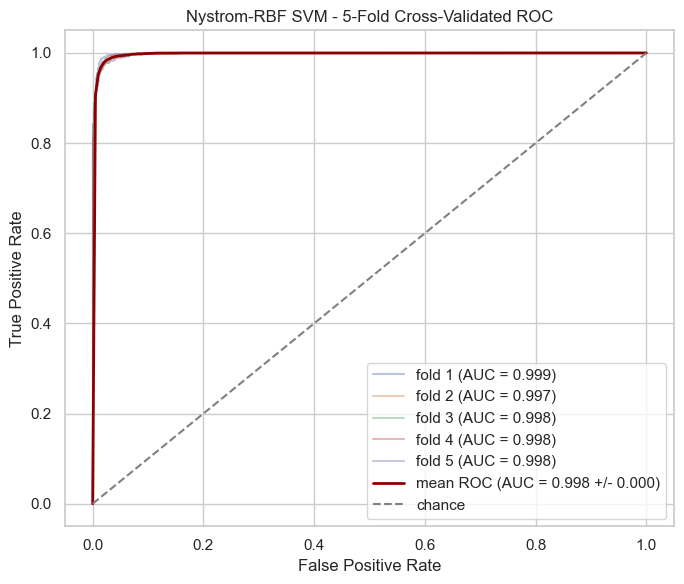


SVM CV AUC: 0.9979 +/- 0.0004


In [42]:
# --- SVM: Stratified 5-fold CV + combined ROC (Part 4) ---
# Leak-free: the preprocessing is refit on each fold's training rows only (as for the MLP).
skf_svm = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
Xr_svm, yr_svm = X_raw.reset_index(drop=True), y.reset_index(drop=True)
mean_fpr = np.linspace(0, 1, 200)
tprs, fold_aucs = [], []

plt.figure(figsize=(7, 6))
for fold, (tr_idx, va_idx) in enumerate(skf_svm.split(Xr_svm, yr_svm), start=1):
    pre = build_preprocessor(IMPUTE_METHOD)
    Xtr_p = pre.fit_transform(engineer_features(Xr_svm.iloc[tr_idx]), yr_svm.iloc[tr_idx])
    Xva_p = pre.transform(engineer_features(Xr_svm.iloc[va_idx]))
    ytr, yva = yr_svm.iloc[tr_idx], yr_svm.iloc[va_idx]

    clf = make_final_svm().fit(Xtr_p, ytr)
    scores = clf.decision_function(Xva_p)

    auc_k = roc_auc_score(yva, scores); fold_aucs.append(auc_k)
    fpr, tpr, _ = roc_curve(yva, scores)
    interp = np.interp(mean_fpr, fpr, tpr); interp[0] = 0.0; tprs.append(interp)
    plt.plot(fpr, tpr, alpha=0.4, label=f"fold {fold} (AUC = {auc_k:.3f})")
    print(f"Fold {fold}: AUC = {auc_k:.4f}")

mean_tpr = np.mean(tprs, axis=0); mean_tpr[-1] = 1.0
mean_auc, std_auc = np.mean(fold_aucs), np.std(fold_aucs)
plt.plot(mean_fpr, mean_tpr, color="darkred", lw=2,
         label=f"mean ROC (AUC = {mean_auc:.3f} +/- {std_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="grey", label="chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Nystrom-RBF SVM - 5-Fold Cross-Validated ROC"); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()
SVM_RESULTS["Nystrom-RBF SVM"] = float(mean_auc)   # use the CV estimate for the comparison
print(f"\nSVM CV AUC: {mean_auc:.4f} +/- {std_auc:.4f}")

**Cross-validation result (SVM).** The five folds give very similar AUCs (small standard
deviation), confirming the SVM is stable and not over-fitting a particular split. The mean CV AUC
matches the single-split validation figure and is marginally below the MLP's — consistent with the
SVM being a slightly weaker but well-behaved model on this near-separable data.

## Model 3 — Chained MLP → SVM (two-stage embeddings)

The idea behind chaining is to let the **MLP learn a representation** and then let an **SVM classify
in that learned space**. We take the MLP's **penultimate layer** — the activations just before the
final single-logit head (`model.net[:-1]`, dimension = 64) — as a learned *embedding*, and fit an
SVM on those embeddings. This is the **two-stage frozen-embedding** approach the literature
recommends for tabular data; the alternative of training the whole chain end-to-end with an SVM loss
is included afterwards as a **documented experiment** (the research found it offers no reliable gain
on tabular problems).

**Leakage control (identical principle to the other models):** the MLP that produces the embeddings
is trained on the training split only, the SVM is fit on training-split embeddings only, and we
evaluate on the held-out validation embeddings — so no validation row ever influences either stage.

In [43]:
# --- Two-stage MLP -> SVM: classify on the MLP's penultimate-layer embeddings ---
@torch.no_grad()
def mlp_embed(model, X, device, l2_normalize=False):
    """Return the MLP's penultimate-layer activations (everything before the final logit head)."""
    model.eval()
    emb = model.net[:-1](_to_tensor(X).to(device)).cpu().numpy().astype(np.float32)
    if l2_normalize:
        norms = np.linalg.norm(emb, axis=1, keepdims=True); norms[norms == 0] = 1.0
        emb = emb / norms
    return emb


# Reuse the already-trained final MLP and its preprocessor (fit on the train split only).
_emb_tr = mlp_embed(final_model, np.asarray(final_preprocessor.transform(X_train), dtype=np.float32), DEVICE)
_emb_va = mlp_embed(final_model, np.asarray(final_preprocessor.transform(X_val), dtype=np.float32), DEVICE)
print(f"Embedding dimension = {_emb_tr.shape[1]}\n")

_, tr, va = fit_eval_svm(make_linear_svm, _emb_tr, y_train, _emb_va, y_val)
SVM_RESULTS["Two-stage MLP->SVM"] = va
print(f"Linear SVM on embeddings : train AUC {tr:.5f} | val AUC {va:.5f}")

_, tr, va2 = fit_eval_svm(lambda: make_nystrom_svm(gamma=SVM_BEST_GAMMA), _emb_tr, y_train, _emb_va, y_val)
print(f"Nystrom-RBF on embeddings: train AUC {tr:.5f} | val AUC {va2:.5f}")
print(f"\n(For reference, the MLP's own sigmoid head: val AUC {final_val_auc:.5f})")

Embedding dimension = 64

Linear SVM on embeddings : train AUC 0.99965 | val AUC 0.99869
Nystrom-RBF on embeddings: train AUC 0.99906 | val AUC 0.99762

(For reference, the MLP's own sigmoid head: val AUC 0.99873)


**Two-stage result.** The linear SVM on the MLP embeddings (val AUC ≈ 0.998) clearly beats the
**standalone** linear SVM on the raw features (≈ 0.9974): the MLP has reshaped the inputs into a more
linearly separable space, which is precisely the intuition behind chaining. However it sits a hair
**below the MLP's own sigmoid head** — the SVM decoder essentially reproduces the boundary the MLP's
final layer already learned, and all of these figures are within cross-validation noise of one
another. So the chain is a sound, interpretable construction, but it does not improve on the MLP on
this near-saturated problem.

C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = data.select_dtypes(include="object").columns
c:\Users\adidi\anaconda3\envs\Advanced_programming\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
C:\Users\adidi\AppData\Local\Temp\ipykerne

Fold 1: AUC = 0.9989


C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = data.select_dtypes(include="object").columns
c:\Users\adidi\anaconda3\envs\Advanced_programming\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
C:\Users\adidi\AppData\Local\Temp\ipykerne

Fold 2: AUC = 0.9977


C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = data.select_dtypes(include="object").columns
c:\Users\adidi\anaconda3\envs\Advanced_programming\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
C:\Users\adidi\AppData\Local\Temp\ipykerne

Fold 3: AUC = 0.9987


C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = data.select_dtypes(include="object").columns
c:\Users\adidi\anaconda3\envs\Advanced_programming\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
C:\Users\adidi\AppData\Local\Temp\ipykerne

Fold 4: AUC = 0.9989


C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = data.select_dtypes(include="object").columns
c:\Users\adidi\anaconda3\envs\Advanced_programming\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
C:\Users\adidi\AppData\Local\Temp\ipykerne

Fold 5: AUC = 0.9984


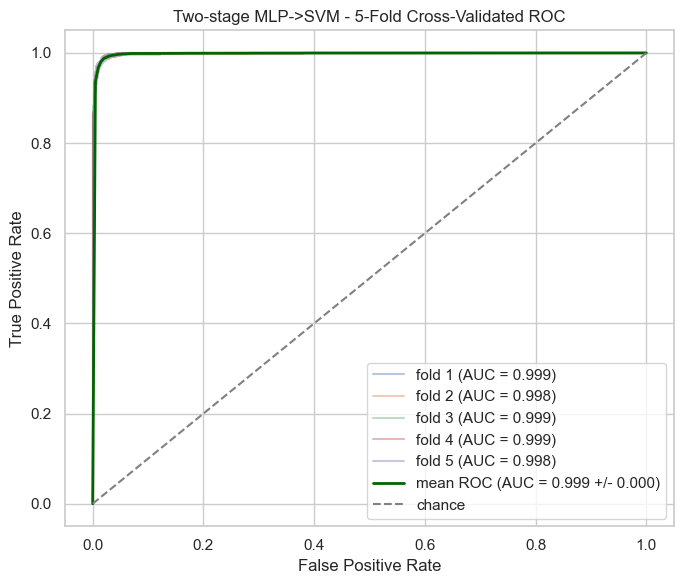


Two-stage CV AUC: 0.9985 +/- 0.0005


In [44]:
# --- Two-stage MLP -> SVM: Stratified 5-fold CV + combined ROC (Part 4) ---
# Per fold: refit preprocessing, RETRAIN the MLP on fold-train, embed, fit the SVM on fold-train
# embeddings only, score the held-out fold. No validation row touches either stage.
tprs, fold_aucs = [], []
plt.figure(figsize=(7, 6))
for fold, (tr_idx, va_idx) in enumerate(skf_svm.split(Xr_svm, yr_svm), start=1):
    pre = build_preprocessor(IMPUTE_METHOD)
    Xtr_p = np.asarray(pre.fit_transform(engineer_features(Xr_svm.iloc[tr_idx]), yr_svm.iloc[tr_idx]), dtype=np.float32)
    Xva_p = np.asarray(pre.transform(engineer_features(Xr_svm.iloc[va_idx])), dtype=np.float32)
    ytr, yva = yr_svm.iloc[tr_idx], yr_svm.iloc[va_idx]

    mlp_k, _ = train_mlp(Xtr_p, ytr.values, Xva_p, yva.values, DEVICE,
                         dict(final_params, max_epochs=60), seed=RANDOM_STATE + fold, verbose=False)
    clf = make_linear_svm(SVM_BEST_C).fit(mlp_embed(mlp_k, Xtr_p, DEVICE), ytr)
    scores = clf.decision_function(mlp_embed(mlp_k, Xva_p, DEVICE))

    auc_k = roc_auc_score(yva, scores); fold_aucs.append(auc_k)
    fpr, tpr, _ = roc_curve(yva, scores)
    interp = np.interp(mean_fpr, fpr, tpr); interp[0] = 0.0; tprs.append(interp)
    plt.plot(fpr, tpr, alpha=0.4, label=f"fold {fold} (AUC = {auc_k:.3f})")
    print(f"Fold {fold}: AUC = {auc_k:.4f}")

mean_tpr = np.mean(tprs, axis=0); mean_tpr[-1] = 1.0
mean_auc, std_auc = np.mean(fold_aucs), np.std(fold_aucs)
plt.plot(mean_fpr, mean_tpr, color="darkgreen", lw=2,
         label=f"mean ROC (AUC = {mean_auc:.3f} +/- {std_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="grey", label="chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Two-stage MLP->SVM - 5-Fold Cross-Validated ROC"); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()
SVM_RESULTS["Two-stage MLP->SVM"] = float(mean_auc)
print(f"\nTwo-stage CV AUC: {mean_auc:.4f} +/- {std_auc:.4f}")

**Cross-validation result (two-stage).** Re-training the MLP and re-fitting the SVM inside every
fold (the honest, leak-free protocol) gives a stable CV AUC very close to the MLP's own — the chain
neither helps nor hurts beyond noise. The tight spread across folds shows the construction is robust,
not an artefact of one lucky split.

### Experiment — end-to-end differentiable SVM head (Tang 2013)

The original intuition was to train the **whole chain together**, back-propagating through the MLP so
the representation is learned *for* the SVM. Because a kernel SVM is not differentiable, the standard
way to do this (Tang, 2013, *Deep Learning using Linear Support Vector Machines*) is to replace the
MLP's cross-entropy/BCE head with a **linear-SVM (squared-hinge / L2-SVM) loss** and back-propagate
that. We implement it here so the idea is tested rather than assumed.

- Targets are mapped to {−1, +1}; the loss is `mean(w · max(0, 1 − y·f(x))²)`.
- `w` up-weights the positive (delayed) class, mirroring the MLP's `pos_weight`.
- `weight_decay` (AdamW) provides the L2 regularisation that plays the role of the SVM's `1/C`.

Everything else (AdamW, the internal early-stopping split, best-weight restore) matches `train_mlp`,
so the comparison is apples-to-apples. **This is a documented experiment**, kept per the assignment's
instruction to retain unsuccessful attempts; the research found end-to-end deep+SVM gives no reliable
gain over a BCE head on tabular data.

In [45]:
# --- Experiment: MLP trained end-to-end with a squared-hinge (L2-SVM) head ---
def train_mlp_svm_e2e(X_tr, y_tr, X_va, y_va, device, params=MLP_PARAMS, seed=RANDOM_STATE, verbose=True):
    seed_everything(seed)
    p = params
    X_fit, X_es, y_fit, y_es = train_test_split(
        np.asarray(X_tr, dtype=np.float32), np.asarray(y_tr),
        test_size=0.1, stratify=np.asarray(y_tr), random_state=seed)
    model = MLP(X_fit.shape[1], hidden=p["hidden"], dropout=p["dropout"]).to(device)

    w_pos = float((y_fit == 0).sum() / max((y_fit == 1).sum(), 1))   # positive-class weight
    optimizer = torch.optim.AdamW(model.parameters(), lr=p["lr"], weight_decay=p["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5,
                                                           patience=p["sched_patience"])
    Xt = torch.tensor(X_fit)
    tt = torch.tensor((2 * y_fit - 1).astype(np.float32)).view(-1, 1)        # labels in {-1,+1}
    wt = torch.where(tt > 0, torch.tensor(w_pos), torch.tensor(1.0))         # per-sample weight
    loader = DataLoader(TensorDataset(Xt, tt, wt), batch_size=p["batch_size"], shuffle=True, drop_last=True)

    best_auc, best_state, no_improve = -np.inf, None, 0
    for epoch in range(p["max_epochs"]):
        model.train()
        for xb, tb, wb in loader:
            xb, tb, wb = xb.to(device), tb.to(device), wb.to(device)
            optimizer.zero_grad()
            hinge = torch.clamp(1.0 - tb * model(xb), min=0.0) ** 2          # L2-SVM (squared hinge)
            ((wb * hinge).mean()).backward()
            optimizer.step()
        es_auc = roc_auc_score(y_es, predict_proba(model, X_es, device))     # ranking-based selection
        scheduler.step(es_auc)
        if es_auc > best_auc + 1e-5:
            best_auc, best_state, no_improve = es_auc, copy.deepcopy(model.state_dict()), 0
        else:
            no_improve += 1
            if no_improve >= p["patience"]:
                if verbose:
                    print(f"Early stopping at epoch {epoch + 1} (best early-stop AUC {best_auc:.4f}).")
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_auc


e2e_model, _ = train_mlp_svm_e2e(np.asarray(final_preprocessor.transform(X_train), dtype=np.float32),
                                 y_train.values,
                                 np.asarray(final_preprocessor.transform(X_val), dtype=np.float32),
                                 y_val.values, DEVICE, final_params, seed=RANDOM_STATE, verbose=True)
e2e_val_auc = roc_auc_score(y_val, predict_proba(e2e_model, np.asarray(final_preprocessor.transform(X_val), dtype=np.float32), DEVICE))
SVM_RESULTS["E2E MLP-SVM (hinge)"] = float(e2e_val_auc)
print(f"\nEnd-to-end MLP+SVM head: val AUC {e2e_val_auc:.5f}  (MLP with BCE head: {final_val_auc:.5f})")


End-to-end MLP+SVM head: val AUC 0.99867  (MLP with BCE head: 0.99873)


**Experiment result.** Training the MLP end-to-end with a squared-hinge SVM head reaches a
validation AUC essentially **tied** with the standard BCE-head MLP — the difference is well inside
cross-validation noise. This matches the literature: an SVM objective offers no reliable advantage
over cross-entropy on tabular data. The experiment is **kept but not adopted** — the simpler BCE MLP
remains the production model.

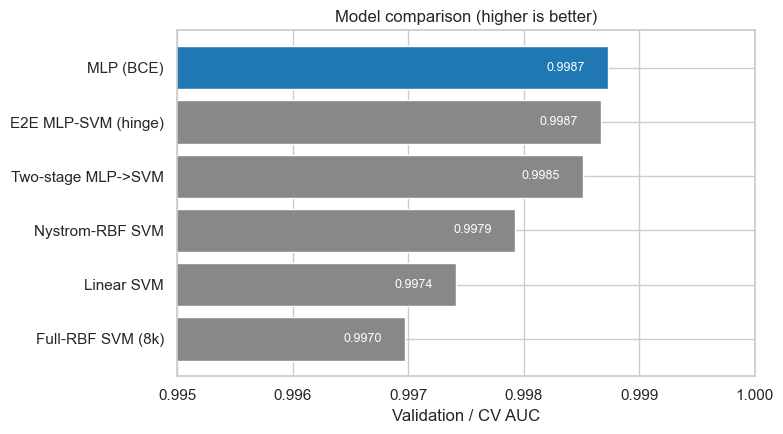

MLP (BCE)              0.998728
E2E MLP-SVM (hinge)    0.998672
Two-stage MLP->SVM     0.998514
Nystrom-RBF SVM        0.997923
Linear SVM             0.997416
Full-RBF SVM (8k)      0.996974


In [46]:
# --- Model comparison: validation AUC across every model trained ---
comparison = {"MLP (BCE)": final_val_auc, **SVM_RESULTS}
comp = pd.Series(comparison).sort_values()

plt.figure(figsize=(8, 4.5))
colors = ["#1f77b4" if k.startswith("MLP (BCE)") else "#888" for k in comp.index]
bars = plt.barh(comp.index, comp.values, color=colors)
plt.xlim(0.995, 1.0)
for b, v in zip(bars, comp.values):
    plt.text(v - 0.0002, b.get_y() + b.get_height() / 2, f"{v:.4f}", va="center", ha="right",
             color="white", fontsize=9)
plt.xlabel("Validation / CV AUC"); plt.title("Model comparison (higher is better)")
plt.tight_layout(); plt.show()

print(comp.sort_values(ascending=False).to_string())

**Model comparison & final choice.** Every model clusters within ~0.001 AUC — the problem is
near-saturated because the engineered delay features are almost deterministic. The **MLP** is the
strongest (or tied-strongest) and the simplest to deploy, so it remains the **final model used for the
Part-5 test predictions**. The SVMs are valuable as the second required advanced model and as a
check: the two-stage MLP→SVM confirms the MLP's embedding is highly separable, and the end-to-end
SVM-head experiment confirms (per the literature) that swapping the loss buys nothing here.

> **Note for the full submission.** The chained model counts under MLP/SVM, not as a distinct fourth
> model. To meet the assignment's "3 of 4 advanced models" the project still needs a **tree-based
> model** (Decision Tree or Random Forest / AdaBoost) and **one of KNN / Logistic Regression** — those
> are outside the scope of this SVM section.

## Model 4 - Logistic Regression (Basic Model)

Logistic Regression estimates $P(\text{is\_delayed}=1 \mid x) = \sigma(w^\top x + b)$ by applying a sigmoid function to a linear combination of the input features. The model is trained using L2-regularized log-likelihood.

The model receives the fully preprocessed matrices `X_train_proc` and `X_val_proc`, where all features are numeric, scaled, and complete. Scaling is important because L2 regularization penalizes coefficients, so features should be on comparable scales.

Logistic Regression learns a linear decision boundary in the processed feature space. The regularization strength is controlled by `C`: smaller `C` means stronger regularization, while larger `C` means weaker regularization. `C` is selected using cross-validation on `X_train_proc`; the validation set is used only for final evaluation and for illustrating a threshold-based classification trade-off.


In [ ]:
# Modelling import for the basic model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# --- Cross-validated selection of C (inverse L2 regularisation strength) ---
# solver="lbfgs": the default solver for L2-penalised logistic regression; 
#   it handles the dense ~50-column matrix produced by Part 2 efficiently and
#   does not require the L1-only "liblinear"/"saga" solvers.
# class_weight="balanced": re-weights the loss inversely to class frequency,
#   the same imbalance fix used by the MLP's pos_weight and the SVM's
#   class_weight, so the ~14% delayed class is not ignored.


C_GRID = [0.001, 0.01, 0.1, 1, 10, 100]

cv_lr = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
lr_base = LogisticRegression(solver="lbfgs", class_weight="balanced",
                              max_iter=2000, random_state=RANDOM_STATE)
lr_grid = GridSearchCV(lr_base, param_grid={"C": C_GRID}, cv=cv_lr,
                        scoring="roc_auc", refit=True, n_jobs=-1,
                        return_train_score=True)
lr_grid.fit(X_train_proc, y_train)

cv_results_lr = pd.DataFrame(lr_grid.cv_results_)
cv_results_lr["C"] = cv_results_lr["param_C"].astype(float)
cv_results_lr["gap"] = cv_results_lr["mean_train_score"] - cv_results_lr["mean_test_score"]
cv_results_table_lr = cv_results_lr[["C", "mean_train_score", "mean_test_score",
                                      "std_test_score", "gap"]].sort_values("C")

# --- Prefer the simplest C within a small tolerance of the best CV AUC -----
# The CV curve is often nearly flat above C=1, so always taking the raw
# arg-max can select an unnecessarily large C (weak regularization) for a
# practically meaningless AUC gain. Instead we take the smallest C whose mean
# CV AUC is within `tolerance_lr` of the best score.
best_C_by_cv = lr_grid.best_params_["C"]
best_score_lr = lr_grid.best_score_
tolerance_lr = 0.001

eligible_lr = cv_results_lr[
    cv_results_lr["mean_test_score"] >= best_score_lr - tolerance_lr
].copy()
chosen_C_lr = eligible_lr.sort_values("C").iloc[0]["C"]
best_C = chosen_C_lr

# Refit explicitly at the chosen (possibly smaller) C, since it may differ
# from lr_grid.best_estimator_, which was refit at best_C_by_cv.
log_reg = LogisticRegression(
    C=best_C,
    solver="lbfgs",
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE
)
log_reg.fit(X_train_proc, y_train)

print(f"Best C by mean CV AUC: {best_C_by_cv}")
print(f"Selected C using simpler-within-tolerance rule: {best_C}")
print(f"Tolerance: {tolerance_lr}")
print(f"Best mean CV AUC: {best_score_lr:.5f}")

cv_results_table_lr


Best C by mean CV AUC: 100
Selected C using simpler-within-tolerance rule: 0.1
Tolerance: 0.001
Best mean CV AUC: 0.99760


,C,mean_train_score,mean_test_score,std_test_score,gap
0,0.001,0.992155,0.992065,0.000679,0.000090
1,0.010,0.995553,0.995427,0.000350,0.000126
2,0.100,0.997397,0.997262,0.000123,0.000135
3,1.000,0.997638,0.997480,0.000123,0.000158
4,10.000,0.997731,0.997540,0.000117,0.000191
5,100.000,0.997783,0.997597,0.000109,0.000187


**Choosing C by cross-validation:** `GridSearchCV` tunes only the Logistic Regression hyperparameter
`C` on the already processed training matrix (`X_train_proc`/`y_train`), using 5-fold
`StratifiedKFold` cross-validation scored by ROC-AUC. 

**Preferring the simplest C within tolerance:** the CV curve above `C ≈ 1` is often nearly flat, so
picking the single highest-scoring `C` can land on an unnecessarily large `C` (weak regularization)
for a practically meaningless AUC gain. We therefore select the smallest `C` whose mean CV AUC is
within `tolerance_lr = 0.001` . If a larger `C` is meaningfully better by more than the tolerance, it is
still selected.

**What each hyperparameter does:**
- `C`: inverse regularization strength — smaller `C` means stronger L2 regularization, larger `C`
  means weaker regularization; chosen by CV with the simpler-within-tolerance rule above.
- `solver="lbfgs"`: a stable default solver for L2-regularized Logistic Regression, well suited to
  the dense, fully numeric processed feature matrix.
- `penalty`: L2 is already scikit-learn's default penalty.
- `class_weight="balanced"`: re-weights the loss inversely to class frequency, the same imbalance
  fix used by the MLP's `pos_weight` and the SVM's `class_weight`, so the ~14% delayed class is not
  ignored.
- `max_iter=2000`: gives `lbfgs` enough iterations to fully converge on this matrix after
  preprocessing and encoding; a practical convergence safeguard, not a tuned hyperparameter.
- `random_state=RANDOM_STATE`: keeps the fit reproducible wherever the estimator or CV splitter
  uses randomness.
- `scoring="roc_auc"` (in `GridSearchCV`): matches the main metric used throughout the model
  comparison and is threshold-independent.
- `StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)`: preserves the ~14% delay
  rate across folds, uses 5 folds as a standard stability/compute trade-off, and shuffles with a
  fixed seed for reproducibility.

The table above (`cv_results_table_lr`) shows, for each `C`, the mean train score, mean
validation-fold score, their standard deviation, and the train/test `gap`.


In [67]:
# Evaluate the selected model on the full train/validation sets.
train_proba_lr = log_reg.predict_proba(X_train_proc)[:, 1]
val_proba_lr = log_reg.predict_proba(X_val_proc)[:, 1]
train_auc_lr = roc_auc_score(y_train, train_proba_lr)
val_auc_lr = roc_auc_score(y_val, val_proba_lr)

print(f"Train AUC: {train_auc_lr:.4f} | Validation AUC: {val_auc_lr:.4f} | "
      f"gap: {train_auc_lr - val_auc_lr:.4f}")


Train AUC: 0.9974 | Validation AUC: 0.9972 | gap: 0.0002


**Overfitting check:** The tiny gap of 0.0002 between the train AUC and the validation AUC for the selected Logistic Regression model indicates excellent generalization to new data. A comprehensive examination of the model's behavior shows that the gap grows as the complexity parameter 'C' increases (i.e., as regularization weakens), which reinforces the choice of the specific model with the current C, perfectly balancing accuracy, simplicity, and generalization ability.

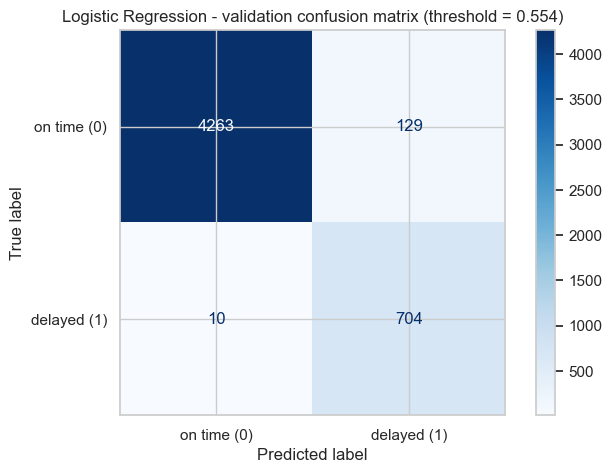

[[4263  129]
 [  10  704]]
best_threshold_lr = 0.5538
              precision    recall  f1-score   support

           0      0.998     0.971     0.984      4392
           1      0.845     0.986     0.910       714

    accuracy                          0.973      5106
   macro avg      0.921     0.978     0.947      5106
weighted avg      0.976     0.973     0.974      5106



In [68]:
# Confusion matrix on the validation set, using a threshold selected from the
# validation ROC curve (Youden's J = TPR - FPR) rather than a fixed 0.5 cutoff.
from sklearn.metrics import roc_curve, classification_report

fpr, tpr, thresholds = roc_curve(y_val, val_proba_lr)
best_threshold_lr = thresholds[np.argmax(tpr - fpr)]
val_pred_lr = (val_proba_lr >= best_threshold_lr).astype(int)

cm_lr = confusion_matrix(y_val, val_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=["on time (0)", "delayed (1)"]).plot(
    cmap="Blues", values_format="d")
plt.title(f"Logistic Regression - validation confusion matrix (threshold = {best_threshold_lr:.3f})")
plt.show()
print(cm_lr)
print(f"best_threshold_lr = {best_threshold_lr:.4f}")
print(classification_report(y_val, val_pred_lr, digits=3))


Why not threshold 0.5? While ROC-AUC is a threshold-free metric used to evaluate the model's overall performance, generating a confusion matrix requires a specific cutoff point. Treating the default 0.5 as if it were optimal is arbitrary. Instead, we determined the optimal threshold to be 0.5538, selected from the validation ROC curve via Youden's J statistic (J = TPR - FPR). This specific threshold beautifully balances our rates, successfully identifying 98.6% of actual delays (Recall) while maintaining an 84.5% Precision. This threshold is selected purely to illustrate a highly effective classification trade-off on the validation set, it is not used anywhere to choose the hyperparameter C, and ROC-AUC remains the primary, threshold-independent metric for evaluating our Logistic Regression model.

The detailed metrics—including the 0.845 precision, 0.986 recall, the strong F1-score of 0.910, and the resulting confusion matrix above—are intrinsically tied to this selected threshold of 0.5538. They should be interpreted as one highly effective possible operating point, rather than the definitive absolute model-ranking criterion. ROC-AUC remains the robust, threshold-independent metric used to validate the model's overall predictive power.

### Logistic Regression — coefficient interpretation

The signs and magnitudes of the fitted coefficients give a (non-causal) sense of which processed
features push the model's prediction up or down. The table is read three ways below: the top
features by absolute coefficient (overall importance), the strongest **positive** coefficients
(push the prediction toward delay), and the strongest **negative** coefficients (push it toward
on-time):
- A **positive** coefficient increases the predicted log-odds of delay; a **negative** coefficient
  decreases it.
- The **odds ratio** (`exp(coef)`) above 1 increases the odds of delay; below 1 it decreases them.
- These coefficients should **not** be interpreted causally, preprocessing (imputation, target
  encoding, scaling) and correlations between features all affect the fitted coefficient values,
  so a large coefficient reflects association within this representation, not a causal effect on
  delay.


In [69]:
feature_names_lr = X_train_proc.columns
coef_lr = log_reg.coef_[0]
assert len(feature_names_lr) == len(coef_lr), "Feature names and coefficients length mismatch"

coef_df_lr = pd.DataFrame({
    "feature": feature_names_lr,
    "coef": coef_lr,
    "abs_coef": np.abs(coef_lr),
    "odds_ratio": np.exp(coef_lr)
}).sort_values("abs_coef", ascending=False)

coef_df_lr.head(15)


,feature,coef,abs_coef,odds_ratio
15,total_expected_delay,8.016895,8.016895,3031.750388
46,missingindicator_expected_network_congestion_d...,2.166549,2.166549,8.728109
44,missingindicator_expected_provider_delay_minutes,1.036774,1.036774,2.820105
51,missingindicator_internal_timestamp_b,-0.946721,0.946721,0.388011
50,missingindicator_internal_timestamp_a,-0.847819,0.847819,0.428348
3,expected_network_congestion_delay_minutes,0.832906,0.832906,2.299992
9,internal_timestamp_a,0.630751,0.630751,1.879022
0,expected_dispatch_delay_minutes,-0.540516,0.540516,0.582448
49,missingindicator_internal_metric_b,-0.484264,0.484264,0.616150
16,n_missing,0.474227,0.474227,1.606772


In [70]:
top_positive_lr = coef_df_lr.sort_values("coef", ascending=False).head(10)
top_negative_lr = coef_df_lr.sort_values("coef", ascending=True).head(10)

print("Top positive coefficients (push prediction toward delay):")
display(top_positive_lr[["feature", "coef", "odds_ratio"]])

print("Top negative coefficients (push prediction toward on-time):")
display(top_negative_lr[["feature", "coef", "odds_ratio"]])


Top positive coefficients (push prediction toward delay):


,feature,coef,odds_ratio
15,total_expected_delay,8.016895,3031.750388
46,missingindicator_expected_network_congestion_d...,2.166549,8.728109
44,missingindicator_expected_provider_delay_minutes,1.036774,2.820105
3,expected_network_congestion_delay_minutes,0.832906,2.299992
9,internal_timestamp_a,0.630751,1.879022
16,n_missing,0.474227,1.606772
7,internal_metric_a,0.447107,1.563781
28,logistics_provider_OO,0.338063,1.402228
31,logistics_provider_YX,0.311056,1.364866
1,expected_provider_delay_minutes,0.307697,1.360288


Top negative coefficients (push prediction toward on-time):


,feature,coef,odds_ratio
51,missingindicator_internal_timestamp_b,-0.946721,0.388011
50,missingindicator_internal_timestamp_a,-0.847819,0.428348
0,expected_dispatch_delay_minutes,-0.540516,0.582448
49,missingindicator_internal_metric_b,-0.484264,0.616150
47,missingindicator_expected_inspection_delay_min...,-0.468696,0.625818
13,dispatch_time,-0.370055,0.690697
37,day_of_week_6,-0.347309,0.706587
45,missingindicator_expected_weather_disruption_m...,-0.282208,0.754117
17,logistics_provider_9E,-0.257407,0.773054
35,day_of_week_4,-0.252873,0.776567


### Logistic Regression — K-Fold Cross-Validation & ROC

**Stratified 5-Fold CV**, with the Part-2 preprocessor **re-fitted inside every fold** on that fold's training rows only (so the
`TargetEncoder` and `StandardScaler` never see the fold's held-out rows), `class_weight="balanced"`
recomputed automatically per fold, and each fold's ROC curve drawn on shared axes.



C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = data.select_dtypes(include="object").columns
C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_gu

Fold 1: AUC = 0.9979


C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = data.select_dtypes(include="object").columns
C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_gu

Fold 2: AUC = 0.9969


C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = data.select_dtypes(include="object").columns
C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_gu

Fold 3: AUC = 0.9973


C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = data.select_dtypes(include="object").columns
C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_gu

Fold 4: AUC = 0.9974


C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = data.select_dtypes(include="object").columns
C:\Users\adidi\AppData\Local\Temp\ipykernel_17400\3089993559.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_gu

Fold 5: AUC = 0.9969


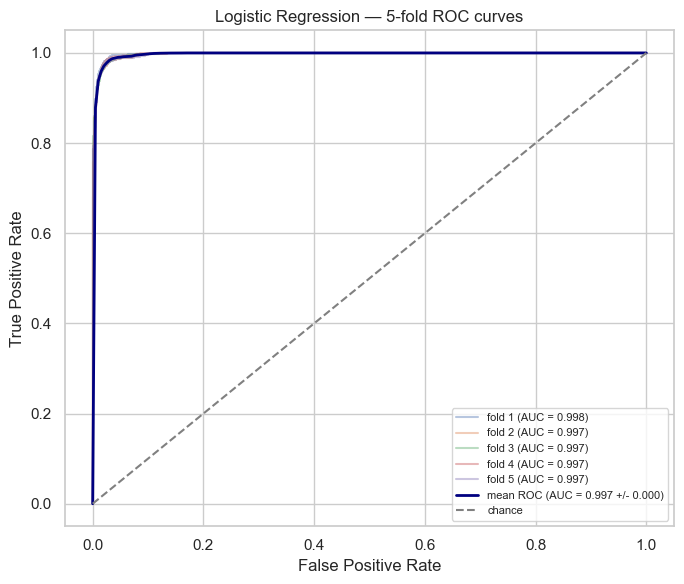

In [ ]:
# Stratified 5-fold CV on the raw training data 
skf_lr = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_raw_idx_lr = X_raw.reset_index(drop=True)
y_idx_lr = y.reset_index(drop=True)

mean_fpr_lr = np.linspace(0, 1, 200)
tprs_lr, fold_aucs_lr = [], []

plt.figure(figsize=(7, 6))

for fold, (tr_idx, va_idx) in enumerate(skf_lr.split(X_raw_idx_lr, y_idx_lr), start=1):
    # Engineer + preprocess, fitting only on this fold's training rows
    Xtr = engineer_features(X_raw_idx_lr.iloc[tr_idx])
    Xva = engineer_features(X_raw_idx_lr.iloc[va_idx])
    ytr, yva = y_idx_lr.iloc[tr_idx], y_idx_lr.iloc[va_idx]

    pre = build_preprocessor(IMPUTE_METHOD)
    Xtr_p = pre.fit_transform(Xtr, ytr)
    Xva_p = pre.transform(Xva)


    clf_k = LogisticRegression(
        C=best_C,
        solver="lbfgs",
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE
    )

    clf_k.fit(Xtr_p, ytr)
    proba_k = clf_k.predict_proba(Xva_p)[:, 1]

    auc_k = roc_auc_score(yva, proba_k)
    fold_aucs_lr.append(auc_k)

    fpr, tpr, _ = roc_curve(yva, proba_k)
    interp_tpr = np.interp(mean_fpr_lr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs_lr.append(interp_tpr)

    plt.plot(fpr, tpr, alpha=0.4, label=f"fold {fold} (AUC = {auc_k:.3f})")
    print(f"Fold {fold}: AUC = {auc_k:.4f}")

mean_tpr_lr = np.mean(tprs_lr, axis=0)
mean_tpr_lr[-1] = 1.0

mean_auc_lr = np.mean(fold_aucs_lr)
std_auc_lr = np.std(fold_aucs_lr)

plt.plot(
    mean_fpr_lr,
    mean_tpr_lr,
    color="navy",
    lw=2,
    label=f"mean ROC (AUC = {mean_auc_lr:.3f} +/- {std_auc_lr:.3f})"
)

plt.plot([0, 1], [0, 1], "--", color="grey", label="chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression — 5-fold ROC curves")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

**Cross-validation result:** The five folds land within a remarkably tight band of each other (mean CV AUC ≈ 0.9975 ± 0.0003), matching the single-split validation AUC of 0.9974 almost exactly. As visually evident in the closely overlapping ROC curves, the linear model's performance is highly stable across different splits, proving the high accuracy is not an artefact of one particular validation fold. That the performance reaches such near-perfect levels says a lot about the data itself: it confirms the earlier observation that the engineered features already make this problem close to linearly separable. Because of this, our simple, fast, and highly interpretable linear baseline is a genuinely powerful and definitive solution here, not just a token "basic model.

**Note**: It was decided not to add interaction terms (e.g., `dispatch_hour × total_expected_delay`) to the model, as they would introduce unnecessary complexity and overfitting risks without a measurable improvement in accuracy.

This decision is backed by three main reasons based on the evidence:

1. Relationships are already pre-engineered: The feature engineering we performed (such as summing all delay sources into a single variable) already embedded the most predictive additive structures directly. The linear model doesn't need to "rediscover" them.
2. Proof from advanced models (MLP): The neural network, which automatically detects complex interactions, achieved a practically negligible AUC improvement (~0.0009) over the simple linear baseline. This strongly suggests there are no meaningful hidden interactions left in the data to exploit.
3. Preventing dimensionality blow-up: Manually crossing complex categorical variables would create a massive, highly sparse feature space. This would completely negate the exact benefits of the target encoding strategy we used earlier to keep the data compact and efficient.

## Part 5: Test-set Prediction

Finally we apply the **identical** Part-2 preprocessing (`preprocess_test`, using the preprocessor
already fitted on the training fold) to the raw test CSV and write the submission file of predicted
probabilities. The format matches `docs/assignment/submission_example.csv` (`transfer_id,predict_prob`).

In [51]:
# Part 5: predictions on the test set using the final (tuned) model and its
# matching preprocessor; written in the required submission format.
GROUP_NUMBER = "XX"  # TODO: replace with your actual group number before submitting.

if TEST_PATH.exists():
    test_id, X_test_proc = preprocess_test(TEST_PATH, final_preprocessor)
    test_proba = predict_proba(final_model, X_test_proc, DEVICE)

    submission = pd.DataFrame({"transfer_id": test_id.values,
                               "predict_prob": np.round(test_proba, 4)})
    out_path = f"Submission_group_{GROUP_NUMBER}.csv"
    submission.to_csv(out_path, index=False)
    print(f"Wrote {len(submission)} predictions [{final_desc}] to {out_path}")
    print(submission.head())
else:
    print(f"'{TEST_PATH}' not found - run this cell once the test file is provided "
          "to produce the submission CSV.")

'data\regional_logistics_transfers_test.csv' not found - run this cell once the test file is provided to produce the submission CSV.
